# Lesson 152 · Regression portfolio: accurate predictions, honest calibration

Student lab · PROVIDED / TODO / CHECK / EXIT. Three live functions score keyed predictions, diagnose median balance and summarize complete seed evidence. The default CPU path audits author evidence; the post-EXIT pinned GPU gate trains five new full-data fits.

In [ ]:
# @colab-bootstrap: default audit; full training requires the pinned GPU runtime.
import os,sys,subprocess
os.environ.update(OMP_NUM_THREADS='1',OPENBLAS_NUM_THREADS='1',MKL_NUM_THREADS='1')
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable,'-m','pip','install','-q','pytorch-frame==0.2.3','torch-geometric==2.6.1','relbench==1.1.0','sentence-transformers==3.3.1'])
from pathlib import Path
import math,statistics,json,io,base64,hashlib,zlib
import numpy as np,pandas as pd
from IPython.display import display
RUN_FULL_REPRODUCTION=False


In [ ]:
# PROVIDED: author evidence is labeled; hashes check its embedded bytes.
SOURCE_FILES=json.loads(zlib.decompress(base64.b64decode('...')))
P=Path.cwd()
for name,text in SOURCE_FILES.items():
    dest=P/name;dest.parent.mkdir(parents=True,exist_ok=True);dest.write_text(text)
AUTHOR_SUMMARY={'status': 'PASS', 'records': [{'seed': 0, 'epochs': 10, 'complete': True, 'selected_epoch': 9, 'selection_mae': 3.2050616886747947, 'val_mae': 3.207254565295651, 'test_mae': 3.933464946077581, 'test_rmse': 4.7238301934829705, 'test_bias': 0.5026228645391632}, {'seed': 1, 'epochs': 10, 'complete': True, 'selected_epoch': 9, 'selection_mae': 3.1086770597902547, 'val_mae': 3.1107265917077886, 'test_mae': 3.8400807575175637, 'test_rmse': 4.704184730104341, 'test_bias': 0.2852102064249808}, {'seed': 2, 'epochs': 10, 'complete': True, 'selected_epoch': 10, 'selection_mae': 3.2396234072759778, 'val_mae': 3.2408492216366325, 'test_mae': 3.8731387437853897, 'test_rmse': 4.724245282207967, 'test_bias': 0.04298851782815492}, {'seed': 3, 'epochs': 10, 'complete': True, 'selected_epoch': 10, 'selection_mae': 3.1891796185322097, 'val_mae': 3.1858771456665567, 'test_mae': 3.9581611559265544, 'test_rmse': 4.861775957673042, 'test_bias': 0.7841167999987015}, {'seed': 4, 'epochs': 10, 'complete': True, 'selected_epoch': 7, 'selection_mae': 3.1595058439887995, 'val_mae': 3.156181748134738, 'test_mae': 4.249352173637925, 'test_rmse': 5.1900387743290075, 'test_bias': 1.5257805690430757}], 'metrics': {'val': {'mean': 3.1801778544882735, 'sample_sd': 0.049613344983145256, 'values': [3.207254565295651, 3.1107265917077886, 3.2408492216366325, 3.1858771456665567, 3.156181748134738]}, 'test': {'mean': 3.970839555389003, 'sample_sd': 0.16261164900366876, 'values': [3.933464946077581, 3.8400807575175637, 3.8731387437853897, 3.9581611559265544, 4.249352173637925]}, 'rmse': {'mean': 4.840814987559465, 'sample_sd': 0.20514530278370346, 'values': [4.7238301934829705, 4.704184730104341, 4.724245282207967, 4.861775957673042, 5.1900387743290075]}, 'paper_score': 'CLOSE', 'historical_identity': 'NOT_ESTABLISHED', 'feature_arrival_legality': 'NOT_ESTABLISHED', 'whole_paper': 'NOT_RUN', 'fresh_fe_comparison': 'NOT_RUN', 'learner': 'PENDING_WRITTEN_DEFENSE'}, 'bins': {'0': {'val': [{'bin': 0, 'n': 100, 'prediction_mean': 8.955276198387146, 'below': 0.59, 'equal': 0.0, 'above': 0.41, 'median_violation': 0.08999999999999997, 'mean_residual': -0.2466095317204794}, {'bin': 1, 'n': 100, 'prediction_mean': 10.038095722198486, 'below': 0.55, 'equal': 0.0, 'above': 0.45, 'median_violation': 0.050000000000000044, 'mean_residual': -0.7085957221984864}, {'bin': 2, 'n': 99, 'prediction_mean': 10.709714571634928, 'below': 0.5757575757575758, 'equal': 0.0, 'above': 0.42424242424242425, 'median_violation': 0.0757575757575758, 'mean_residual': -0.887155649076006}, {'bin': 3, 'n': 100, 'prediction_mean': 12.042380447387695, 'below': 0.44, 'equal': 0.0, 'above': 0.56, 'median_violation': 0.06000000000000005, 'mean_residual': 0.5931195526123045}, {'bin': 4, 'n': 100, 'prediction_mean': 14.69913119316101, 'below': 0.37, 'equal': 0.0, 'above': 0.63, 'median_violation': 0.13, 'mean_residual': 0.20803547350565593}], 'test': [{'bin': 0, 'n': 81, 'prediction_mean': 8.923420623496726, 'below': 0.5679012345679012, 'equal': 0.0, 'above': 0.43209876543209874, 'median_violation': 0.0679012345679012, 'mean_residual': -0.4937909938670973}, {'bin': 1, 'n': 110, 'prediction_mean': 9.843491406874223, 'below': 0.4818181818181818, 'equal': 0.0, 'above': 0.5181818181818182, 'median_violation': 0.018181818181818188, 'mean_residual': 0.35362980524698884}, {'bin': 2, 'n': 116, 'prediction_mean': 10.794101328685366, 'below': 0.7068965517241379, 'equal': 0.0, 'above': 0.29310344827586204, 'median_violation': 0.2068965517241379, 'mean_residual': -2.2630668459267453}, {'bin': 3, 'n': 54, 'prediction_mean': 12.087535540262857, 'below': 0.2962962962962963, 'equal': 0.0, 'above': 0.7037037037037037, 'median_violation': 0.20370370370370372, 'mean_residual': 2.2411681634408454}, {'bin': 4, 'n': 399, 'prediction_mean': 14.37465224349708, 'below': 0.531328320802005, 'equal': 0.0, 'above': 0.46867167919799496, 'median_violation': 0.03132832080200498, 'mean_residual': -0.6000072977995017}]}, '1': {'val': [{'bin': 0, 'n': 100, 'prediction_mean': 7.288737659454346, 'below': 0.45, 'equal': 0.0, 'above': 0.55, 'median_violation': 0.050000000000000044, 'mean_residual': 0.5160956738789877}, {'bin': 1, 'n': 100, 'prediction_mean': 9.271217927932739, 'below': 0.38, 'equal': 0.0, 'above': 0.62, 'median_violation': 0.12, 'mean_residual': 0.8257820720672607}, {'bin': 2, 'n': 99, 'prediction_mean': 10.612431121594978, 'below': 0.5050505050505051, 'equal': 0.0, 'above': 0.494949494949495, 'median_violation': 0.005050505050505083, 'mean_residual': -0.3917240508879073}, {'bin': 3, 'n': 100, 'prediction_mean': 12.54808588027954, 'below': 0.51, 'equal': 0.0, 'above': 0.49, 'median_violation': 0.010000000000000009, 'mean_residual': -0.4487525469462077}, {'bin': 4, 'n': 100, 'prediction_mean': 14.931886978149414, 'below': 0.38, 'equal': 0.0, 'above': 0.62, 'median_violation': 0.12, 'mean_residual': 0.253613021850586}], 'test': [{'bin': 0, 'n': 104, 'prediction_mean': 7.233586205885961, 'below': 0.5192307692307693, 'equal': 0.0, 'above': 0.4807692307692308, 'median_violation': 0.019230769230769273, 'mean_residual': 0.47939456334480857}, {'bin': 1, 'n': 72, 'prediction_mean': 9.006781220436096, 'below': 0.3333333333333333, 'equal': 0.0, 'above': 0.6666666666666666, 'median_violation': 0.16666666666666663, 'mean_residual': 3.4242372980824225}, {'bin': 2, 'n': 137, 'prediction_mean': 10.563583742963136, 'below': 0.7299270072992701, 'equal': 0.0, 'above': 0.27007299270072993, 'median_violation': 0.22992700729927007, 'mean_residual': -2.5972820398001195}, {'bin': 3, 'n': 159, 'prediction_mean': 13.216056547824692, 'below': 0.4968553459119497, 'equal': 0.0, 'above': 0.5031446540880503, 'median_violation': 0.0031446540880503138, 'mean_residual': 0.6288071838314927}, {'bin': 4, 'n': 288, 'prediction_mean': 15.039344605472353, 'below': 0.5659722222222222, 'equal': 0.0, 'above': 0.4340277777777778, 'median_violation': 0.06597222222222221, 'mean_residual': -0.8934534017686491}]}, '2': {'val': [{'bin': 0, 'n': 100, 'prediction_mean': 7.406814956665039, 'below': 0.47, 'equal': 0.0, 'above': 0.53, 'median_violation': 0.030000000000000027, 'mean_residual': 0.2890183766682943}, {'bin': 1, 'n': 100, 'prediction_mean': 9.266437425613404, 'below': 0.33, 'equal': 0.0, 'above': 0.67, 'median_violation': 0.17000000000000004, 'mean_residual': 1.3093959077199298}, {'bin': 2, 'n': 99, 'prediction_mean': 10.312835780057041, 'below': 0.5252525252525253, 'equal': 0.0, 'above': 0.47474747474747475, 'median_violation': 0.025252525252525304, 'mean_residual': -0.2643509315721917}, {'bin': 3, 'n': 100, 'prediction_mean': 11.821694507598878, 'below': 0.46, 'equal': 0.0, 'above': 0.54, 'median_violation': 0.040000000000000036, 'mean_residual': 0.2174721590677897}, {'bin': 4, 'n': 100, 'prediction_mean': 13.589682121276855, 'below': 0.29, 'equal': 0.0, 'above': 0.71, 'median_violation': 0.20999999999999996, 'mean_residual': 1.456651212056478}], 'test': [{'bin': 0, 'n': 104, 'prediction_mean': 7.256488634989812, 'below': 0.5192307692307693, 'equal': 0.0, 'above': 0.4807692307692308, 'median_violation': 0.019230769230769273, 'mean_residual': 0.45649213424095725}, {'bin': 1, 'n': 83, 'prediction_mean': 9.181452222617276, 'below': 0.4457831325301205, 'equal': 0.0, 'above': 0.5542168674698795, 'median_violation': 0.054216867469879526, 'mean_residual': 2.018146170957021}, {'bin': 2, 'n': 103, 'prediction_mean': 10.27479322674205, 'below': 0.7087378640776699, 'equal': 0.0, 'above': 0.2912621359223301, 'median_violation': 0.20873786407766992, 'mean_residual': -2.4885472720494937}, {'bin': 3, 'n': 74, 'prediction_mean': 12.008860639623693, 'below': 0.2972972972972973, 'equal': 0.0, 'above': 0.7027027027027027, 'median_violation': 0.20270270270270274, 'mean_residual': 2.6904636847006302}, {'bin': 4, 'n': 396, 'prediction_mean': 14.224477772760872, 'below': 0.5757575757575758, 'equal': 0.0, 'above': 0.42424242424242425, 'median_violation': 0.0757575757575758, 'mean_residual': -0.48087507915817923}]}, '3': {'val': [{'bin': 0, 'n': 100, 'prediction_mean': 7.134411778450012, 'below': 0.43, 'equal': 0.0, 'above': 0.57, 'median_violation': 0.06999999999999995, 'mean_residual': 0.6954215548833211}, {'bin': 1, 'n': 100, 'prediction_mean': 8.961266822814942, 'below': 0.35, 'equal': 0.0, 'above': 0.65, 'median_violation': 0.15000000000000002, 'mean_residual': 1.3432331771850585}, {'bin': 2, 'n': 99, 'prediction_mean': 10.42694000282673, 'below': 0.494949494949495, 'equal': 0.0, 'above': 0.5050505050505051, 'median_violation': 0.005050505050505083, 'mean_residual': -0.26801744390417026}, {'bin': 3, 'n': 100, 'prediction_mean': 12.751025495529175, 'below': 0.55, 'equal': 0.0, 'above': 0.45, 'median_violation': 0.050000000000000044, 'mean_residual': -0.47819216219584154}, {'bin': 4, 'n': 100, 'prediction_mean': 15.35788293838501, 'below': 0.47, 'equal': 0.0, 'above': 0.53, 'median_violation': 0.030000000000000027, 'mean_residual': -0.5172162717183431}], 'test': [{'bin': 0, 'n': 104, 'prediction_mean': 6.925876035140111, 'below': 0.5096153846153846, 'equal': 0.0, 'above': 0.49038461538461536, 'median_violation': 0.009615384615384581, 'mean_residual': 0.7871047340906581}, {'bin': 1, 'n': 77, 'prediction_mean': 8.79598719113833, 'below': 0.33766233766233766, 'equal': 0.0, 'above': 0.6623376623376623, 'median_violation': 0.16233766233766234, 'mean_residual': 3.2377790426279045}, {'bin': 2, 'n': 126, 'prediction_mean': 10.183321347312322, 'below': 0.746031746031746, 'equal': 0.0, 'above': 0.25396825396825395, 'median_violation': 0.24603174603174605, 'mean_residual': -2.6677128817038565}, {'bin': 3, 'n': 62, 'prediction_mean': 13.3282714351531, 'below': 0.25806451612903225, 'equal': 0.0, 'above': 0.7419354838709677, 'median_violation': 0.24193548387096775, 'mean_residual': 3.0851694250619537}, {'bin': 4, 'n': 391, 'prediction_mean': 15.736092057679315, 'below': 0.6751918158567775, 'equal': 0.0, 'above': 0.3248081841432225, 'median_violation': 0.17519181585677746, 'mean_residual': -2.0006274370484545}]}, '4': {'val': [{'bin': 0, 'n': 100, 'prediction_mean': 7.748617534637451, 'below': 0.53, 'equal': 0.0, 'above': 0.47, 'median_violation': 0.030000000000000027, 'mean_residual': 0.48404913202921535}, {'bin': 1, 'n': 100, 'prediction_mean': 9.134380836486816, 'below': 0.38, 'equal': 0.0, 'above': 0.62, 'median_violation': 0.12, 'mean_residual': 0.7461191635131835}, {'bin': 2, 'n': 99, 'prediction_mean': 10.261134099478673, 'below': 0.5050505050505051, 'equal': 0.0, 'above': 0.494949494949495, 'median_violation': 0.005050505050505083, 'mean_residual': -0.22594891429348826}, {'bin': 3, 'n': 100, 'prediction_mean': 12.492653045654297, 'below': 0.53, 'equal': 0.0, 'above': 0.47, 'median_violation': 0.030000000000000027, 'mean_residual': -0.46565304565429694}, {'bin': 4, 'n': 100, 'prediction_mean': 15.589895067214966, 'below': 0.47, 'equal': 0.0, 'above': 0.53, 'median_violation': 0.030000000000000027, 'mean_residual': -0.359728400548299}], 'test': [{'bin': 0, 'n': 98, 'prediction_mean': 8.134667503590487, 'below': 0.6122448979591837, 'equal': 0.0, 'above': 0.3877551020408163, 'median_violation': 0.11224489795918369, 'mean_residual': -0.8127287280802824}, {'bin': 1, 'n': 73, 'prediction_mean': 9.091789101901119, 'below': 0.3013698630136986, 'equal': 0.0, 'above': 0.6986301369863014, 'median_violation': 0.1986301369863014, 'mean_residual': 3.44862185700299}, {'bin': 2, 'n': 130, 'prediction_mean': 10.20866034581111, 'below': 0.7692307692307693, 'equal': 0.0, 'above': 0.23076923076923078, 'median_violation': 0.2692307692307693, 'mean_residual': -2.9698141919649568}, {'bin': 3, 'n': 58, 'prediction_mean': 12.081244764656857, 'below': 0.15517241379310345, 'equal': 0.0, 'above': 0.8448275862068966, 'median_violation': 0.3448275862068966, 'mean_residual': 4.08542190200981}, {'bin': 4, 'n': 401, 'prediction_mean': 16.79494722704043, 'below': 0.7481296758104738, 'equal': 0.0, 'above': 0.2518703241895262, 'median_violation': 0.24812967581047385, 'mean_residual': -2.949061940257389}]}}, 'predictions': 6295, 'query_occurrences': 403895, 'first_backward_nonfinite': {'0': 640, '1': 640, '2': 640, '3': 640, '4': 640}, 'worker_body_usd': 0.059555831882480995, 'maximum_original_output_error': 3.814697265625e-06, 'hashes': {'evidence/l152/paper/seed-0/diagnostics.json': '6beedd8ef735d4cf8f593d46b44a5c1707aabc0f38238c3184b45e91953c49f0', 'evidence/l152/paper/seed-0/predictions.npz': '37935143a9d89f1e4324fae5b47cd4a09b1201f73e25eef98727737fdd4cbf78', 'evidence/l152/paper/seed-0/temporal-audit.json': 'd58355173c7eeb0ca8a16bb7109318cecc9c2994db1e5243a83ea6bf16e5b689', 'evidence/l152/paper/seed-0/cost.json': '585faa868a6ad98bfe04d0059070eef1da2eafd65e5de279f21317f1eab0d27d', 'evidence/l152/paper/seed-0/result.json': 'fd3caf154e09b56d4e1cc09177b2ff34c483d1f8698b8673099df0434acfa231', 'evidence/l152/paper/seed-0/completed.json': 'a40f8634852919e411c073f43a00b5af05b4f1c6d691f399f20f7b2d30286810', 'evidence/l152/paper/seed-0/checkpoint-audit.json': '8c9a2e0914ec5826a792bbe44c487a8ec3047f5f1e7f8f470a24fa9216aa09fc', 'evidence/l152/paper/seed-0/started.json': '9fdf97f365f19cf89227918a54a69950914f00904ccadd13518c3b038cbddafc', 'evidence/l152/paper/seed-0/audit.json': '0e827bca71558ece6c923d9200e8e1e7811f17d3d53a13884c7ba09610994ac7', 'evidence/l152/paper/seed-1/diagnostics.json': 'b47125208fe4e18650b12f8081e178d6b6babd34d55195b485882144cec26be9', 'evidence/l152/paper/seed-1/predictions.npz': '40969d6664e2541106013b8d86f751fbbeaff031234c2e94b68a3db7fa792d5a', 'evidence/l152/paper/seed-1/temporal-audit.json': 'e78947ded054e6fb6538cb0df20e1a3215e579d3f22a5ceb1bb81a7e02600a68', 'evidence/l152/paper/seed-1/cost.json': '07ac1f3c93826b2df45200c0dd478851b87f8089c6cb297f10a2426e21448ecf', 'evidence/l152/paper/seed-1/result.json': '95b03b18698e798d657558611c9bf7c4e6b0f64858561a0800610fb97d391d9a', 'evidence/l152/paper/seed-1/completed.json': '372d12baaf4ba4ef5037caf3fe48d437ab79f60a17f466e53761e99e2ab235f3', 'evidence/l152/paper/seed-1/checkpoint-audit.json': '7ed0b106385f2633a59545948bf24d1d8b16ec8805124d2260e1b021476b1cd8', 'evidence/l152/paper/seed-1/started.json': '946fbbb80150af0968ecb96041fed97864362370e71918dece2aec29a7aab867', 'evidence/l152/paper/seed-1/audit.json': '0e827bca71558ece6c923d9200e8e1e7811f17d3d53a13884c7ba09610994ac7', 'evidence/l152/paper/seed-2/diagnostics.json': 'c8cbc9c6c4353e17c79be31fe3aa7c81f79f07007158d9f0f9c24b7547d62b05', 'evidence/l152/paper/seed-2/predictions.npz': '60827c6d935ea8e67db3f94ba9886c4133e275ed2c9791c9e92fee2639a9dcb9', 'evidence/l152/paper/seed-2/temporal-audit.json': '58245fa0615fcbc80e831af8df6a66fb31e2876d8a8cdb47f427edfd9cd6ec34', 'evidence/l152/paper/seed-2/cost.json': 'c0880c3620efc40509dc6dee5a7ef53b8c24c748e4d99e7d9d49e352aa63c902', 'evidence/l152/paper/seed-2/result.json': 'bd45cc4074384b3cfe8e9d0813329c99463f2ac9ad52fe9678778afb25c7e297', 'evidence/l152/paper/seed-2/completed.json': '9049cb47193e4203cfa7d2491efa1917496b33b0c7f0d19a98e6a9216bcf7ef5', 'evidence/l152/paper/seed-2/checkpoint-audit.json': 'c1ed2c5e8832f78edf685a3cb5ad4e995eeca892c6c35ebe11fc6a8190ea965f', 'evidence/l152/paper/seed-2/started.json': '63454c8623b4b7746e906880267e96beb3fd677f4bb6d63ee7e3e24a50879375', 'evidence/l152/paper/seed-2/audit.json': '0e827bca71558ece6c923d9200e8e1e7811f17d3d53a13884c7ba09610994ac7', 'evidence/l152/paper/seed-3/diagnostics.json': 'f46a9c902e5e1bba15f2bfff89b46aa6e5dcac6bcd2152818a88b6b8ab86e22e', 'evidence/l152/paper/seed-3/predictions.npz': 'f9da76d067653c22aad42953447d66c941e57a05327888cb64c57c4aa1299c81', 'evidence/l152/paper/seed-3/temporal-audit.json': 'c445bc48111908707d812e711bb4b73310497f70bec7dbf484486b26fee3497f', 'evidence/l152/paper/seed-3/cost.json': 'a9f1c0d1b8036ac7056c030f6029173c33d29aa2b786e16ee73238ea70350c50', 'evidence/l152/paper/seed-3/result.json': '64a568e5c68fe1e10b616982c91922a4735afe3d1371a361c19dc70d23660c1d', 'evidence/l152/paper/seed-3/completed.json': 'd38061eb254b0880b46f028868ad6b79dc7049fd7fedebcbe3fe41a07b86a6c7', 'evidence/l152/paper/seed-3/checkpoint-audit.json': '09eb91cacad0e1590caaead135ecdb713dc07f2979ab399b137c7e316d1ae3f2', 'evidence/l152/paper/seed-3/started.json': '9fcd0288857698d63e8e5168b4aa836aa4a29842d0806376d47a92cfcc050139', 'evidence/l152/paper/seed-3/audit.json': '0e827bca71558ece6c923d9200e8e1e7811f17d3d53a13884c7ba09610994ac7', 'evidence/l152/paper/seed-4/diagnostics.json': '1187fad0489c0b2ba4731e054a03bd3dfb5781a50cfc5637106859e5a2c1673e', 'evidence/l152/paper/seed-4/predictions.npz': 'da898b061ffdaf4214c7ac51de23f9377aac0e1215fae2a3da2068aca9e9c9a2', 'evidence/l152/paper/seed-4/temporal-audit.json': '0aa93e28e719f61b62544b731debbfe20de095e56a9f6863cf1c5d618fc75dfa', 'evidence/l152/paper/seed-4/cost.json': '8752fce7854c5baa8c8088415b0713a4984a04c89c05a9be6822bfbd6ae1c242', 'evidence/l152/paper/seed-4/result.json': '196cd9f47fabb06a5714deeb906f82b8fd72ec3ad848992c429301de7d4306ef', 'evidence/l152/paper/seed-4/completed.json': '969bdc86f6c5e29e5d0c03be3f63dac829e10dbd271b54949ac0df74fab0d53c', 'evidence/l152/paper/seed-4/checkpoint-audit.json': '237bd0b12e38c082af0af2dcae65e8345b982174ed918b0774bebd58bd07886f', 'evidence/l152/paper/seed-4/started.json': 'f86b0da6f9bfab3c79f8e0675b9294d21792cf2182c3b7550ee938ef303dee54', 'evidence/l152/paper/seed-4/audit.json': '0e827bca71558ece6c923d9200e8e1e7811f17d3d53a13884c7ba09610994ac7'}}
PAYLOAD={'0': {'data': 'UEsDBC0AAAAIAAAAIQD/wtsP//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAADgcAAAAAAACdlelX1IcVhkEBR8CwzAYUFGWGmfnNDIxAgyACT0QlalBklX2cYQSkgiAEBUQ5qBR35agxRAWRWrQcQwk2JrHWpccoorgk1mhcahA5aNB4XKghnf4Lvd/u++ne977nubvikj5auNjWptymUmXOLTWVqMJ9VRGWEJXOV2UpKllZYlyeXVRizv2fPttYWJpr1UvzjMW51l4dEham0+h8q33/73I8etudiopoLo44YO85k01XDAyP6njep8LmiTM9D3RcbhO4c6iYtMkL6YktoUP9IfpKMZVXl9AWMZuRbzZyY5aaM8HT2HxPzsjiUJY2JrFQbabkVibZu33ZW+nFjJBgPKIDmbhgFSJHHfVRSYxG+mPXpaRdnEFTs5HZS7U4J0vZfGsKx1O0XAiQYj+sJa7FRGKhHverID4toyLPj7plAufKw3hRlcY1rQJZu8DNlED6HVx5/tTM2tdqlmxfwbn7mUSNaugdqCBtiwbf8dV02ahZ9EBJ71kXzh2QkvNtIAWXjQycldCZOZbYC4G0j6bjvFXN1EFPfu0I5vUXaqosMpqfTaZ1QiBposWUNc2gbpIPqQ3TqQ/MZtpPBjKiioncKjAbLVv+lYC4xZHwewLaaiU+3v7Eiqay4H2oP6zjts1Myr3HUrRlCUatEy83hLHjmoTh0oWE3FHy5kdP1BJf/jl7Mg4dnuiGkmmc6IbCywfvYxqEPXpenFQxV67F9KCERSWpbH67lkONWk6+rebnQiWW9TPJni8hJSGGmAQZ/7jrhPvjXL521hO7MptXV9zoL9UizdIy5lEoO3/0Z+q2WdxI9aLVxZXgHCmXNk3DuVeJ0xwTES9FdDj4o9hWSXifmi9TNGyyH0/KxiS2Xpfgb9ThUhnI10hoKXKlVRxA8atY9u6PIsGop+LSPMJ74mjIlvDM04wuQsK+dys4VTmPt7vD8FqaSHaNkld755DuVUeQdDpFGiVjLgpIn4vxLXFhV48fowkFeFXNpeWv05n1jZq0uwoaCv05cL+OkJgI8ms1FJ2uQBgj5eAiDa/aVDw5EYX059+ivRfkMSffhkfzBXrKvOlvlnHe5IElEc6GaHnTPoVTNh7MiFxB+QR/OhTOpPULuE/X0rariL8VrGRjqImG1+NYH7eUuhd+rP7EhGRjEPqiBnqrnGncocLcYctyjYm+fSrmdI1D+PfvcP3QD4eCJJIVFgaeBjF4PYetXcE4RU9h/rP3cP7KQFKpAdtJ3jQ7FfG0rJj4CJ11FoH5KQItT5aQVivmyZcGXlUamXJPyaEzgWT3zSJrWzCdfnK6QgOwXSdnjdGfrJsSbjsWINuvotbVumeZD0eKlQxFepD6UTB5O2VEv1XzqFbHQ78w9EeCmHZETt88MyHX/8AhUwWGk6kc6BeRe96eit9KuHBNSd5lf85YUug+KCZ3sYiJ8a5kdCu5RS6rDVLeBZZyvcyat7lanH6R43XU6p2vQHeMFxF6V66HZVH1RwPSbT44nhRo+ESJY6eZkW2uxMbnM2NrFQofHb2ZIfzlYi2FLzUkJWjZdzudqzNz6PlUx7PRsfh21fD7tTJ+OBxOziUV03oEFk7W8p9Oq5eCDrfb73FN5I7pp0K++/tc8kvy2blLhuEDOfftBGyS5Bx7beJP23W4y8VEEkLzHSurlsnJGTRxzS7YyhYDUQcDiM5bRlN6MtkdDrQddaBpkh/GX/yx1KrZ0WDAZbOCxD9nMZAXzuqxE6hfG8nITBveHZUQXq5mzUY3q19h+JQl4tHoie0eKS8H4/jK8j52a8zkqSU8vFdGZ7qCULsMMj6bxpUxeuKGBHq7C2itUdFuFmEOckM0IqY7MYZfeyXctdhgNy4WkVRAZ82DsEXLZ+eUbBryRP+BDu/ySci8BNo/nUpFshzx55HYrxc4NT6ZSEUIvnoZ5Sl6TmRr6W5ehrlOxLNbGqZ3ppAxMI7h9RrcmxWcc6skqE/Kd/XZ2ObokQxLuNGk41iUhvsntOxd58dSZS69rWNIviKhd44f23vkNC1XsKXah7hsK+/XrcI8K4FGz2h6d+h4Zb1Fy4t03sToyRko5HS6ljOP4xmwiWP2t2p6PzZzvMme1cUa2rIUdCEn5HwgtQ+SuNvpzIoST1p35TBY50VVsAv7o9yw7yukrF/LDzczSMx0o74rnsgT7lwK+RjL8liGryciDIVx/62eL/Kk7NnrgfKuwFGdBwU5QUxRRFAYq8WuzERW5ThePk7lcKWIxFUBiOpVbOhQkv7In7jv/amx/quqfiNLYmKxhLnxeU8QKy2xHOvRY2l2Q3bMjeMBMgbtxcTm52Mo8ODRTJOVuxIsjgZEEgmuMQrmKhYheajhPU0luZf88HUUWLAhk8niGnYfkBFZE8TFDBHq8ys57KDh+3gji4aUDIZWo7bx479QSwMELQAAAAgAAAAhAAr5uJn//////////w4AFAB2YWxfdGFyZ2V0Lm5weQEAEAAYEAAAAAAAAEoEAAAAAAAAnZfNbhxVEIU7EUSRYyw7kGAP/mlPxtMz45n2/DhRjJCmV9mB2GTBClnEFgtEkI3YREj9DlmFR4CX8AMk75JFFGWJPXW+at1y2NCb0r19+9apc6tO3X753dNvv//hRvZH9qJ4dnL+01nxdV58c/q4GObF6fOz38+Of/3x+dmzk6v5J8e/nJ9czp//fPzbyeW4d3h0NOwP8z/z//0svXl99axW//x99fSqp4unqGaL56A6XTzv57Yur7LFsy47lG2brXsaT2UH1V+vrp6x72fzd2Un8jfSeCy7Kr9DWe2f5b7vwlSTynCV2v+O/K2l62q+/0I207oDfd/VfC/Mj2U3tf8DrVv29YYffzPZjtbvhbg6KY56/5pfG7dkh5q/Jx6Es4b3D3N45PxsnfzV7JcLz0Tj/RDPSN8vVezHuZjd0vxmwM/+H+bmV3xn3f84N8Vf73q8nLONb4jv+N1tPw8bHzpui4N8m4a4+iEf1hUP5wIvI63b1XwhnPgbip+bzrPNlx5vYr0ODgLufuCrLf9fOa82T32Uwqu8qqijfZ9P42l4s/kN4R372N4LXw1PHb3/TOPVj8fleYx9Z/nneZwJP/Fz3hPh/lJjcD4U733h3A7+SufHLOeDXsDnbVnqHf87Aa/W113FC+5D+Yd36qvn6xf2gvpu8sve913nbP6e7OeyufJgEOqCesQfcVPXxNfS93E9Ogm/O0GP4IM8XQm8rPk+1IGNl6/1AZuHrz3XpRQP+oBeFCGuaeBpqrg+EU70A5uHehaOeubvzSqvK3Sw1L70qfuybdmZ17PtD56mnjkndNf262jcCfvpXC44n02vU/NDPIc+Ntvy+rT35O3beYqHfiO+K9arHtCpGt0CB+vggXwY6Hw/1XnsVWl/3/e6TPqOf9/4TfuSdLgmj+CxFfrhcorX86ojv1vC90DjjbCe/BqFMXl6y+O27wvHYfPom3iqOz6PTlJPNv9INvc47X3UE/ieiU/qohAOxVlNQ5+D30mwA7+fpPW94Xpo40YnzK4E3Ycn+iR+6ePC6TpO/9gN+QFP8X5R+r2D+kj7Enkz8vNI9yV/SvdvtrkfpffR+1V63yjD+kLxs8/bOffE1D/9ED4mgU/my6Db+IVXdKnr3yX54by3/L3ZrudFmm/rwi++0ZWa/eiT5GUW7hHoMHhWxTP3X/DofC7I27bzwr0JHMYL36HX6NXA8RtP2+k6r0t0aNvrw/yg7+BGr1XX9Z5wDMM9JvT9bMn7FvpPHKkfcKMnjZ6SJ+A2v5P0PLjn101epPUPz9wnmrwAn43pv9yL0BPllfdD7j074T9tHPpLoxtmM+3DfBnG1OeW90P6Ovzx/5Pq2SDkd+n1nPjx8971euQelL5vB9zgnLkf9AQ9Ix9Sf7rf1OCgDwxcb+n39Dd7Tz7MfP/0v4T+wn2Ae9S6/8ek96ftcM6tKtUf6ZTXM/mher7sq/8CUEsDBC0AAAAIAAAAIQDPR5DA//////////8OABQAdmFsX2VudGl0eS5ucHkBABAAGBAAAAAAAADFAgAAAAAAAJ2XzW+MURTG50MN9dEWo+1QLsXbJrO0ULESsSM2FlYy0RFNRGVGbMRfYYO/VsXzW/glJxJ38+Teed97zvM85573zrfnL5+9eNXvfe596Q7nyzeL7mHrHh096Kate3u8+LSYfXh9vDic/15/Onu/nJ+sL9/NPs5P5nv3Dw6m+9P2tf33WB31/oxzvb/HSnAjeDbYD54KDoSXgqvFnHjXiueIdzN4VXE3g7eC94JD7X8leD54J7gebMGLwsfBH8HLwTPBcRC+6EDeK/qd9y9onw09N9H+5A0P3jffteDdIPy2g/C6rjl6opfjnVYcBu9NtI5P+Aa/an947CuOfd4KwnNd2II3gvBDV/S0P9Sz6x7/8Qn/yA9dXF/wH2uOTvjHPtaD9+AF323N+X03CF/7VdVdda7xaaDfPee8Eof9eR//4EPeO8rX9Qgy8N99xroTt/K3Widvn2/3K+rP+bhvkZ99JT/iocue9kU3/LUu6GX/vgfxw3Xv+vacuNTrUHN43ta+8HI/gqfP6VqB1IX71c8gOj4Joj95M+A11rr9cN9CL/vAPvCpfDUf8wbxz32FfkPcql4d33P3p7HW3Z/cb32O8Bv//T3uguaPj/Rj/G1B17XPFYN8yNf9zXPr0i/WGRM9V/Vj/KIO4M371ol+YP/RZVfr6ONzXPUxnz/fQ0D3sX/dQ6p+6L7uOiC++wT7UhctCF9/r434QFzOifNzP/P3gvyrPj7S+pZ+t17oj//mbb/tM/HYv7pnuZ+BVV1Xdcw6+ztfeNhX/HP/3tF6C9pPfOIejX746Pzxqy+svmND/e65deD+j8/EM2/0cP3a16Z17t/WofLFdezz57qjbqr7G/W0qefdB6o653l0ZH/f66v6gXcLuk58vv0/irj0Qc4F+cHT/EdC62adre9Ac55DJ9cPPhIf/nwXrBe6+P9ZC1b34V9QSwMELQAAAAgAAAAhADq5G5n//////////wwAFAB2YWxfdGltZS5ucHkBABAAGBAAAAAAAACdAgAAAAAAAKVXTUhUYRR9QkRUoLMIWr5F8hJmIebCkUAisoJKQURCRAcdnUIzZ0JEEQyKkMiNBUK1DReBoC6ljRIitolyk0hQEEmQiBChRF/EoY/DHO6baTaHeT/3u+ee+/emr7Vebb5eFgwHY1FPJt+di+rD6OyNuigZRr2DuTu59K3OwVxP5s/1xnR/PuOu57Pp2xn3/3RtKpWsSobjYcm/o0Ew8T2x1pYIgoOPDZ0XPBx5O7BXUwD3lp9Ohg6/vfixsF8RBNmZystfHX6ebNnacNg1dje/4mHzudTqqIfrNX0dWQ9XTiw/OO9h3faVi8cdLn4Y3fxZ/g+r38wOfXH48tXG4fcePrs31f7Qw5PDSzsjDh/3bd/vLYDgB7vghXMRD4XgD36b/XNH5h2+azp25pGHii/w0qknu60eb+YZlxf4cNxgh/3BucwHegLBi/mx/0Ccr/xg3cLprtfPC6DiCZ3gB5/L+XLo16famwmd3yrPEQ/GUuMD/zgOijfzVPbAEzwsf4FcnyqPOV+4PhUf5Ct0gw54D+fxObDPugGVPtyHGNGXGFk/VcdW/SqdrfhAb8538Gf/YR/3VZyQDyouKg7cr7gvAbnvKh5qLrDebNfix7qrPI47b1SfiqtXsTytPqT6j6Ujx0HNIVXPcecP84cubJ/t4D3wwX2lN8flf/mrfOB4WHtI3D2D48L9QdW9ynsVF7WHWX3Nmudq3lj9jecZ6833OU64jjjE3UetvYzzQM03lQdx9xr4oZ6zePG8Vv1F7Zusn5rbln7Ic953rD4J5HxmVDoqviqfrT2l1L0Udcn8Yd/ae7iuud8Xu6+oOBT7/aHqnOeU0lXNATUvcR9+4rli93O1z1rfn+o7VO07Vv+39iDW38oT8IAff5//DVBLAwQtAAAACAAAACEADHgabP//////////DQAUAHRlc3RfcHJlZC5ucHkBABAAYAwAAAAAAABXCAAAAAAAAJ1Wa1RU1xkl1gIzDBiEeTpQFOZ95w6+KMiIbIxoiVoCBEKsD2BmQJwBAoYIPoMaqyWGgktbDWJwVSLFpVFi1abqsomhNioqGqPWKFkaRKPGV5Cg6T3fdSbJ38xaZ51zz+M7e+/vcaZh+svT0nOf86v0W2hwOCsKyg3jogx21xgDF2VwlZbPL88rmV1a7nCy+dQ8d4VTmK8oyitzCt/G38bFciYuanHUL/5JYzY6keFU42+l+Zh0ogB9r7tw0e7Egj4ebmMhYq7Mwbh2J0aHR2L9kHy4Gp3UtK8Je+2ltL7/304MblGRDbb3p2utnAx9nRySHlpxOzQcX2scWLs5H8lrhqGr9xW6a+fHSjTVuaA5Z0Mv76Rx2fUA1IRYsGyeGYuVejp37IwKtVXVNB7lqcIGqJHiCERdciH2VRvRM8+AwwMjEXJqnI8Hw9x9NgKMZ/3LI3G5KpbwM8wMb8hbSsLJGptn+NmZT7ojaA+b686R4dZ/Tei7Y4Z+QwEu8Go4/jAfiw5no8fPBk+9En+/k0P3nThlRVKuDYYNUkw3RaPsd2Wo2+Cguw5wSurZ98rGCjR3hhNXxnnqByYY1+aj323FhPfiyBds77kqDWFnmMonRBCelJJYnPU4aNw1woGsBjk62wuRfITH0ZPhNM7S5hOegUlWJFZbYV8yFz1nwzBT0HPpcht+8PB0PnLqq2hbqaS9zC9Hj2pIX68fktrUmJ1ZhoSETPzrfSlSvzJj1yUrZvUn4nK0HJMX5mBpuxzGHTnYKbH4+Gj3FODdQXp0dI2GYowd+poI4uD1S7FO4+PI4qzpThjhZuPugGDY7rig/6oIrmU8/nHNhWR5LE7/yoq0v3JobgknGy5JCWIvcRiIGoWZlTzmvC2j2FM2O8ifHWkq2NIrfFwcn/DEMdE9DDcDA3E1Mw2pJ3Uoei8c25+Y8b8WPbbPKIT/cSPiK0ail9NjV7CdYqL+RQXhY3p7OVy6l0ffTMewM24cTuLRfNyKbY+s6A8poD05rQoar/6nmfZdvpktxsAUFe5mmFCcmY5JW/WEj7V7+wNx/qqZOCzm5Lgelw5XqAErm3SYEKJAQUoGDkpjEDDGH/G37EhtjMeaGg8Mm2yEk+k2dUcw9u2W0ZjpyXB6MT8ItYn5vU+ME4aNtWghdjomz0X8O1ZaV5SMJAxMT6blZ1VmdKwPwuNPxfyrPanB/FiXD7dXY9a/+m4glrzJQ5NnwK0perLzpCIM60y5UA2T4HZKPGmxscQJy0o3hhf9GAveOuTYokRdJ09Y6muE+L0jjuMa1IT37scizoDxblxRWWBKlKNOngNtqFiH7qqNdK8Xnxcb5fOACY7Pzdj01ISg762If0GPOk4HszEd3A45yqN1iMmMxhNLLG4nVuO0zo6aKhud9RsmxvHmjzgslYpjr68ph+IskGZzNLdfKofmjJAH8Rx2Dl5IunGRWvTlB5Gtn+qWP5RHT5OEMB97bIbiz1PwMMuIN8pjsDLAgeHvSLC3NgCdF3mKuTMXFb58Yf3AkjBfXWM9833/Xhn2NYk1jTW2xnzJajPzq3e/bquIDS4tvpyZi++TRQ139YZjoE2KjhtOPFLPg97za3RMtGKQVPCHwDNtlhJyRTbxjlk4G4fzM/ChTIm/jJVg/BYJ2UxZugAH7ip9XM/1mZHxpQW1BkHj1Hjcui/GKcM5380jepkN7w/xiBwOxULR6f5Z/DK+jIv33WGNfbP9M5bIfNy871a+PhsdKRriIxXeC2aDX1tF2KoHRWBm6xxMbBTqlt2M3UJdO7THgtw+D364wOPKS4U+3KxufNeqwYXgV9B3Npz85K3rems5PrqghF3rwuAPHChYrsep5fHkFxyVE47mfg829/IYaOBxNVeMm98bbVh16ce31+kU/cX0GKQbRvOM3zV/GZo94hlmi82ve1uNyCzZz3KUaXC+m8cyQV/LtRgkNZiQ0Z3ui//aDW4E3ndj0yIrVpzhcCRNQty2CGsLLhuIT+8c8Y3KnFiOlKDhWKcbAYVwx9McCcVhoGEcKm3FWPGmjfgVTpP78C+P0ODeLh4LCkWsrG3dHeGrSxsHZDgg8GtfL/qcjdnZokYV8WT7HXItnAKPPR+aoHnGi93fdF2JS4LvyheU4jct81AwtRjjvjfj4cOXaP3KRD16BJ8mFaswq6UaiakSnBby5EYE77vrsfA+5ByxYctllQ9z/TGhThWKdZDxaY0Ox8F7oTTmEooQIuh57msO207akFDP4ca9IsKR9YIa9uYZZAerlIT588ggfCrkilfTsvtmipvW6xp0DVroi5fgb9z4j02NnNdzEZchh/9VIcZKpD6cr60IIexMj2/GaJH6hpXwKHaEoabVCscSK/at8qBNY0WRUBtHfVEI/tBQ4jD5Cwu008Pgf7Ka9Li4SksYgurVhJtp5dXV8p0V+sk2wszwbnkW61lRLmzPDsIf5ypxvj0d3enFdLYP2fAboiC7vFn4D3Rfh8K9HLhFFnRtsqDqW6GurjZDHVKN59+KhmPuaGiCDRixXfgP8KfxeG5RDI6eSKC6z/TKyBV9c+pFGfHreTzUx3tWh5YwMr3aFov5O7ZSRWtroEVIvoxssO/I5RoE1IahYTeHsr28GC/pBlQK71O1XwmcK3i0HSz2+eVpgRnbzk3D0yQj+OYE2s9ac6kOfhIpStoKKNZZa6lMwIknNsJMNUioRUwLhpP1F5/VplEz5iKuzkZ8jg8P9sW2dKza59euRSLmK+1ifjzYr6U+SSvWAK9fWA3rvx2ER40i7/EJFuy9nwf/1Sq6k9lI08zDtlDhv+bNQJyOMeDbz6Lw/NZURB404MGjcAF7IJLTzfg/UEsDBC0AAAAIAAAAIQBIy/9d//////////8PABQAdGVzdF90YXJnZXQubnB5AQAQAEAYAAAAAAAAGgYAAAAAAACdmLtuXFUUhgcTkDUKkR1fg40zPp6LxzNjzy1OhJB8KjoQTQqqyCK2KBBBNqJBSOcdqOAR4CXmAeBdKABBRMHY6//WsFaUhtMs7X32Xvfr/v7jpx998ukbtW9q33aeX1x/dtV5v9H54PJJp9/oXL64+vrq/MtnL66eX9zsf3j+xfXFfP/68/OvLubrw8enw3633/iu8b+/eu32G5U//3TzHZa3y9nIYNU2WDsWPBIclNwzyL1hOndP8G3BfvnjDzffJMGe/S/HOrcifppan2gNH/ALfx3haZWT2++kfHr77Tv/tp5o3Swvb79Hgn1B8MNHV/tF1MOM/4+cX8PfSfd3xWe//PWXm28qOBKf8Lea7u8ITqN+5xA9GGw4nXhvKL7va10XbCQ9oz+dq7ArdoRu9zX7Y/HNPey+LrgtiJ8sJ7uxvxHlrZC7ndZ10XtH8rXjvbk97P+B6Gzq3Fh6H0vv+IvoluKjRL4VQdmjYr/hfmnwQPQO033ssi66hdbYoyW8+He+h77XdE77Ho+nzl+Qo/bbmUHwbrn/GX/467vCJ7vN9WtynLh9TG8T8b+rtexbYWfhnWOOdJ8IFsKLndErfBDHR8JPfOBfdf2fpnzQdbwGpa+qp3MDQcUXdqlaiX4hSPzAZ9K72+cf02+FfYC1dG7FzxsfL3WviHm26sX7+OE8b5qfCv8M/1bczvVveror+w8SviPdP9CavIefLOs+5x5qjZ9Bb1UQvIrrEv8T3rlesSP4bX8/8QGePcETv29r8hf1p9C6kfI5dPGH5ejnc7ymF+LzNNUP8hP+ST7U/Qo7wIfovOJHnBsKz6roPpDcW9GO7hfYH//FbzhHHSAejoX3b8X3nYjH8w7yoSfwPBDEvunePL+ZfoauN1sXqc60PA5NLuoM9Qw/xC6bgqeelyOfwIHkpE5yfxzjxfPNlugcp3qS+xXBCj1MdJ56h/2aHkfkOZMn5ekqxxn+gj0L7W/HeKJfoq+qFSmfIddyhK/EYUt6xJ7YnTgCIv+O6Cz6mUhvJLnxF/I+fQL8Ysdd79tMPz3xM039FfytON5o1+N0TvXoP31X7IceRv/x/kX9Bfb1fE1+59wiT1DX7Pwgnne7wnehfezbcr4M/qF4JO9NnU/6RluDFz03Pe+aPNjxvUivluVRH1ei5yWdF163+zDKCX6nQx0ZeNzbGr3gJ+R76ENPenG/ID/CF/6F/uXPPlcwL+j8bOz9B/nQ4GPv48j/oa91fNChvp04Hbv3lvS94/XAzhHP6LkX+XM5tmNf4vm/nuRBj+QL8h1xPIj75dj9w+Q69HMmdz3qqVrUKfRl/8G/pHNtn4NC3+b9dc5ryH/vlTpreN5MdFfF357nAfpc2ydv0P+rH6xSnXA/xG+Jd/xq0RfbvZHXCduHzl7CA13yKXME9WEr4Uev2BX5fz+L+sG/8RPZsRqmOZH+uhfru+eb+z7HBL7Jt1WepxbxGv3lz7No58U8bOcXfQz9CHWdOcj+57q87/mD+QL/jP15of95TqLupvcB7//ot4nDRV9rEHzoQX23923wjZ13I71Znivb8VxtlPoR5WHvI7lPfYdeygvE42zhR3YfP4GvoceJ7XN+Sf/7iZ91nZ/EOuH1G3mom/hJ1jdzCXWWvEgeAh96GaT/wCLx1/R8amvmzg3PH+Td0D+ir+okzXtNf7+xe7y7MCeMfR/56LMNH3If+3/bz+8n9AHrUT6/t6jLRo/5lLn4ZZqv0VsheCfi8/wvPXkewV6sC5ePfjb64YbXA94zeDeL7zzC63Wo63gM/zj1VaduJ1sv8lv042bKL697T0KP+T1mmPa7sns76XnT/T7q967kQR9j9zP60VAXyqHLy1wY+hzP//gtcpEvqAP03c30nzyEHYnDNdHdcHmY3+I8QH1rJ79edwi/4MEviBM7R183cnymp2Z6B4NP6hn3C8Gp1wVbU19bvja68Elewu5HsZ65Pok76iN1sYj/PQ6B1F/8jLz5l+yFvOndwPWQ+wjmPerKfpobed/a9Lkv9Fee1/Gfbc9r6De8w1Xojzhsx3jyOWMtvQ+o/6+l+uN+Sjw0/V3uX1BLAwQtAAAACAAAACEAZcZ71P//////////DwAUAHRlc3RfZW50aXR5Lm5weQEAEABAGAAAAAAAANUDAAAAAAAAnZhNa1NBFIZvW6EqYi1S3ChmISataXvTpN+J/dSd4saFKyk2RUGspOJG/BVu1F9rlXmEPPAScTYnZ2bunJn3PefMmXx7/vLZi1dT1efqS/N0ePFm1NxpNPvvtprtRvPsfPRpdPLh9fnodPi7/+nJ+4vhZf/F25OPw0u9tblRtxfbja+N/27Xj2aqP62Iqll+7BX5uMiVIufLvH7RO0X2irxRxteLXkuuFbmh77thH70J39HY17UiZ4tcKvNWtb871fi5rhS9XfRbRV+eGe+/JzvYnZI97DxQPzrjtLlq3O7NIn9Kmo912YPP6Wpc1sK5Kbw7wrUW/rbT1Twa9m4X+aMat/O9yIdFcl7wNy/Gmbag9RbDudAZZz7j8Los3uHDPOwFO0cBJ/AxHvQPisRft8Wf+3fEf8Kb7xg3jtgHb/BnXcfLknBq6/zmlWa792XP9tHhwfwkXpDOP44X9mse+4EH+mm7RQdn447u+GPdlfB98nPyXkvxadzNC/iZR9qh7F8N+3BeAmfj3wv4DQIP+xqvAy7zkptaZ1b9znf4o+OV9cGBfNIWjuR78js8gJdxNJ6Msy/Ws9/63OC5K/+j7co/9wPO4Ga84GdTkvnej9cDB/yzI/xpvv/wwwPh7Di3Dm74IXxhj/04jxhv/OKwyCcT8oLrIeYZV/Rp9bMf45vyAPzgt77HfF7jZ9w4L3jhx45z5yv8Fj9mf477u9Idf87H2HO/4zrhyjxwMn7J32h1wMl5E78BZ3BzvIPrI/kpkv2ne5743da46zV054Otovck+Y64pG5e03rMS7glP2SftGPdz45X+1uq91xHhPQX6+lUz6W6mgau4Mk+U93m/pR/++LF752uxl1Pmze/txI/rucSv6lumVQHoBvv9M5iP8ST63XX5XOS5s3xAh6pfkh5yLjtCX/8Af/w/K7m205P57Q/p3sUPzAP5BvXL87/xs9xQHw6/8H/YjgvPC1Icg7WJR+m+sb8pXuW/RhXv7NSvbQl3XFuXrph/Vr4mC/XHyuBB6T5a2n99D8C+HKf4Bc+F431kp87j3G/mh/fWylvpLzpeijV5c5/3Cv/+r4Bp0n5xXnJ91bCcxD8g/MbN+Ni3NK73e8Z+lMeXw3+l/KL88qx8E3vbhqwwCP4Ytf4er/pnrEOz9SZvgfS/wDup953HDtfmL/Ed0f+5fhC93e0OqyLXePg/HAgXnwvO16cb6hn+T+mJX8hrxMPrEted37/+24o/dRB1EX4xUC66ybHR8rnxjnFa3qHWDd/jpcNrev5jmPHYR34Al/wA/f0/wyN738BUEsDBC0AAAAIAAAAIQDti0pI//////////8NABQAdGVzdF90aW1lLm5weQEAEABAGAAAAAAAAJQDAAAAAAAAtVhLSFRhGL1CYhYJaSU9FoOLxmTobQ9xES4Ug0qFgqKSaZyoCJWZsaBoEyGimygoc2HQqjch4abCVRZCQrRLlEEiFxEUmQsX1W1x8HK4h++fsWZzmLnzP+4533e+7/9vHjx8oOlogXfBuxxtS6YTqWhNJFp7dk80Fome7khlUvH21o5UW/Lv7/Xx8+mk/3v6TLwz6X+v3L1ra2xTLHIlkvdnmec9XPIu27LK8zbOzXftC8F7M5XLNwew5G7Jz/dlnnc13f98IIC/2kYbe3y8dGR2qiuAcw0VmYSPqb1Nxc0+ntvweEcsBD+v+Ph2rY+nfhedLArg1LfqH7OlnndsOtEzHYItr0eGXvk4Pvy14VEA6/ouFmV8rGn/sO1QCA63FrypDUG8n5p39E5jqtvHivKZZ9mVCzi4dHX9uI/r5usmXoTgrS+dnQ9CsHRysPC2j1U7+7oLSxe+8/xYH3op3aDTwNi16mIfbzzJtn5ahE6uuuy/v36yP8AP+Ld0wLjtzVuOV4Xg07oT38sDCJ4svi3egWp+6MDPmX/WgfMFOqx5OTQ2V7aA0AXx1nu9tnckgKwXI3RjnYBKH9Yp1/zgeSzdwCcQ8WzpZI3n37Ef1/zIVyelF+vD+cR5BH2A8Bv2HejEyLqo8awL+xUj4p7jH+P4OdZTfCteFb/5+pKqB+xDyo/AI6/HcQ4+FuvzvI7l4+znln8oH3Hl1/J7rotAqw4A8T7YH/cDqs5jXujBvqDiGetYcWrxDbT4Vf0N88h5y/wxcryy/7CvcNwqnjh+Oc+BahzWt+KX8x6Yq28yXxZviDvwhn1w3WR/cK1n+B/zyPHmyodr/rr6pNUfcBwqflX/gPeDTopH1dcpfoGu8cnr8Dh+bp17XPXi/oB9mXV0rWucz666KV+28oXzBIg4w75Un6jyg31H6Qdk3Xidf9V/W3VTnXNd+3Clo2veWf4P5Hql4ovrN8+PPFT9oVUvuE/EvKwX66T6Q9d+m32QETwwuurFeaXyifsc7m/AP/uQ1ccA+RxqnWuYR0aOb8Uj82bd36j+TfkT9+uc59yP4rmqI+w7jKpugGd1zud7MOXzqm678ppr363i0vX8g/fCPtX5KN/67Xpfxucm1sX6v9q/yhflN5au/ytP1LmVdcB+EV/c1/F413s09nPFP/6H+Tk/1HlK9U+u9yxWnrnWBUsn9hvrPlrdE3PdZp04r1S+hNeFP1BLAQItAy0AAAAIAAAAIQD/wtsPDgcAAEwIAAAMAAAAAAAAAAAAAACAAQAAAAB2YWxfcHJlZC5ucHlQSwECLQMtAAAACAAAACEACvm4mUoEAAAYEAAADgAAAAAAAAAAAAAAgAFMBwAAdmFsX3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAz0eQwMUCAAAYEAAADgAAAAAAAAAAAAAAgAHWCwAAdmFsX2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEAOrkbmZ0CAAAYEAAADAAAAAAAAAAAAAAAgAHbDgAAdmFsX3RpbWUubnB5UEsBAi0DLQAAAAgAAAAhAAx4GmxXCAAAYAwAAA0AAAAAAAAAAAAAAIABthEAAHRlc3RfcHJlZC5ucHlQSwECLQMtAAAACAAAACEASMv/XRoGAABAGAAADwAAAAAAAAAAAAAAgAFMGgAAdGVzdF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAGXGe9TVAwAAQBgAAA8AAAAAAAAAAAAAAIABpyAAAHRlc3RfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQDti0pIlAMAAEAYAAANAAAAAAAAAAAAAACAAb0kAAB0ZXN0X3RpbWUubnB5UEsFBgAAAAAIAAgA3AEAAJAoAAAAAA==', 'sha256': '37935143a9d89f1e4324fae5b47cd4a09b1201f73e25eef98727737fdd4cbf78'}, '1': {'data': 'UEsDBC0AAAAIAAAAIQBT0e+A//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAARwcAAAAAAACdlOlfDfgCxqOIipJOpaLTaTmdtAuZ6vp9hTJIlqNTSaK072iSNgxZRzc0+Biym3wkXZqrCY1tMIxwGUvRJIlSFEnJ7f4L93n3PK+eF8/zLfBTzvQP7Ke2Qi1DHh6RuiRF/o1U7rnUTW4vlS9NTFmWEpYQmpgSHvG/fGpYXGpEX54aFZYU0edt3SZMsFfYSzOl/7e0kra9ErdsggmceVdcc1cSHaNgloYnRUa2HGptEfGxHuhrjmf1yiQ2KvwpTElmoto0SjU+iDe+60ifNInd6Wt4WqhHoIsvezQHMKvcC4lGMMdqVHQUR5NsrINDz2Cmv3DmkdM43iUsZKeFgtmlkdzfasC9DBN8JkQRNSCY7XIFq//QpDlLTry+Bxd6jHDwMkU9LwCTdi+mvjTnyxozDDp08PlrOHs/+DPXN57D7frU5YxDEeTMVeduMSU8gII7xtwLTud46XIqNJ1psIij08AYVXE2F+KNqdsk53T6S5EYos2GWjuoVTLQ8o1YkXNGzB7oildXPLKMZlExqD8RHj5otelh9v6rCLrhwg4tG9TSE+h57kPNjQGkikmoEoPo3KbgsHU63r3ORJqPYcXdpehE14uDEmMaUhxRb5AybN5oLngracwazw/9g/H7tVKEtCnZN7tZjIiYjGf8W1FetxDXORZUyIw5+Gkojm0GLA8dTGNOLHObBnP/Nw3qu8fh85Mdc2/ocilyNPUPM/D7EkHvlxwqilzxmJpJvK0E+TdK7uS1iMpFflQ1WLHrTp0YFh3NSBsZbRHhpBe0CG0zTw7njqC32gfTjqH4anux/WavkF8eSKejGhMCBW3aQzBsSiKh4aq4smsE+6yyiD5tQvMbI86efiIy5gQT6q+JS+h4Kixc6CfTon9CvfjUYEOTRiBOI2cxKtgcabcK7ZB5SOJG0J23GPNYNXJPJFLeOoMdM8aS9TyEfyfY0xvqzZf2VTic80F7iAs759lyrb1HlA4YwBN/ffaWKVl3fBqzCqdgVm1HdYmEGRuN8fBZw9gtfnSOtyVXpLGuuFX8LXGjqdKGKj8V57x/Fhqdyzj27oS4IBnNkzQtFs5vEz1qg6jOHcvRYwoMi4dzLkKD1MY4ukoMWF3XIRon27PU1Qnv/Aye7s/kuuZ8lt2qEo7HgukqNkA3T8WJDneencji8YdXYr+OHP22U6LobRxlJ41QP/CbmJg7isudUtQN44jLVbFBMZbcEBXHJ3mRv0gX6ydqHLFwRx7iygdzHbpXrMRj+Uqu3HDm6w+uvKpxo8xoEeZ+/XEPduWRbwx3W+S4H3Xg6LcqanK8Ka8aSlGBFTdeDkNuZUlrfKt4dyuFiuoRzJG9E9u7tBm+eDh2l7vEw2leBBl8EUWj9dBAytVVMlL/mEJ27WeRtzUXmUca2o8yeTMogj02z0TJwitiSXMKc4dISJabsKYnkHEbBvJa65FYcuCl2GBjSZoynm1PX4tSqxWs7m4RkYXWfO8tIS97NEbJ5sz0MuO18UVx92QC54+M5X2WjLBTZkjs9Fj/Xknzfm2eNi3n2oJszqwyILHAlLm3t1JWYoveWVemHYnmy78WMGuMK5odlSJtfia7a9vEh3w/IhvdcDGU0fLAkI8jm8TA5AnMV/ssms5rENOWSJ7WTAJ2hCLPMGa9tgYF9oZE1RlSeEZJfaQRtRqdYmuXJ1N6JlPdo869vl/qbh5F5W4Z0cWmfD6ZjvXdaC6PvyI2+T4S767rc+m5MWplEgr+dqKyUI79vkUocuB1fqNojAtg+aGTIvPFUKwsPNE91iwe3HfnaFUot2YZczbjo5B8CGTeFkeW1yhJ3DaU6X2b/8+LYayWJBH3wpK/PC14cGQ0MY/jeSOzZ+33F8VtzQbhIR9Ie4s/Dq5t4vX7k6J8QAgl7eZsShnF4BV2WDnI2DPImIsnnUiNsmSHgZTgDHfc1n8SaUEOTB8sJ6siiZ+WfEvtln7cdzDjwG17lPYZ7JJdFtplTnRbxHAqplZY95NQXGdBbGwyR5N0uNUbTZGJG+ZSrT4OeHA8zobsbjumbTaltCOA++1lwlW3WSgKTVit/1EYjBuOarMNJjFWHFq/AOXm+Xi1TuT6j5PYG6/OjBnJ/GIxkiGG6dScd8LjbTgbx0Xxp9SRTL1AdBr/FGUHjMiXKiiZqIVqkxvVw0IZ4vZSPN9lyj3LSJ6NNSLb/JXoXfJWBERFoTdHik9IONGVenw9EsLXna1i7eNEOhoms2/IArzXjqE724sZ5V3i6M0uMTXRiJ8XfxX5JVN5GGbNpYemqM5HEDf9ufAOCifs9yoR4+/O2WQziu7p0fbKlO9+cWZP+lvxXZSK2Kh5nLDvFpFrJ3MwXoXLRznl+5rEtqrX4k1X3x4PdIrm+ljC/tElrM/No3CmCb9bTcQyQJd+w9yoIYjSvv88sA3loJUjxU+Go/42lrRfc/jnxU/CaZUfP8bWi5uKPvbcsGda03wMY43IuJXd11uf/wJQSwMELQAAAAgAAAAhAAr5uJn//////////w4AFAB2YWxfdGFyZ2V0Lm5weQEAEAAYEAAAAAAAAEoEAAAAAAAAnZfNbhxVEIU7EUSRYyw7kGAP/mlPxtMz45n2/DhRjJCmV9mB2GTBClnEFgtEkI3YREj9DlmFR4CX8AMk75JFFGWJPXW+at1y2NCb0r19+9apc6tO3X753dNvv//hRvZH9qJ4dnL+01nxdV58c/q4GObF6fOz38+Of/3x+dmzk6v5J8e/nJ9czp//fPzbyeW4d3h0NOwP8z/z//0svXl99axW//x99fSqp4unqGaL56A6XTzv57Yur7LFsy47lG2brXsaT2UH1V+vrp6x72fzd2Un8jfSeCy7Kr9DWe2f5b7vwlSTynCV2v+O/K2l62q+/0I207oDfd/VfC/Mj2U3tf8DrVv29YYffzPZjtbvhbg6KY56/5pfG7dkh5q/Jx6Es4b3D3N45PxsnfzV7JcLz0Tj/RDPSN8vVezHuZjd0vxmwM/+H+bmV3xn3f84N8Vf73q8nLONb4jv+N1tPw8bHzpui4N8m4a4+iEf1hUP5wIvI63b1XwhnPgbip+bzrPNlx5vYr0ODgLufuCrLf9fOa82T32Uwqu8qqijfZ9P42l4s/kN4R372N4LXw1PHb3/TOPVj8fleYx9Z/nneZwJP/Fz3hPh/lJjcD4U733h3A7+SufHLOeDXsDnbVnqHf87Aa/W113FC+5D+Yd36qvn6xf2gvpu8sve913nbP6e7OeyufJgEOqCesQfcVPXxNfS93E9Ogm/O0GP4IM8XQm8rPk+1IGNl6/1AZuHrz3XpRQP+oBeFCGuaeBpqrg+EU70A5uHehaOeubvzSqvK3Sw1L70qfuybdmZ17PtD56mnjkndNf262jcCfvpXC44n02vU/NDPIc+Ntvy+rT35O3beYqHfiO+K9arHtCpGt0CB+vggXwY6Hw/1XnsVWl/3/e6TPqOf9/4TfuSdLgmj+CxFfrhcorX86ojv1vC90DjjbCe/BqFMXl6y+O27wvHYfPom3iqOz6PTlJPNv9INvc47X3UE/ieiU/qohAOxVlNQ5+D30mwA7+fpPW94Xpo40YnzK4E3Ycn+iR+6ePC6TpO/9gN+QFP8X5R+r2D+kj7Enkz8vNI9yV/SvdvtrkfpffR+1V63yjD+kLxs8/bOffE1D/9ED4mgU/my6Db+IVXdKnr3yX54by3/L3ZrudFmm/rwi++0ZWa/eiT5GUW7hHoMHhWxTP3X/DofC7I27bzwr0JHMYL36HX6NXA8RtP2+k6r0t0aNvrw/yg7+BGr1XX9Z5wDMM9JvT9bMn7FvpPHKkfcKMnjZ6SJ+A2v5P0PLjn101epPUPz9wnmrwAn43pv9yL0BPllfdD7j074T9tHPpLoxtmM+3DfBnG1OeW90P6Ovzx/5Pq2SDkd+n1nPjx8971euQelL5vB9zgnLkf9AQ9Ix9Sf7rf1OCgDwxcb+n39Dd7Tz7MfP/0v4T+wn2Ae9S6/8ek96ftcM6tKtUf6ZTXM/mher7sq/8CUEsDBC0AAAAIAAAAIQDPR5DA//////////8OABQAdmFsX2VudGl0eS5ucHkBABAAGBAAAAAAAADFAgAAAAAAAJ2XzW+MURTG50MN9dEWo+1QLsXbJrO0ULESsSM2FlYy0RFNRGVGbMRfYYO/VsXzW/glJxJ38+Teed97zvM85573zrfnL5+9eNXvfe596Q7nyzeL7mHrHh096Kate3u8+LSYfXh9vDic/15/Onu/nJ+sL9/NPs5P5nv3Dw6m+9P2tf33WB31/oxzvb/HSnAjeDbYD54KDoSXgqvFnHjXiueIdzN4VXE3g7eC94JD7X8leD54J7gebMGLwsfBH8HLwTPBcRC+6EDeK/qd9y9onw09N9H+5A0P3jffteDdIPy2g/C6rjl6opfjnVYcBu9NtI5P+Aa/an947CuOfd4KwnNd2II3gvBDV/S0P9Sz6x7/8Qn/yA9dXF/wH2uOTvjHPtaD9+AF323N+X03CF/7VdVdda7xaaDfPee8Eof9eR//4EPeO8rX9Qgy8N99xroTt/K3Widvn2/3K+rP+bhvkZ99JT/iocue9kU3/LUu6GX/vgfxw3Xv+vacuNTrUHN43ta+8HI/gqfP6VqB1IX71c8gOj4Joj95M+A11rr9cN9CL/vAPvCpfDUf8wbxz32FfkPcql4d33P3p7HW3Z/cb32O8Bv//T3uguaPj/Rj/G1B17XPFYN8yNf9zXPr0i/WGRM9V/Vj/KIO4M371ol+YP/RZVfr6ONzXPUxnz/fQ0D3sX/dQ6p+6L7uOiC++wT7UhctCF9/r434QFzOifNzP/P3gvyrPj7S+pZ+t17oj//mbb/tM/HYv7pnuZ+BVV1Xdcw6+ztfeNhX/HP/3tF6C9pPfOIejX746Pzxqy+svmND/e65deD+j8/EM2/0cP3a16Z17t/WofLFdezz57qjbqr7G/W0qefdB6o653l0ZH/f66v6gXcLuk58vv0/irj0Qc4F+cHT/EdC62adre9Ac55DJ9cPPhIf/nwXrBe6+P9ZC1b34V9QSwMELQAAAAgAAAAhADq5G5n//////////wwAFAB2YWxfdGltZS5ucHkBABAAGBAAAAAAAACdAgAAAAAAAKVXTUhUYRR9QkRUoLMIWr5F8hJmIebCkUAisoJKQURCRAcdnUIzZ0JEEQyKkMiNBUK1DReBoC6ljRIitolyk0hQEEmQiBChRF/EoY/DHO6baTaHeT/3u+ee+/emr7Vebb5eFgwHY1FPJt+di+rD6OyNuigZRr2DuTu59K3OwVxP5s/1xnR/PuOu57Pp2xn3/3RtKpWsSobjYcm/o0Ew8T2x1pYIgoOPDZ0XPBx5O7BXUwD3lp9Ohg6/vfixsF8RBNmZystfHX6ebNnacNg1dje/4mHzudTqqIfrNX0dWQ9XTiw/OO9h3faVi8cdLn4Y3fxZ/g+r38wOfXH48tXG4fcePrs31f7Qw5PDSzsjDh/3bd/vLYDgB7vghXMRD4XgD36b/XNH5h2+azp25pGHii/w0qknu60eb+YZlxf4cNxgh/3BucwHegLBi/mx/0Ccr/xg3cLprtfPC6DiCZ3gB5/L+XLo16famwmd3yrPEQ/GUuMD/zgOijfzVPbAEzwsf4FcnyqPOV+4PhUf5Ct0gw54D+fxObDPugGVPtyHGNGXGFk/VcdW/SqdrfhAb8538Gf/YR/3VZyQDyouKg7cr7gvAbnvKh5qLrDebNfix7qrPI47b1SfiqtXsTytPqT6j6Ujx0HNIVXPcecP84cubJ/t4D3wwX2lN8flf/mrfOB4WHtI3D2D48L9QdW9ynsVF7WHWX3Nmudq3lj9jecZ6833OU64jjjE3UetvYzzQM03lQdx9xr4oZ6zePG8Vv1F7Zusn5rbln7Ic953rD4J5HxmVDoqviqfrT2l1L0Udcn8Yd/ae7iuud8Xu6+oOBT7/aHqnOeU0lXNATUvcR9+4rli93O1z1rfn+o7VO07Vv+39iDW38oT8IAff5//DVBLAwQtAAAACAAAACEANb8cuf//////////DQAUAHRlc3RfcHJlZC5ucHkBABAAYAwAAAAAAACYCAAAAAAAAJ1We1TTRxYWd7uWRwhVUFGoJCEkQEiCgK3KYz4R3ZaKUlQCiJIA4rLYoFC6aKnKKqhHrVZsV2uFtrta31rQrfWBleUhPoqi0qogSERQ1OqqIejp7u9OTOr+uznnnt887sx833fv3MnGuBlTpiU5DCgYsFiRkZmXvlAxzkcRPjdUofJRzDUuzF+of2+OcWFGJo1P0ufkZQrjefP0uZlCX/nGGK3KX+VT5PN//5w27PgEe/ufsUvNKRiQPxNnfliJFX463HlbBvOJZTj83TLUrkrFhEw3VBtmwSLScYu5uAiW5o18fsiBWXj3UB/fg3xfnts+vZPNYjLUbg3B0097WFPNTOyJLsHxNjGOypL5WRXfOaPhSCqcmT/mhOl4O7y3kZ0uCsFbH8kxZ0ogaN3qSSL4xczk7UNV0/GrVoSOijYWfd+Inj0KRAx0R5M6HLfXMDsPwuxwXgzieXuzFrEtGo6fMBNen5B+RjjJaJzw05qmSjH3obF/K02s+gs1nFQyxMbr4b6mjx15nI8AbQbqSvxxrt4ZJyoT+XkbV4WhJkqG9TkdbMEACRqi8lEVkcjPem54yjWiPhv8AbaK+hlxJc41s5W4PMiIQgcPXO8M57EgXzfP54ywE6bCd904nidz/VDSquftbZ6pOBTZw5bcXA/jj1qY26zthCEfczzvBWiw2UuO1V16TGjqZiv81fA+F4LMWDlfP/0vSTjyhjP3pbhsnyjm+trioIKZ/akxD8N+0CPSt4Pl5YTCb6sMNYsnojbbCZKvktEidsZb05JROjsQNj4+cUa80jEU5cMi0PiPKJiLxZyDLS5Ney3MxpHyrIJ1c9zUzp5/i3ntKMHiUj3ulcth2p6GYaf8wOI0CBZrMOZsF6M9gl5LR1uKLyRDQ5HdIkdblolR7kWO1vF4Xn9gZilu+XYufmkBnGP2OjG0WdeZrnsWxnZI8G3xq8hvHYPCdVK07zICgwMwZEI4AqTDkdQXxXOiRG7VlfS2cXCILuB90vHgMT1O75fjuEmKV5ZIUN+8ivt8v7aHUbtSac07/yvpnHOobz/zCJIimKVi1VNvjo+Mra9nMwYGcg6yGEc0183GkkApHgZIkXrZEfIpeqSXBsEttJ7dfRKFZ3lR+GmkHl/P9uM4SbcbO01M3W7VkPQknDbMSVm+/HvS6w7nQ9jI4q/KIRmrh+KBdX73CB+OgfQkLe99osHSqZ1soNJ6/34qEKPzULIdt01j+p7orWPVj/0RNG0YaitUfJ8RdY7A4SSIFjSwYZuiuBZr16WgurAM81367blgq0Pzv7GwXmcFx5KoUWKqt5a3n48UcbzBpTLeX/15Bj5vl2HRprvsxy/16FpurWV7NlvPteGzYaNzxyZ6QfY3FUr3jUbCIxliojWYpFNhg0yPBQ5OCIYE41e9BnZwPJx6i7DXGIVN84L52uhz1jyevsMXU29Y27ZYkzU7SCASqflYwbM7rHy5HhUyGQYVJHLdgh65ovf8TUZ7vazbpvMK/Is1MsLcPkeFjw8no7hcyEe9F/ZUJWLppVq2+NIZJnL05Tm3+cU9p/jSV32yh9nqGn0p9s3Nwn24lsnzgozmeJ0TajOv0S/8vd1mcGxf9IgxeaoBqm8fcw3dtvSw7290sHptIRZXG9E3t5bVzBNioQ1FSrkMHkLdXumZxHmv6c5BqWs6cvOfMldlK2u7coPXes8HCVDkiexcX7+lRMQgJUbf88DooxEw3zTxPCWcrd0y7GyQ41y7gWOLHaXA8m8M/5O/xJe42N4dMuqTf1yZidm42d6tmA8N2DfGzPmYK1z4Hs6zrHyLPxWj/M00eBX4om6lBpH7Q2EpVmCrNhen/6PEggKjHTfVjcj7rrjQL+RAiyPPLVtdr6h5H2uX9rGiHqHmNQr1w8sdNdvCeVzGpfYywnFhazru35Bjb4gv3lxrfUsvGPzwZYXF/vYuje7k8SI9qtZb31Pit3KAibnorWtoLxrfGWxmD3Um9vIdJQ1yUkJhHC7D0QgfFF2R4uAvv+X/611G7L9mxPiEAOinBaLZXM9SBW61wtxkSxAqBT4zCy2sRdi/6Jd8XL00HDHxIxAhnDFt9im2W8jDWP8opD9Lw9f5cs5PO+gu9yf8hm0WlrBLA1GOG44LWMkObBRzzN4Cp78uM7GJAj8Xk4lRn9q0tqzWwogn+YdlijmPUVPUiH7Bi87PFLmghN6oplxsEeWifJ8Qm0QZvCypfN75n0E8pk9CXVGaOwPl904zuic7spSwnXU2+xbL2qOBYbzFjvnQBTkiP0tDg3Bfic+Zsz1sxDhrbZQnpCHooByd3RqUPZTgSrMv+izpHEdHpQt0uzI4/nDzE373TLc7WK1wV2yaNp1X8rzx3OKKu9emc33Jv+ZpLpSrLcy1JAUHHjkhTGeE/5ATdk2OXb3NsZMeHa+6YUuWhmOrc7/LhiZo8NkGCRzf16NykRxj/+CL5gl6VA25zYjD0So1ju++w2q9rHX65xNijmHgfat+pJVN1w+rQxA/VArCTHjJCPsHmUb8UdLJxoy0MDe9AbvTF/C18XE6HBXw0r49p1zhka1GXnwYtDoZfg0JQ/BFOSb1BWCT9iNcznVHSks4WqXCXagOR/V2htJLg7HkYgSv+6TXxWoNj43u77e43mlDf+OdlyHmGEmvYyvNPF4OKc8YzY1eL0br806uOfW9Rolx9dod1u4ZCocGGed4pEvN36drZiPSffxRWW+0x8X1ZykGXk/BV2WB6FdP5P5k8Q0j8HZ/LcsYZQTlOlnYnEicNWg5ZqpBVItIC8JZ8uI/AI1LFQZs/p0f5+MgusVsud01uM8e14DtVswzqsQc9+TD1u+xOGs+2uJCNWzfyU4WK+7j4783S+FRpsfu59YY8jdMyJkV3kokT2hk72hUUOR6wt03GecqpXjn0SDk/LmVZTMl/gtQSwMELQAAAAgAAAAhAEjL/13//////////w8AFAB0ZXN0X3RhcmdldC5ucHkBABAAQBgAAAAAAAAaBgAAAAAAAJ2Yu25cVRSGBxOQNQqRHV+DjTM+novHM2PPLU6EkHwqOhBNCqrIIrYoEEE2okFI5x2o4BHgJeYB4F0oAEFEwdjr/9awVpSG0yztffZe9+v+/uOnH33y6Ru1b2rfdp5fXH921Xm/0fng8kmn3+hcvrj6+ur8y2cvrp5f3Ox/eP7F9cV8//rz868u5uvDx6fDfrff+K7xv7967fYblT//dPMdlrfL2chg1TZYOxY8EhyU3DPIvWE6d0/wbcF++eMPN98kwZ79L8c6tyJ+mlqfaA0f8At/HeFplZPb76R8evvtO/+2nmjdLC9vv0eCfUHww0dX+0XUw4z/j5xfw99J93fFZ7/89Zebbyo4Ep/wt5ru7whOo37nED0YbDideG8ovu9rXRdsJD2jP52rsCt2hG73Nftj8c097L4uuC2Inywnu7G/EeWtkLud1nXRe0fyteO9uT3s/4HobOrcWHofS+/4i+iW4qNEvhVB2aNiv+F+afBA9A7TfeyyLrqF1tijJbz4d76Hvtd0Tvsej6fOX5Cj9tuZQfBuuf8Zf/jru8Inu831a3KcuH1MbxPxv6u17FthZ+GdY450nwgWwoud0St8EMdHwk984F91/Z+mfNB1vAalr6qncwNBxRd2qVqJfiFI/MBn0rvb5x/Tb4V9gLV0bsXPGx8vda+Iebbqxfv44Txvmp8K/wz/VtzO9W96uiv7DxK+I90/0Jq8h58s6z7nHmqNn0FvVRC8iusS/xPeuV6xI/htfz/xAZ49wRO/b2vyF/Wn0LqR8jl08Yfl6OdzvKYX4vM01Q/yE/5JPtT9CjvAh+i84kecGwrPqug+kNxb0Y7uF9gf/8VvOEcdIB6OhfdvxfediMfzDvKhJ/A8EMS+6d48v5l+hq43WxepzrQ8Dk0u6gz1DD/ELpuCp56XI5/AgeSkTnJ/HOPF882W6BynepL7FcEKPUx0nnqH/ZoeR+Q5kyfl6SrHGf6CPQvtb8d4ol+ir6oVKZ8h13KEr8RhS3rEntidOAIi/47oLPqZSG8kufEX8j59Avxix13v20w/PfEzTf0V/K043mjX43RO9eg/fVfshx5G//H+Rf0F9vV8TX7n3CJPUNfs/CCed7vCd6F97Ntyvgz+oXgk702dT/pGW4MXPTc975o82PG9SK+W5VEfV6LnJZ0XXrf7MMoJfqdDHRl43NsaveAn5HvoQ096cb8gP8IX/oX+5c8+VzAv6Pxs7P0H+dDgY+/jyP+hr3V80KG+nTgdu/eW9L3j9cDOEc/ouRf5czm2Y1/i+b+e5EGP5AvyHXE8iPvl2P3D5Dr0cyZ3PeqpWtQp9GX/wb+kc22fg0Lf5v11zmvIf++VOmt43kx0V8XfnucB+lzbJ2/Q/6sfrFKdcD/Eb4l3/GrRF9u9kdcJ24fOXsIDXfIpcwT1YSvhR6/YFfl/P4v6wb/xE9mxGqY5kf66F+u755v7PscEvsm3VZ6nFvEa/eXPs2jnxTxs5xd9DP0IdZ05yP7nurzv+YP5Av+M/Xmh/3lOou6m9wHv/+i3icNFX2sQfOhBfbf3bfCNnXcjvVmeK9vxXG2U+hHlYe8juU99h17KC8TjbOFHdh8/ga+hx4ntc35J//uJn3Wdn8Q64fUbeaib+EnWN3MJdZa8SB4CH3oZpP/AIvHX9Hxqa+bODc8f5N3QP6Kv6iTNe01/v7F7vLswJ4x9H/nosw0fch/7f9vP7yf0AetRPr+3qMtGj/mUufhlmq/RWyF4J+Lz/C89eR7BXqwLl49+NvrhhtcD3jN4N4vvPMLrdajreAz/OPVVp24nWy/yW/TjZsovr3tPQo/5PWaY9ruyezvpedP9Pur3ruRBH2P3M/rRUBfKocvLXBj6HM//+C1ykS+oA/TdzfSfPIQdicM10d1weZjf4jxAfWsnv153CL/gwS+IEztHXzdyfKanZnoHg0/qGfcLwanXBVtTX1u+NrrwSV7C7kexnrk+iTvqI3WxiP89DoHUX/yMvPmX7IW86d3A9ZD7COY96sp+mht539r0uS/0V57X8Z9tz2voN7zDVeiPOGzHePI5Yy29D6j/r6X6435KPDT9Xe5fUEsDBC0AAAAIAAAAIQBlxnvU//////////8PABQAdGVzdF9lbnRpdHkubnB5AQAQAEAYAAAAAAAA1QMAAAAAAACdmE1rU0EUhm9boSpiLVLcKGYhJq1pe9Ok34n91J3ixoUrKTZFQayk4kb8FW7UX2uVeYQ88BJxNidnZu6cmfc958yZfHv+8tmLV1PV5+pL83R48WbU3Gk0+++2mu1G8+x89Gl08uH1+eh0+Lv/6cn7i+Fl/8Xbk4/DS721uVG3F9uNr43/btePZqo/rYiqWX7sFfm4yJUi58u8ftE7RfaKvFHG14teS64VuaHvu2EfvQnf0djXtSJni1wq81a1vzvV+LmuFL1d9FtFX54Z778nO9idkj3sPFA/OuO0uWrc7s0if0qaj3XZg8/palzWwrkpvDvCtRb+ttPVPBr2bhf5oxq3873Ih0VyXvA3L8aZtqD1FsO50BlnPuPwuize4cM87AU7RwEn8DEe9A+KxF+3xZ/7d8R/wpvvGDeO2Adv8Gddx8uScGrr/OaVZrv3Zc/20eHB/CRekM4/jhf2ax77gQf6abtFB2fjju74Y92V8H3yc/JeS/Fp3M0L+JlH2qHsXw37cF4CZ+PfC/gNAg/7Gq8DLvOSm1pnVv3Od/ij45X1wYF80haO5HvyOzyAl3E0noyzL9az3/rc4Lkr/6Ptyj/3A87gZrzgZ1OS+d6P1wMH/LMj/Gm+//DDA+HsOLcObvghfGGP/TiPGG/84rDIJxPygush5hlX9Gn1sx/jm/IA/OC3vsd8XuNn3DgveOHHjnPnK/wWP2Z/jvu70h1/zsfYc7/jOuHKPHAyfsnfaHXAyXkTvwFncHO8g+sj+SmS/ad7nvjd1rjrNXTng62i9yT5jrikbl7TesxLuCU/ZJ+0Y93Pjlf7W6r3XEeE9Bfr6VTPpbqaBq7gyT5T3eb+lH/74sXvna7GXU+bN7+3Ej+u5xK/qW6ZVAegG+/0zmI/xJPrddflc5LmzfECHql+SHnIuO0Jf/wB//D8rubbTk/ntD+nexQ/MA/kG9cvzv/Gz3FAfDr/wf9iOC88LUhyDtYlH6b6xvyle5b9GFe/s1K9tCXdcW5eumH9WviYL9cfK4EHpPlraf30PwL4cp/gFz4XjfWSnzuPcb+aH99bKW+kvOl6KNXlzn/cK//6vgGnSfnFecn3VsJzEPyD8xs342Lc0rvd7xn6Ux5fDf6X8ovzyrHwTe9uGrDAI/hi1/h6v+mesQ7P1Jm+B9L/AO6n3nccO1+Yv8R3R/7l+EL3d7Q6rItd4+D8cCBefC87XpxvqGf5P6YlfyGvEw+sS153fv/7bij91EHURfjFQLrrJsdHyufGOcVreodYN3+Olw2t6/mOY8dhHfgCX/AD9/T/DI3vfwFQSwMELQAAAAgAAAAhAO2LSkj//////////w0AFAB0ZXN0X3RpbWUubnB5AQAQAEAYAAAAAAAAlAMAAAAAAAC1WEtIVGEYvUJiFglpJT0Wg4vGZOhtD3ERLhSDSoWCopJpnKgIlZmxoGgTIaKbKChzYdCqNyHhpsJVFkJCtEuUQSIXERSZCxfVbXHwcriH75+xZnOYufM/7jnfd77v/28ePHyg6WiBd8G7HG1LphOpaE0kWnt2TzQWiZ7uSGVS8fbWjlRb8u/v9fHz6aT/e/pMvDPpf6/cvWtrbFMsciWS92eZ5z1c8i7bssrzNs7Nd+0LwXszlcs3B7DkbsnP92WedzXd/3wggL/aRht7fLx0ZHaqK4BzDRWZhI+pvU3FzT6e2/B4RywEP6/4+Hatj6d+F50sCuDUt+ofs6Wed2w60TMdgi2vR4Ze+Tg+/LXhUQDr+i4WZXysaf+w7VAIDrcWvKkNQbyfmnf0TmOq28eK8pln2ZULOLh0df24j+vm6yZehOCtL52dD0KwdHKw8LaPVTv7ugtLF77z/FgfeindoNPA2LXqYh9vPMm2flqETq667L+/frI/wA/4t3TAuO3NW45XheDTuhPfywMIniy+Ld6Ban7owM+Zf9aB8wU6rHk5NDZXtoDQBfHWe722dySArBcjdGOdgEof1inX/OB5LN3AJxDxbOlkjeffsR/X/MhXJ6UX68P5xHkEfYDwG/Yd6MTIuqjxrAv7FSPinuMf4/g51lN8K14Vv/n6kqoH7EPKj8Ajr8dxDj4W6/O8juXj7OeWfygfceXX8nuui0CrDgDxPtgf9wOqzmNe6MG+oOIZ61hxavENtPhV/Q3zyHnL/DFyvLL/sK9w3CqeOH45z4FqHNa34pfzHpirbzJfFm+IO/CGfXDdZH9wrWf4H/PI8ebKh2v+uvqk1R9wHCp+Vf+A94NOikfV1yl+ga7xyevwOH5unXtc9eL+gH2ZdXSta5zPrropX7byhfMEiDjDvlSfqPKDfUfpB2TdeJ1/1X9bdVOdc137cKWja95Z/g/keqXii+s3z488VP2hVS+4T8S8rBfrpPpD136bfZARPDC66sV5pfKJ+xzub8A/+5DVxwD5HGqda5hHRo5vxSPzZt3fqP5N+RP365zn3I/iuaoj7DuMqm6AZ3XO53sw5fOqbrvymmvfreLS9fyD98I+1fko3/rtel/G5ybWxfq/2r/KF+U3lq7/K0/UuZV1wH4RX9zX8XjXezT2c8U//of5OT/UeUr1T673LFaeudYFSyf2G+s+Wt0Tc91mnTivVL6E14U/UEsBAi0DLQAAAAgAAAAhAFPR74BHBwAATAgAAAwAAAAAAAAAAAAAAIABAAAAAHZhbF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQAK+biZSgQAABgQAAAOAAAAAAAAAAAAAACAAYUHAAB2YWxfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQDPR5DAxQIAABgQAAAOAAAAAAAAAAAAAACAAQ8MAAB2YWxfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQA6uRuZnQIAABgQAAAMAAAAAAAAAAAAAACAARQPAAB2YWxfdGltZS5ucHlQSwECLQMtAAAACAAAACEANb8cuZgIAABgDAAADQAAAAAAAAAAAAAAgAHvEQAAdGVzdF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQBIy/9dGgYAAEAYAAAPAAAAAAAAAAAAAACAAcYaAAB0ZXN0X3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAZcZ71NUDAABAGAAADwAAAAAAAAAAAAAAgAEhIQAAdGVzdF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhAO2LSkiUAwAAQBgAAA0AAAAAAAAAAAAAAIABNyUAAHRlc3RfdGltZS5ucHlQSwUGAAAAAAgACADcAQAACikAAAAA', 'sha256': '40969d6664e2541106013b8d86f751fbbeaff031234c2e94b68a3db7fa792d5a'}, '2': {'data': 'UEsDBC0AAAAIAAAAIQCf+V8J//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAASwcAAAAAAACdlPlfDfgax2tok7SeRaicOk4nbVpcdBrft6SOotQ5J6QShW6JqSa8yJbGnbEUrhHDKLmWGcs1lsbSmLiNxMy1U4aMpWm0qJDJOuf+C/f57fP54Xme1/N6f55NE/UTYqeYmuSbLFalpefOzFGNclNpZgWpvN1Us+bl5OWkZqfMy0lL/58/LjUrN93o585JnZ9u1J5BI0d6q73dCtz+7+pTa9IqihojKWm7LZbvDad5lxJtXTAh85RYru4Wm68F4npuGPu9pnCgj4buEh3V64NQNL0QZ9KXs0Hmx0v9fI502NLcrOH8XQsGVwTi2BTL7Bd61KZxTI/rjZm3OepcL2QnvZnpMJaqHe7s+4eWsID+bPeRU7wyjoLRBjKjXTjebIkm3o2MpYHcznYhYuwAdpgZGLoniAEH+pBX25/joY6UFjkRXhuG+mIMJoOd2JrnT2qgJ4fOvRcVXXo0oTaMHTONl4U62o6pSNPFcXrVIIqPphHfJedU+lDKXv0ulHf7UbPNk76tet6mtIpaWbVYa+bL5F1xNPjfEdXl5qyYreGQvz2l+e9F3yY/7hcOpn9CDL+YhrI8xoQY62DGvNXTVKogr34aPjVDMD2u5uU4LZryZrFbJSXnhprtec4cfOfOmrcRvFwfwGERxTFFneh6pCevulv0WAcy9fYzMUA6kU+LFSifypFMsaOxwQnXDxaYNk7gfa01OZ7vRIzCn4Efe7Cn2YGqHg8sXJPJ+HwCpeHzmNajYnTXbN7Y9if2qZbYie0iqScU67dG7fVM7P9xKoFqF2Q2k+iY1y5mrQyisUROvn0of/vMjsAZXuQ1vBFZreZYznwrHNuGcVJjT1hlPMm+F8X2AwOYo5uOrlPOoErjLTPuiWeXx9O32IKaGX5sqfMiPKMfazf/IYLV7iw5qmVwzRj+dcSVnqAY3thEElIiIcMhjj1Kc8KTEkidPJyFm33RJ4wn5KoPX53yR3twBl0Foyi55ceFKndc1r0W9WEW7HvvyOLE0TwcpuNkWjDLLN2pjpETdcSZyOSF6HpDx3njLEUWNxLbRchpX4obPZBnakkzfC+2r04k+/NTotDdk/JAW3bxTLTOtOL+4SGojngQaWQrpMSUjJ/iyL1lRUDlBxHy2gO/PSrs6pJxL00h6qGe7/MviQ+TJ2P9q4zi10beL/izqDOLzw52ik1KFX3dqsTxcSn0Mpdy7uQlERXqgn2HK8V2sbQUGbgQHcy6jVqOJgfgMtKBxf/9iAcNvoSs8eLdbnNsJdMou5hEgZ8nXW9UdLV4YjswgXUFZpga3NmwTU97tYrQPCV/OkbQYdBQeMke1wglUoUTph1KdN90CusfZhA1W4Kofyai19vgZy6h9IducfxaEEsUr8WIeDuSnsu58EaKaswodu14L25fn8FB26ncu5XKd19Ec2LTY9G+4ieRZRXHkUdSpsqduanT0rTVkvynd8WZbS3iq4muVOQYcG5sFfVfprC+skPY7fDAy13KvftqrhYMZuvGgTxuPSumbdGxx3wYPx9zJ/y2K60PbbEyZlCyux+d3YmsyprJaLkDlW8c+bdkEke2KPDIUZEyJ5rzMgPKMDVvK86L/V8nM6S7XSyLDOPWdV8yF7uz6UZ/yq63iPvtAXyy6COua6yo2WnAfsRIKhNjSQ+X0ZJkxcS9Eia1ORlZ1zOh3IX8y91C4hKELDeEC0ss+eOBnicaCXd9BmB+Q0Z9SiLWUdHMsLgk2vUPxKidcra2DOCin4yyOm+s3FT8np1CwlNfsiXPxd0NkWh0Z8TZm06YjQjikEm7SHnsx+ak8QQbs5OmeyX6rRzH2s4hhF/Ts7bIln29UylLcGK1JJ5NV+Rs3zaIDQc8yG+MpUgoufKfOtGU3iySIi14OiuCyQc6xcPFZ0SIzwT2livYMWkg4zJVWDgONu4l57CbN5rHCgquuPFtYiANc1+K6DVu9HrhQtOHOLyMzNT8sxdfXpbyjUpJr4xklv98SfSEqligjqKv/RMhe+LIziopZlemEL/QhrknY6iqUfNhnTHjkwIZNl3NlhxPeqn7U3HJQOyCH8Wh4a0ic4sTDtnPxS9ZtmxwHcLpPgpkiRGc32n8f9oxbCsfgamfGcrT8RS+knL9zFRulA+huFCLNE7LJzs9mHvbwKHAO8LuqAy/ChW5r21Ycc6HBcYe2XmdwkLqwqtTkwhucGZE23OxXt0unjonc6LvQLzS41l0Qo7FIy2PSzvFwSUGLt4N4IvvIul5MhS7qgiSr/8p7MpfiFennShJNiGhdRSLpziz96WUE+8TuFzeJApl4zl084J4V+LHjkJnfot14uvigdxbOpSPGtpEiKWBiZERlMWbMMgQysXftHQVe+A9oUWsXdEmUu4MYm6mCaHKBAoP9yJ2YxjBv8pZtG04dgGO7FoVzKc9Y1FWKfj2Yy1XZ3lzNNqBZQ/jUE7/O+vrPoiztWOIs2kWGctnYtB6UJRowLRWTv3SdObrJPwFUEsDBC0AAAAIAAAAIQAK+biZ//////////8OABQAdmFsX3RhcmdldC5ucHkBABAAGBAAAAAAAABKBAAAAAAAAJ2XzW4cVRCFOxFEkWMsO5BgD/5pT8bTM+OZ9vw4UYyQplfZgdhkwQpZxBYLRJCN2ERI/Q5ZhUeAl/ADJO+SRRRliT11vmrdctjQm9K9ffvWqXOrTt1++d3Tb7//4Ub2R/aieHZy/tNZ8XVefHP6uBjmxenzs9/Pjn/98fnZs5Or+SfHv5yfXM6f/3z828nluHd4dDTsD/M/8//9LL15ffWsVv/8ffX0qqeLp6hmi+egOl087+e2Lq+yxbMuO5Rtm617Gk9lB9Vfr66ese9n83dlJ/I30ngsuyq/Q1ntn+W+78JUk8pwldr/jvytpetqvv9CNtO6A33f1XwvzI9lN7X/A61b9vWGH38z2Y7W74W4OimOev+aXxu3ZIeavycehLOG9w9zeOT8bJ381eyXC89E4/0Qz0jfL1Xsx7mY3dL8ZsDP/h/m5ld8Z93/ODfFX+96vJyzjW+I7/jdbT8PGx86bouDfJuGuPohH9YVD+cCLyOt29V8IZz4G4qfm86zzZceb2K9Dg4C7n7gqy3/XzmvNk99lMKrvKqoo32fT+NpeLP5DeEd+9jeC18NTx29/0zj1Y/H5XmMfWf553mcCT/xc94T4f5SY3A+FO994dwO/krnxyzng17A521Z6h3/OwGv1tddxQvuQ/mHd+qr5+sX9oL6bvLL3vdd52z+nuznsrnyYBDqgnrEH3FT18TX0vdxPToJvztBj+CDPF0JvKz5PtSBjZev9QGbh68916UUD/qAXhQhrmngaaq4PhFO9AObh3oWjnrm780qryt0sNS+9Kn7sm3Zmdez7Q+epp45J3TX9uto3An76VwuOJ9Nr1PzQzyHPjbb8vq09+Tt23mKh34jvivWqx7QqRrdAgfr4IF8GOh8P9V57FVpf9/3ukz6jn/f+E37knS4Jo/gsRX64XKK1/OqI79bwvdA442wnvwahTF5esvjtu8Lx2Hz6Jt4qjs+j05STzb/SDb3OO191BP4nolP6qIQDsVZTUOfg99JsAO/n6T1veF6aONGJ8yuBN2HJ/okfunjwuk6Tv/YDfkBT/F+Ufq9g/pI+xJ5M/LzSPclf0r3b7a5H6X30ftVet8ow/pC8bPP2zn3xNQ//RA+JoFP5sug2/iFV3Sp698l+eG8t/y92a7nRZpv68IvvtGVmv3ok+RlFu4R6DB4VsUz91/w6HwuyNu288K9CRzGC9+h1+jVwPEbT9vpOq9LdGjb68P8oO/gRq9V1/WecAzDPSb0/WzJ+xb6TxypH3CjJ42ekifgNr+T9Dy459dNXqT1D8/cJ5q8AJ+N6b/ci9AT5ZX3Q+49O+E/bRz6S6MbZjPtw3wZxtTnlvdD+jr88f+T6tkg5Hfp9Zz48fPe9XrkHpS+bwfc4Jy5H/QEPSMfUn+639TgoA8MXG/p9/Q3e08+zHz/9L+E/sJ9gHvUuv/HpPen7XDOrSrVH+mU1zP5oXq+7Kv/AlBLAwQtAAAACAAAACEAz0eQwP//////////DgAUAHZhbF9lbnRpdHkubnB5AQAQABgQAAAAAAAAxQIAAAAAAACdl81vjFEUxudDDfXRFqPtUC7F2yaztFCxErEjNhZWMtERTURlRmzEX2GDv1bF81v4JScSd/Pk3nnfe87zPOee98635y+fvXjV733ufekO58s3i+5h6x4dPeimrXt7vPi0mH14fbw4nP9efzp7v5yfrC/fzT7OT+Z79w8OpvvT9rX991gd9f6Mc72/x0pwI3g22A+eCg6El4KrxZx414rniHczeFVxN4O3gveCQ+1/JXg+eCe4HmzBi8LHwR/By8EzwXEQvuhA3iv6nfcvaJ8NPTfR/uQND94337Xg3SD8toPwuq45eqKX451WHAbvTbSOT/gGv2p/eOwrjn3eCsJzXdiCN4LwQ1f0tD/Us+se//EJ/8gPXVxf8B9rjk74xz7Wg/fgBd9tzfl9Nwhf+1XVXXWu8Wmg3z3nvBKH/Xkf/+BD3jvK1/UIMvDffca6E7fyt1onb59v9yvqz/m4b5GffSU/4qHLnvZFN/y1Luhl/74H8cN17/r2nLjU61BzeN7WvvByP4Knz+lagdSF+9XPIDo+CaI/eTPgNda6/XDfQi/7wD7wqXw1H/MG8c99hX5D3KpeHd9z96ex1t2f3G99jvAb//097oLmj4/0Y/xtQde1zxWDfMjX/c1z69Iv1hkTPVf1Y/yiDuDN+9aJfmD/0WVX6+jjc1z1MZ8/30NA97F/3UOqfui+7jogvvsE+1IXLQhff6+N+EBczonzcz/z94L8qz4+0vqWfrde6I//5m2/7TPx2L+6Z7mfgVVdV3XMOvs7X3jYV/xz/97RegvaT3ziHo1++Oj88asvrL5jQ/3uuXXg/o/PxDNv9HD92temde7f1qHyxXXs8+e6o26q+xv1tKnn3QeqOud5dGR/3+ur+oF3C7pOfL79P4q49EHOBfnB0/xHQutmna3vQHOeQyfXDz4SH/58F6wXuvj/WQtW9+FfUEsDBC0AAAAIAAAAIQA6uRuZ//////////8MABQAdmFsX3RpbWUubnB5AQAQABgQAAAAAAAAnQIAAAAAAAClV01IVGEUfUJEVKCzCFq+RfISZiHmwpFAIrKCSkFEQkQHHZ1CM2dCRBEMipDIjQVCtQ0XgaAupY0SIraJcpNIUBBJkIgQoURfxKGPwxzum2k2h3k/97vnnvv3pq+1Xm2+XhYMB2NRTybfnYvqw+jsjbooGUa9g7k7ufStzsFcT+bP9cZ0fz7jruez6dsZ9/90bSqVrEqG42HJv6NBMPE9sdaWCIKDjw2dFzwceTuwV1MA95afToYOv734sbBfEQTZmcrLXx1+nmzZ2nDYNXY3v+Jh87nU6qiH6zV9HVkPV04sPzjvYd32lYvHHS5+GN38Wf4Pq9/MDn1x+PLVxuH3Hj67N9X+0MOTw0s7Iw4f923f7y2A4Ae74IVzEQ+F4A9+m/1zR+Ydvms6duaRh4ov8NKpJ7utHm/mGZcX+HDcYIf9wbnMB3oCwYv5sf9AnK/8YN3C6a7Xzwug4gmd4Aefy/ly6Nen2psJnd8qzxEPxlLjA/84Doo381T2wBM8LH+BXJ8qjzlfuD4VH+QrdIMOeA/n8Tmwz7oBlT7chxjRlxhZP1XHVv0qna34QG/Od/Bn/2Ef91WckA8qLioO3K+4LwG57yoeai6w3mzX4se6qzyOO29Un4qrV7E8rT6k+o+lI8dBzSFVz3HnD/OHLmyf7eA98MF9pTfH5X/5q3zgeFh7SNw9g+PC/UHVvcp7FRe1h1l9zZrnat5Y/Y3nGevN9zlOuI44xN1Hrb2M80DNN5UHcfca+KGes3jxvFb9Re2brJ+a25Z+yHPed6w+CeR8ZlQ6Kr4qn609pdS9FHXJ/GHf2nu4rrnfF7uvqDgU+/2h6pznlNJVzQE1L3EffuK5Yvdztc9a35/qO1TtO1b/t/Yg1t/KE/CAH3+f/w1QSwMELQAAAAgAAAAhANDfLH7//////////w0AFAB0ZXN0X3ByZWQubnB5AQAQAGAMAAAAAAAAiQgAAAAAAACdVntUU0cexlp1S9BiEOSdkBeCgRDwsW5V5vOREhJQIAkhoEhRxJUtisp2190trrWKoD2KWnys3ULr+9RnRW1VFB+LRSweWxUVrEBFDSBCsG44unfm9mbdfzfnzJm5M7+Z+b7v95iUJZoTZqYNcCt0Wx46d96S7ILQ30lDJ+aMCVVLQ3PyC5YWZL2fmV8wdx6d12XlLZnHzS/JzVo0j/seNX5clDpMLf2r9P/+uc/WlqE9vI+U+VkwtNOM0yOKkTrOgrRQObrfno/ist+j8pUFB9vFmKO1QD7cytrSz6woefUZW59xKw05eT3sDGr7+tqRFa3kcoUUhk4tNtbYicdAC1Ytm4NTpWJk3I5nd00Y4IFRp62I2aqEsyiVjd9U1xOHXxR23pCgpCkMdJ/zhCcyfqNjY41uOlZZPXGmoZk0tZvR/40MLQd9sd5owNFYo4sHxex+XgzK0+mmxbTEKIafYqZ4537dSyhO2ug8xU/3/NnLi9nQOam8ldSeUGNxfiAKbyQjd/5zcrEtDeaVKYhxU6L8kgjOPXHsvjsNWgSslaJA94A8+joYLz62on1VKrvL9qKbaUS/94bZsOVOD6FcKed/7JOj/XoKqju9saLCwHxBbQ+pHYRip5iyJ4sZnll2CTpKeD8U53IcQrvI6txSHLZpUFHRycbB5TkMzy/rIlDTGQyNxILkg3ai1EQgo1aLqIkhbP/GPj2kEhGzpX6pGyLmtf7VD9HlvQSOVKyoTcZa5wMyNEeLL9+UIuBiLAb/yR1VV/WYVCjCVbd4QKKAwGfrG2ZM3iDGqCgDNs8x4p2pfPwIfglscxCBI42zl0d43HQsHtFGpEXbsGqUBT2DpCjLS4HplAQ/xEZi1qJIbKrqIPSMsh1WpIUH4emH0UjZJYX/kVZCYy//HQvzZ+8gBznXaXNx+cWgYhyb7WK8zG8i86N1yLT7YtI5dxQXaXDzDzI411tw0UcOp96AA195Y8r2BBYTuce7GT6qt8BhYSuvP9Ux4YNUfOMnwdh+OQ6sk+OLH8uZzfs7ugkdq7dFMLsb/zIxzsdeOcj6Qf7YVh2PMzHBDB9tu6rryGm9mnHYtdodji3x+KnBD5cPjMT3B0VwDzJiwowwBA+7SgrzE6BsjYdIn4oqq5ThpLrVDWwjj4t4DameFKeA2eErZ33jLDvjQ7HRtvCKHKoMEzoSgth6qVTGMFA9qZZDTkfg+u0WctQ+ncVH/zQxniLVhVvQmPb2pmtkgocSY+J88VNNGDtn+8K38OhDPSo215Ot4QamxYtMzla5CYlxz12xINSh5A19JNOkYlg6u1RIN0XxcbN2KI/3S57HzGNWbBoeCDKpi4SkmvBM62A5JtrH3yvgE7DRe3ckB0P7nhqfRGjg2RiCeVNHw7krDH2fGlE53AOLyn2xd5wfsjsMcB57D8k1Bsyq1bC9qj4+jt3OyDG5kR8Lvqbtpk2Gw99GsLmiF4+ISmbi6kgA/hgdx3T74awY5YdbCD3rdd1GFivgnl5PKOZLfeHYfVKHx74B8PbwRdBbXBz9WEd83q4nf8tQspj76oTdlS+0z6l6QoS6xmoW5/udVS1kXWk6iwva6Br1Ja3N1K+CvVLMYxu7W4zCGWYEvuJr+f2kLnKl7gHJ+GQHsu9akXzuGukap0BQlhamSyEwrBBhRiBf9+4dNWJ680zELekhigvNZOKy+6zWz+mbgv1bPF1cf6uRY4VDhtVyf6z0NmLMNj5OKc4PBivg0SVBZQOPbWC1BIbz1v+JX8qXchHeHdroN7Vfs6iVCNyEd2vziRTkej5jfLYne7AzSjr4GM5+KIb3hiTsKQhAzGw1luujMfaUFEkPbPg4SwFNncWFm9aNpLLhUMj0GOLtzmJLqOuV/anYoukhtrsWnPUxI0vuh7ESI++XzA5CcfzlWBp6ioLh9FLCIfNicaO5rUDF4P++vZdyeX9RPdYs5ucpv7+bWsh4f34PPYvO31I5yK3EVvJ6jlINSudGo2dPCLynBOBApz/S0w2u+DcvsGG8zYYSRSgqHyhw6IvvyL85bqHcmnV2OONzag3v+5OHLdibx+1vCGJcp1XXExqHXe4JyK1Kw/7eYMbv0oEnzH4Yh19l7CNJ32lgfixGJoeVtvmFYldd8lzA87vi0+ryOd27891eQnlSe08l/8YtuzYaSzheazle9P5oiQcsnO+2JqUDaWlo/twK/SE/RMPI1t2ywyHifFoMT9yx6bA++hqheRLJ5alwV2J5G7l3OQobZb0uzOVPJJj0fQrLV8pnZ00HuevDv6fTW1IwgKvN8puR+GijgsuNQO4/ioXhKMFQ+C/nfTEq3sFyb+l1PlcETaNiFSxuzsaKYU7WueIlbKAJt5zPSF1/HPYNEmHnaTN8Yq+6NHm55yHDTvXIN4lRcyqSYSu90kkiPtJANFgOpc6ChEfBmBQUjNCbZkyZ9pS9MwGbItBu7CSVSTqmx7WVXgzD9CZeP6qVoOvxQdEIaZKCYqZ4aaPYvbi67nm0hUzEM/LPmCTo95rY3sONcTgY78HOHVHN/ff6OQz4PAqqYTIs4P573GyQYlagEikxc7G81ge6/QbsTvfF5ZNGREYakf5sJFIWGFndp3o5nmiYb96Y0sr0rrjQ4eJ9vETMMFK9/JufM39NszsIXSvaJ4bnOb6G0u+2p8NxwWQnaeu0iC2WMo4Pt49m71NsWDq8vVRYd8Pq8stzWQDCbsXDHjMaqWcmM3valOX++FZ9lWQOM7OaS9uVTANiF0YxzLQG5XG1iGpBcdI+79fatHi2BZsMUsZn6YxWIsR246c9Lr9ONPCY79fz+bHYm+/7l/JvluAXWsNmPmwh4/L5ukXzMCXRjO6EoexOesa9d7l7A1SoS2gg+4LCcXuhF/S7p2JItx8aRe7Y+HMTmXpehv8AUEsDBC0AAAAIAAAAIQBIy/9d//////////8PABQAdGVzdF90YXJnZXQubnB5AQAQAEAYAAAAAAAAGgYAAAAAAACdmLtuXFUUhgcTkDUKkR1fg40zPp6LxzNjzy1OhJB8KjoQTQqqyCK2KBBBNqJBSOcdqOAR4CXmAeBdKABBRMHY6//WsFaUhtMs7X32Xvfr/v7jpx998ukbtW9q33aeX1x/dtV5v9H54PJJp9/oXL64+vrq/MtnL66eX9zsf3j+xfXFfP/68/OvLubrw8enw3633/iu8b+/eu32G5U//3TzHZa3y9nIYNU2WDsWPBIclNwzyL1hOndP8G3BfvnjDzffJMGe/S/HOrcifppan2gNH/ALfx3haZWT2++kfHr77Tv/tp5o3Swvb79Hgn1B8MNHV/tF1MOM/4+cX8PfSfd3xWe//PWXm28qOBKf8Lea7u8ITqN+5xA9GGw4nXhvKL7va10XbCQ9oz+dq7ArdoRu9zX7Y/HNPey+LrgtiJ8sJ7uxvxHlrZC7ndZ10XtH8rXjvbk97P+B6Gzq3Fh6H0vv+IvoluKjRL4VQdmjYr/hfmnwQPQO033ssi66hdbYoyW8+He+h77XdE77Ho+nzl+Qo/bbmUHwbrn/GX/467vCJ7vN9WtynLh9TG8T8b+rtexbYWfhnWOOdJ8IFsKLndErfBDHR8JPfOBfdf2fpnzQdbwGpa+qp3MDQcUXdqlaiX4hSPzAZ9K72+cf02+FfYC1dG7FzxsfL3WviHm26sX7+OE8b5qfCv8M/1bczvVveror+w8SviPdP9CavIefLOs+5x5qjZ9Bb1UQvIrrEv8T3rlesSP4bX8/8QGePcETv29r8hf1p9C6kfI5dPGH5ejnc7ymF+LzNNUP8hP+ST7U/Qo7wIfovOJHnBsKz6roPpDcW9GO7hfYH//FbzhHHSAejoX3b8X3nYjH8w7yoSfwPBDEvunePL+ZfoauN1sXqc60PA5NLuoM9Qw/xC6bgqeelyOfwIHkpE5yfxzjxfPNlugcp3qS+xXBCj1MdJ56h/2aHkfkOZMn5ekqxxn+gj0L7W/HeKJfoq+qFSmfIddyhK/EYUt6xJ7YnTgCIv+O6Cz6mUhvJLnxF/I+fQL8Ysdd79tMPz3xM039FfytON5o1+N0TvXoP31X7IceRv/x/kX9Bfb1fE1+59wiT1DX7Pwgnne7wnehfezbcr4M/qF4JO9NnU/6RluDFz03Pe+aPNjxvUivluVRH1ei5yWdF163+zDKCX6nQx0ZeNzbGr3gJ+R76ENPenG/ID/CF/6F/uXPPlcwL+j8bOz9B/nQ4GPv48j/oa91fNChvp04Hbv3lvS94/XAzhHP6LkX+XM5tmNf4vm/nuRBj+QL8h1xPIj75dj9w+Q69HMmdz3qqVrUKfRl/8G/pHNtn4NC3+b9dc5ryH/vlTpreN5MdFfF357nAfpc2ydv0P+rH6xSnXA/xG+Jd/xq0RfbvZHXCduHzl7CA13yKXME9WEr4Uev2BX5fz+L+sG/8RPZsRqmOZH+uhfru+eb+z7HBL7Jt1WepxbxGv3lz7No58U8bOcXfQz9CHWdOcj+57q87/mD+QL/jP15of95TqLupvcB7//ot4nDRV9rEHzoQX23923wjZ13I71Znivb8VxtlPoR5WHvI7lPfYdeygvE42zhR3YfP4GvoceJ7XN+Sf/7iZ91nZ/EOuH1G3mom/hJ1jdzCXWWvEgeAh96GaT/wCLx1/R8amvmzg3PH+Td0D+ir+okzXtNf7+xe7y7MCeMfR/56LMNH3If+3/bz+8n9AHrUT6/t6jLRo/5lLn4ZZqv0VsheCfi8/wvPXkewV6sC5ePfjb64YbXA94zeDeL7zzC63Wo63gM/zj1VaduJ1sv8lv042bKL697T0KP+T1mmPa7sns76XnT/T7q967kQR9j9zP60VAXyqHLy1wY+hzP//gtcpEvqAP03c30nzyEHYnDNdHdcHmY3+I8QH1rJ79edwi/4MEviBM7R183cnymp2Z6B4NP6hn3C8Gp1wVbU19bvja68Elewu5HsZ65Pok76iN1sYj/PQ6B1F/8jLz5l+yFvOndwPWQ+wjmPerKfpobed/a9Lkv9Fee1/Gfbc9r6De8w1Xojzhsx3jyOWMtvQ+o/6+l+uN+Sjw0/V3uX1BLAwQtAAAACAAAACEAZcZ71P//////////DwAUAHRlc3RfZW50aXR5Lm5weQEAEABAGAAAAAAAANUDAAAAAAAAnZhNa1NBFIZvW6EqYi1S3ChmISataXvTpN+J/dSd4saFKyk2RUGspOJG/BVu1F9rlXmEPPAScTYnZ2bunJn3PefMmXx7/vLZi1dT1efqS/N0ePFm1NxpNPvvtprtRvPsfPRpdPLh9fnodPi7/+nJ+4vhZf/F25OPw0u9tblRtxfbja+N/27Xj2aqP62Iqll+7BX5uMiVIufLvH7RO0X2irxRxteLXkuuFbmh77thH70J39HY17UiZ4tcKvNWtb871fi5rhS9XfRbRV+eGe+/JzvYnZI97DxQPzrjtLlq3O7NIn9Kmo912YPP6Wpc1sK5Kbw7wrUW/rbT1Twa9m4X+aMat/O9yIdFcl7wNy/Gmbag9RbDudAZZz7j8Los3uHDPOwFO0cBJ/AxHvQPisRft8Wf+3fEf8Kb7xg3jtgHb/BnXcfLknBq6/zmlWa792XP9tHhwfwkXpDOP44X9mse+4EH+mm7RQdn447u+GPdlfB98nPyXkvxadzNC/iZR9qh7F8N+3BeAmfj3wv4DQIP+xqvAy7zkptaZ1b9znf4o+OV9cGBfNIWjuR78js8gJdxNJ6Msy/Ws9/63OC5K/+j7co/9wPO4Ga84GdTkvnej9cDB/yzI/xpvv/wwwPh7Di3Dm74IXxhj/04jxhv/OKwyCcT8oLrIeYZV/Rp9bMf45vyAPzgt77HfF7jZ9w4L3jhx45z5yv8Fj9mf477u9Idf87H2HO/4zrhyjxwMn7J32h1wMl5E78BZ3BzvIPrI/kpkv2ne5743da46zV054Otovck+Y64pG5e03rMS7glP2SftGPdz45X+1uq91xHhPQX6+lUz6W6mgau4Mk+U93m/pR/++LF752uxl1Pmze/txI/rucSv6lumVQHoBvv9M5iP8ST63XX5XOS5s3xAh6pfkh5yLjtCX/8Af/w/K7m205P57Q/p3sUPzAP5BvXL87/xs9xQHw6/8H/YjgvPC1Icg7WJR+m+sb8pXuW/RhXv7NSvbQl3XFuXrph/Vr4mC/XHyuBB6T5a2n99D8C+HKf4Bc+F431kp87j3G/mh/fWylvpLzpeijV5c5/3Cv/+r4Bp0n5xXnJ91bCcxD8g/MbN+Ni3NK73e8Z+lMeXw3+l/KL88qx8E3vbhqwwCP4Ytf4er/pnrEOz9SZvgfS/wDup953HDtfmL/Ed0f+5fhC93e0OqyLXePg/HAgXnwvO16cb6hn+T+mJX8hrxMPrEted37/+24o/dRB1EX4xUC66ybHR8rnxjnFa3qHWDd/jpcNrev5jmPHYR34Al/wA/f0/wyN738BUEsDBC0AAAAIAAAAIQDti0pI//////////8NABQAdGVzdF90aW1lLm5weQEAEABAGAAAAAAAAJQDAAAAAAAAtVhLSFRhGL1CYhYJaSU9FoOLxmTobQ9xES4Ug0qFgqKSaZyoCJWZsaBoEyGimygoc2HQqjch4abCVRZCQrRLlEEiFxEUmQsX1W1x8HK4h++fsWZzmLnzP+4533e+7/9vHjx8oOlogXfBuxxtS6YTqWhNJFp7dk80Fome7khlUvH21o5UW/Lv7/Xx8+mk/3v6TLwz6X+v3L1ra2xTLHIlkvdnmec9XPIu27LK8zbOzXftC8F7M5XLNwew5G7Jz/dlnnc13f98IIC/2kYbe3y8dGR2qiuAcw0VmYSPqb1Nxc0+ntvweEcsBD+v+Ph2rY+nfhedLArg1LfqH7OlnndsOtEzHYItr0eGXvk4Pvy14VEA6/ouFmV8rGn/sO1QCA63FrypDUG8n5p39E5jqtvHivKZZ9mVCzi4dHX9uI/r5usmXoTgrS+dnQ9CsHRysPC2j1U7+7oLSxe+8/xYH3op3aDTwNi16mIfbzzJtn5ahE6uuuy/v36yP8AP+Ld0wLjtzVuOV4Xg07oT38sDCJ4svi3egWp+6MDPmX/WgfMFOqx5OTQ2V7aA0AXx1nu9tnckgKwXI3RjnYBKH9Yp1/zgeSzdwCcQ8WzpZI3n37Ef1/zIVyelF+vD+cR5BH2A8Bv2HejEyLqo8awL+xUj4p7jH+P4OdZTfCteFb/5+pKqB+xDyo/AI6/HcQ4+FuvzvI7l4+znln8oH3Hl1/J7rotAqw4A8T7YH/cDqs5jXujBvqDiGetYcWrxDbT4Vf0N88h5y/wxcryy/7CvcNwqnjh+Oc+BahzWt+KX8x6Yq28yXxZviDvwhn1w3WR/cK1n+B/zyPHmyodr/rr6pNUfcBwqflX/gPeDTopH1dcpfoGu8cnr8Dh+bp17XPXi/oB9mXV0rWucz666KV+28oXzBIg4w75Un6jyg31H6Qdk3Xidf9V/W3VTnXNd+3Clo2veWf4P5Hql4ovrN8+PPFT9oVUvuE/EvKwX66T6Q9d+m32QETwwuurFeaXyifsc7m/AP/uQ1ccA+RxqnWuYR0aOb8Uj82bd36j+TfkT9+uc59yP4rmqI+w7jKpugGd1zud7MOXzqm678ppr363i0vX8g/fCPtX5KN/67Xpfxucm1sX6v9q/yhflN5au/ytP1LmVdcB+EV/c1/F413s09nPFP/6H+Tk/1HlK9U+u9yxWnrnWBUsn9hvrPlrdE3PdZp04r1S+hNeFP1BLAQItAy0AAAAIAAAAIQCf+V8JSwcAAEwIAAAMAAAAAAAAAAAAAACAAQAAAAB2YWxfcHJlZC5ucHlQSwECLQMtAAAACAAAACEACvm4mUoEAAAYEAAADgAAAAAAAAAAAAAAgAGJBwAAdmFsX3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAz0eQwMUCAAAYEAAADgAAAAAAAAAAAAAAgAETDAAAdmFsX2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEAOrkbmZ0CAAAYEAAADAAAAAAAAAAAAAAAgAEYDwAAdmFsX3RpbWUubnB5UEsBAi0DLQAAAAgAAAAhANDfLH6JCAAAYAwAAA0AAAAAAAAAAAAAAIAB8xEAAHRlc3RfcHJlZC5ucHlQSwECLQMtAAAACAAAACEASMv/XRoGAABAGAAADwAAAAAAAAAAAAAAgAG7GgAAdGVzdF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAGXGe9TVAwAAQBgAAA8AAAAAAAAAAAAAAIABFiEAAHRlc3RfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQDti0pIlAMAAEAYAAANAAAAAAAAAAAAAACAASwlAAB0ZXN0X3RpbWUubnB5UEsFBgAAAAAIAAgA3AEAAP8oAAAAAA==', 'sha256': '60827c6d935ea8e67db3f94ba9886c4133e275ed2c9791c9e92fee2639a9dcb9'}, '3': {'data': 'UEsDBC0AAAAIAAAAIQAFIcNc//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAATgcAAAAAAACdlflfDYgaxpOxnDbti9K00CklSSvK+01oRBPVpdJGpVJOTmdGyxFqLBnuhFli0Fiua65h5hpG9nxu1jvWYQyiVA7T2FUTwpz7L9z3t/f54fm8y/O877qYhCmxib0MPjYoU2ZmFc1WK0e5KMdkByh9XJTZKrVGnTEvTaXOzPofPiEjvyhLjxflZBRm6XPPgNBQHy8fl4Uu/3cYTd3dJAe+SeTJ5mvyMHE6mXPc2PVzGNEWHqx//UDmh4diFxJA8LZCigqjidqppnx4JMWvHollxGJGRY/hRO9lnL9pyhe3otnX+U5uREawa3I69z9ciPmsPMJ/M8TDuR+W//BnVlw4E6rVLIn1YFVqFoFnFewMsmLGhlxM7i/kusaV4m8MMbKzwWhfMJdO26L7yp41t7U46sIw3dqHiG0m9DnRj3w7c9x2xvK8Noc8A1P6euu5M3xYN+ipTPhUi9stUxYs0pD+sZqQP735sljN1Tm2JF0voc3XCu0GJWfPNUuvQBMeHPfh1PulBK5vEYfYeqneEkiq/Vx6DH6V17/2yH8Sorl4zYzgspdy7l4wuoseBJfmsf9mNKqAHtmsmcgVGy3tz/wwiNDwhbkv1WuH83VSJo3md6TRRt+jhTdHLZ34pdAV9cTpWKaFYPk0kTcHTkv1rlKslrWJh5Wg698mkfNSaMtwxs/HgXm9FDTsN+ZDoz7ourKZm2+Aake3pFWORpfjxQqVCbPPKPlc8TG7RmcT672EMgdfyseVENHLBANH/V6/a5Hndybh8L4dv69qFN+YQhZ3O3EqK5ftG3UScyKUxom2xIyMQhFlgtowiAHbn4vi7huZG/ZatDHjqbtuRJ5LAW2VDbIh3pwpVQvoDrDmn1izaf8NmfdrKvOeGbI81B/FFC+OTTVm1+Fm2RDiSv3emejWxrEizpns2hRObkriXI0VT7elcnBGl7h+r+Lp9IlMvjKa7KWprCkOJmxdOHcGL+bIlkmYpQWTF6Yk5cWfcjjmlaheGWP2OpNFhSqcWydx/rg7ZzxNaG8fgH1kBYV2cWxcP5AIj0o+HHdPXN38iJo6kLpBiQQ+PyjdNWqSfz4sY6yHUVrUj8O970v8V4bs0Q7H6zMPJk8xYeydXnx7Q4V5mhFzVz0Uu1pPNrV7Iy0aCg4vQFNVipP5KXnbWk5YfwXfPdBiv8eblYcqSNXz2a/3JC30mNReL+JitzFFa85IzQg3rhY7sexxDim1WnLLxxC+eiZJx+GCmxneJp1yKTKclhUj+SSjP1diNfzrtgaNdhiZs4ezvcGPfYsWYap8JbvfeHHhvwW4NQ0mePBgMqYl4uk+gT27B+Dykys/dFuSesuFik6dmOwt5tDntqxQ3pf0e/2weGnK/bmPJDsogt8vdMrjQ2Y8L3IiboMjijUT2fqkS+psFqM5qmbBsxIafsoiIvG2BGxvkCZNES+6jJmcq9d0ZApjthviFf2bzG5qlltlVlypLOB0QotcrdMQZHlP9g5zZ/UtG/qXDaOr0Y6gfc6EDjkuW6vyubImlNwqJXuOOGHeY8zWa8V0bTXEL0xD4/kyNsYNpKfDnjN5G4hRu2P90peaqbnE911I144RjNhxQma9LSZYdLKqzzTivwhiu5cjXw+z5tG3zeK/LJB1Pp1S1NmLlZNUpH8QxbzsVAYutuC7hB5xDbPirV6n2uQSDF868MumJ7IzLILS/lHsXW1ATkAp1UvtefC1K4ezHIk6UsQO42xCDp4Se9tG6TAzxfGhJW/rbYlN9KIjxIsf36k57ziaqD/uyqxPZ/Da8qi86W3ClsRQ6o/qJFITTmZwOo6/2aNIeCzHfJLZrfGnx6OE9Kq+7HevpKtBgSY7jz1DnVDluxHq78nptgImfuZJ+YEGeXKpUbQlhpyTBCoVOrkRe1RcmpLpuDMI62ZL6n8cqvfXQNxvOBDxuT+BBkpGhThwoGIMVV0P5WHhEGo3D6GnOxdVRzSDOnqk7T393Co8OX9MQ/17J8Wixgfd5BzeDW2WsB9sMD3rwM3LRfr6+lKdnof1T168W27MlaFBxD9XsnmHFz06BxY3l/GVsl78PFplkqcxK93apU6tQN3tTd/JzhxvzWPCJ0m0j48hpmY8PSlvpebHfGbedaK2UU3deh/6umYy8+ZstKnezLRYyJKV1+Tffo5otyoZutEI3wZvrC2Tcd/TJGv1PyLqejatOVZUcVfCzO7LdL1Hbn5kj9uJAqwzLPS3KoVH49pl7ayPWPWNEP0yhWOdwSyPiqfA95nUhj+Sy862pFW8FP+ED5iGM9OrnTiWvYi6Lc3Se+YcTr47Ka+SR7El35rhheaUl9sw/oU3Ox63SsfftVyN+xv99P7t2j2ep/UzuDh/MFm6FrGTezLD1xyH+D/E49s5LFW9kCFXo7jQYU7L07GcGKKgfPlYWncmkzRuMErf+aQWjuTaKwuWPtB7ZP1CVl7ukOYDcVScbpIlJ8uZleTN1O/LmDrOhC9zS1hla8lfUEsDBC0AAAAIAAAAIQAK+biZ//////////8OABQAdmFsX3RhcmdldC5ucHkBABAAGBAAAAAAAABKBAAAAAAAAJ2XzW4cVRCFOxFEkWMsO5BgD/5pT8bTM+OZ9vw4UYyQplfZgdhkwQpZxBYLRJCN2ERI/Q5ZhUeAl/ADJO+SRRRliT11vmrdctjQm9K9ffvWqXOrTt1++d3Tb7//4Ub2R/aieHZy/tNZ8XVefHP6uBjmxenzs9/Pjn/98fnZs5Or+SfHv5yfXM6f/3z828nluHd4dDTsD/M/8//9LL15ffWsVv/8ffX0qqeLp6hmi+egOl087+e2Lq+yxbMuO5Rtm617Gk9lB9Vfr66ese9n83dlJ/I30ngsuyq/Q1ntn+W+78JUk8pwldr/jvytpetqvv9CNtO6A33f1XwvzI9lN7X/A61b9vWGH38z2Y7W74W4OimOev+aXxu3ZIeavycehLOG9w9zeOT8bJ381eyXC89E4/0Qz0jfL1Xsx7mY3dL8ZsDP/h/m5ld8Z93/ODfFX+96vJyzjW+I7/jdbT8PGx86bouDfJuGuPohH9YVD+cCLyOt29V8IZz4G4qfm86zzZceb2K9Dg4C7n7gqy3/XzmvNk99lMKrvKqoo32fT+NpeLP5DeEd+9jeC18NTx29/0zj1Y/H5XmMfWf553mcCT/xc94T4f5SY3A+FO994dwO/krnxyzng17A521Z6h3/OwGv1tddxQvuQ/mHd+qr5+sX9oL6bvLL3vdd52z+nuznsrnyYBDqgnrEH3FT18TX0vdxPToJvztBj+CDPF0JvKz5PtSBjZev9QGbh68916UUD/qAXhQhrmngaaq4PhFO9AObh3oWjnrm780qryt0sNS+9Kn7sm3Zmdez7Q+epp45J3TX9uto3An76VwuOJ9Nr1PzQzyHPjbb8vq09+Tt23mKh34jvivWqx7QqRrdAgfr4IF8GOh8P9V57FVpf9/3ukz6jn/f+E37knS4Jo/gsRX64XKK1/OqI79bwvdA442wnvwahTF5esvjtu8Lx2Hz6Jt4qjs+j05STzb/SDb3OO191BP4nolP6qIQDsVZTUOfg99JsAO/n6T1veF6aONGJ8yuBN2HJ/okfunjwuk6Tv/YDfkBT/F+Ufq9g/pI+xJ5M/LzSPclf0r3b7a5H6X30ftVet8ow/pC8bPP2zn3xNQ//RA+JoFP5sug2/iFV3Sp698l+eG8t/y92a7nRZpv68IvvtGVmv3ok+RlFu4R6DB4VsUz91/w6HwuyNu288K9CRzGC9+h1+jVwPEbT9vpOq9LdGjb68P8oO/gRq9V1/WecAzDPSb0/WzJ+xb6TxypH3CjJ42ekifgNr+T9Dy459dNXqT1D8/cJ5q8AJ+N6b/ci9AT5ZX3Q+49O+E/bRz6S6MbZjPtw3wZxtTnlvdD+jr88f+T6tkg5Hfp9Zz48fPe9XrkHpS+bwfc4Jy5H/QEPSMfUn+639TgoA8MXG/p9/Q3e08+zHz/9L+E/sJ9gHvUuv/HpPen7XDOrSrVH+mU1zP5oXq+7Kv/AlBLAwQtAAAACAAAACEAz0eQwP//////////DgAUAHZhbF9lbnRpdHkubnB5AQAQABgQAAAAAAAAxQIAAAAAAACdl81vjFEUxudDDfXRFqPtUC7F2yaztFCxErEjNhZWMtERTURlRmzEX2GDv1bF81v4JScSd/Pk3nnfe87zPOee98635y+fvXjV733ufekO58s3i+5h6x4dPeimrXt7vPi0mH14fbw4nP9efzp7v5yfrC/fzT7OT+Z79w8OpvvT9rX991gd9f6Mc72/x0pwI3g22A+eCg6El4KrxZx414rniHczeFVxN4O3gveCQ+1/JXg+eCe4HmzBi8LHwR/By8EzwXEQvuhA3iv6nfcvaJ8NPTfR/uQND94337Xg3SD8toPwuq45eqKX451WHAbvTbSOT/gGv2p/eOwrjn3eCsJzXdiCN4LwQ1f0tD/Us+se//EJ/8gPXVxf8B9rjk74xz7Wg/fgBd9tzfl9Nwhf+1XVXXWu8Wmg3z3nvBKH/Xkf/+BD3jvK1/UIMvDffca6E7fyt1onb59v9yvqz/m4b5GffSU/4qHLnvZFN/y1Luhl/74H8cN17/r2nLjU61BzeN7WvvByP4Knz+lagdSF+9XPIDo+CaI/eTPgNda6/XDfQi/7wD7wqXw1H/MG8c99hX5D3KpeHd9z96ex1t2f3G99jvAb//097oLmj4/0Y/xtQde1zxWDfMjX/c1z69Iv1hkTPVf1Y/yiDuDN+9aJfmD/0WVX6+jjc1z1MZ8/30NA97F/3UOqfui+7jogvvsE+1IXLQhff6+N+EBczonzcz/z94L8qz4+0vqWfrde6I//5m2/7TPx2L+6Z7mfgVVdV3XMOvs7X3jYV/xz/97RegvaT3ziHo1++Oj88asvrL5jQ/3uuXXg/o/PxDNv9HD92temde7f1qHyxXXs8+e6o26q+xv1tKnn3QeqOud5dGR/3+ur+oF3C7pOfL79P4q49EHOBfnB0/xHQutmna3vQHOeQyfXDz4SH/58F6wXuvj/WQtW9+FfUEsDBC0AAAAIAAAAIQA6uRuZ//////////8MABQAdmFsX3RpbWUubnB5AQAQABgQAAAAAAAAnQIAAAAAAAClV01IVGEUfUJEVKCzCFq+RfISZiHmwpFAIrKCSkFEQkQHHZ1CM2dCRBEMipDIjQVCtQ0XgaAupY0SIraJcpNIUBBJkIgQoURfxKGPwxzum2k2h3k/97vnnvv3pq+1Xm2+XhYMB2NRTybfnYvqw+jsjbooGUa9g7k7ufStzsFcT+bP9cZ0fz7jruez6dsZ9/90bSqVrEqG42HJv6NBMPE9sdaWCIKDjw2dFzwceTuwV1MA95afToYOv734sbBfEQTZmcrLXx1+nmzZ2nDYNXY3v+Jh87nU6qiH6zV9HVkPV04sPzjvYd32lYvHHS5+GN38Wf4Pq9/MDn1x+PLVxuH3Hj67N9X+0MOTw0s7Iw4f923f7y2A4Ae74IVzEQ+F4A9+m/1zR+Ydvms6duaRh4ov8NKpJ7utHm/mGZcX+HDcYIf9wbnMB3oCwYv5sf9AnK/8YN3C6a7Xzwug4gmd4Aefy/ly6Nen2psJnd8qzxEPxlLjA/84Doo381T2wBM8LH+BXJ8qjzlfuD4VH+QrdIMOeA/n8Tmwz7oBlT7chxjRlxhZP1XHVv0qna34QG/Od/Bn/2Ef91WckA8qLioO3K+4LwG57yoeai6w3mzX4se6qzyOO29Un4qrV7E8rT6k+o+lI8dBzSFVz3HnD/OHLmyf7eA98MF9pTfH5X/5q3zgeFh7SNw9g+PC/UHVvcp7FRe1h1l9zZrnat5Y/Y3nGevN9zlOuI44xN1Hrb2M80DNN5UHcfca+KGes3jxvFb9Re2brJ+a25Z+yHPed6w+CeR8ZlQ6Kr4qn609pdS9FHXJ/GHf2nu4rrnfF7uvqDgU+/2h6pznlNJVzQE1L3EffuK5Yvdztc9a35/qO1TtO1b/t/Yg1t/KE/CAH3+f/w1QSwMELQAAAAgAAAAhAOqwhnj//////////w0AFAB0ZXN0X3ByZWQubnB5AQAQAGAMAAAAAAAAjAgAAAAAAACdVnlUk1ceRRHcCGixesiCLIFIEpjaw6LVcd510FKsiGiiZd+EBBJEoKASMRYV68LRsbU4WgYBnbrCoKJU6rFWAQV0iugM8oFiHYXg0jlFp1q08733NTnOv5Nz3vne/u69v/t+L7sjNAsjPxphl29XqEhdkZuSo3jPQzE7LVCh9lCkrczJy0nKSliZk7qC9s9PMuSu4PtzdUnZK/j2tJDgd9R+ao91Hv/3b9zX9Z8gr8FCFlWbkKlei7q7G7AxyYS0MR7Q/n0DjnmacX/0etT5OSOwwYScKKHEPjajfFYxG1++tAgHagfYHnTum2OzznJE7SRF5bMgjE3qJSePrMXJZDNih0T44VAcO+vZZEcsq1yPTpkcVSdMrN6tbCKJZYG4U+qOLI0CdF1EhRM+Lkpl9ceLkjGzwQn+r7uJS6gR4c2eqKgcjX9yS7HZS2PjQTHXHheB8mwa9sfGBH+Gn2KmeBc/GiQUJy20n+Knaz58JGJzaF+BliNHQpR4uU2MxeZ0yJ0GSW1uLi406qC77o1nFx1wKSaGnRfJ83R6KsOYyRwZmjQRMxJyMMNkYmedutfPNKLto79fha6ZA4RypZwf7fXCqx2Z2FzvglMRGhYLOvd5WT+h2CkmvBQxPBa9FEfG6lk9/ycTzjRyxDWsGIuK1ejM7WH10IdmhuerQhXEJyU4/okeu9I5krxSier6INRslbL1qRvjkHHXgc2lcTHsEjF9rXGomD5Iqq7k4MdL6Zi7hSPVC4Jw954E+SULME/jgEfVsUh87oD6L2Mx5COHlU/zGgM6iAjRrhr8QLToOSxiHKxxebjXQqwcqc8SInsZblovHtVD/vDlBrT9ooee51oyQo8HiVL4DqqgnaLCB20coXv4XdfjmIcEpUXBOGUQY2EGR6j3gs+ZWDzLVz0kS5pzbVxSan0Yx8YbIuyJvk3a+mLR+MgNpRH2qJOGYI9SDI3EiL+M8cZ2/2VoSHHBzXot88SNbEFXqreVgy7JzNrMN26ZaLkvgY/bVFw0S+H1WtD/aXEPofXqP6rYvINZesa5JsBCbvF+WjQnCR6j3Bg+WmRlLWR3qIpxcJ5tj9uKBKgCxNiTJUbtkD22RiZix34/JNi1kOhrWhxL1SAkWofEs1KGk+r2t10cmSETNKR6UpxWzHsi3Nn3l10CH4qNFstnMhxZrUNFnISNV8qkDAPVk2pZXa9EmgNH5nqmMH8cdBfhP2FFNtxWjel34qfNpDPKB4FLXZF104/tM+/aKNxyisP3BU2krWop02Idv75g7CbM3TBg84I1D+1p7SdReVKGpfeFFJirZvVJ4xwZ3rQIGWvXaDNR+KsYl+5xJNtFj93uQh5aGSyca8VnxUbPbXJ5G4UTfHDYJRBbDkzF01kqjM/2w+qTCXC32CN8tBglH49H/hwNpm0twPq4ZWiyE/LGkX2CjyeOkiHnG6FujTUtg1Xu6ChTsb4XZb3E4UA6hq+Ksfy8oFtPuAg3/TlC93pTtzNrvCD7qJlQzN82KBBmjMX578R4bZkCxwQTPHubyfH5LWRhn4x5rszuju2+0G+7fy+x5jX6pbH/7t/dpNNQxHxBCx1j94LPzTSu1vklnwvYWveLIFJkYMkEQcPWMo7I+7pJosKM0RuMWLa9megCvLDpXhDyu3g/tvN570Mh7z1+loEZ59OR1dtPlkR2kwWuHMv1EudkRO5wsnEd8vNGvLcczWIXlJ/RYOkEwacUZ+dhKRIXSdFxOZNhs2uVIsMl43/8S/lSLtZ3hxbapvPTj3cTKzfru/XKpENXg8AnXunI9rCcFfgOveuMxAgdYqUS+L6twnZTML4oksJjQhbMb/kiba/BhpvmDc9AEW7PicUxbwfmLWted7yVDTflAOlv43Oe2YDrNeMR/76WxUXR10Mojk0Vmdg5Q4pfQz3Q2CX4ZqZEikluA7a3V/UBx+JF9QiYLPRTfqt2d5NxHsL7S/ei/VP8H5Ka4W7y5h2lGpzbHIQRZglEf5qMUosbfO8n2/x/83sjoixGFPPeH7zljZ6CZkK5LefHflyvxEyeT4x9P1nI779l/yrcyHNFbY4TQvgzpqa1EOrDCoMGVzk9gqp57Dy/kGddbD7Fv32ihewuUOPFaYEfLdpD/DvPYyY8p2OJAr/1eo6Q32JO14Z/NUAoTzr/dL7wxrX+WWnjRc//V6vwRsW3ZKGtygiHBUbE3xGjPCKZjZ9XKlHHx1R+xQnTulJxZ8cVQu+JbqQU1rOCL3JEOc4fMwv7bZjne0iRb9Cx+0r53JVypOSLXkLrdkE6rP5JgieFajhOlyLeJEHwlkyG49M1jqjclsHwz7naz+4eucCxu2LVtFshRx3vm8OVIsh+TmH60vmGCyuR6P2AHL0Yhwf/cMC2CgMu2zfZNAkd0cuwUz3kUSL0LFEzbBqXO6QgTw3vo1LEjs6E/FsezwkJLiXrsGRcL3tnuuNVOOrbRV6pU5geFb9zZhjWygXvh7zhlyd1Qdh/ZSooZop3+W9ef2ln5PlxxHvkAIl+V4fF6my2dvi9GKzLcWD7rn3hhBOxSpTnBaN+nxjfnA5G2T0Zfr4mR9/y1Tjo6ILwG1pIZjvjrUYtrrdq8U64M14Oa1AUJuSo9nNqFpt23heU38SqHhvvfbxvKEaql8+TARYvv1QLoWPT/iqC2dLNNKftQ54ivPLsJQGRQXA0yRjH7V8r8Zw/p+/9LEQPe2HnaaMtLpOixCgKTcCqahXOxYSz+bSUbpLAtamJTK40sJxLS32bBpdr1AwzzUE0F1EtKE7rfwDaX9qUgXkLBa+1dwg+p5gXvOy3xdVtgpD3N3YI9+NQs/Bdp7Mwfta40BzmE8UR3zDBp2M6xYgP0yO6XbgDdA/36UaUiL3xecBlUtQ5DbrDbrjmE4NRHW4w7RyJ8te3yWdGOf4LUEsDBC0AAAAIAAAAIQBIy/9d//////////8PABQAdGVzdF90YXJnZXQubnB5AQAQAEAYAAAAAAAAGgYAAAAAAACdmLtuXFUUhgcTkDUKkR1fg40zPp6LxzNjzy1OhJB8KjoQTQqqyCK2KBBBNqJBSOcdqOAR4CXmAeBdKABBRMHY6//WsFaUhtMs7X32Xvfr/v7jpx998ukbtW9q33aeX1x/dtV5v9H54PJJp9/oXL64+vrq/MtnL66eX9zsf3j+xfXFfP/68/OvLubrw8enw3633/iu8b+/eu32G5U//3TzHZa3y9nIYNU2WDsWPBIclNwzyL1hOndP8G3BfvnjDzffJMGe/S/HOrcifppan2gNH/ALfx3haZWT2++kfHr77Tv/tp5o3Swvb79Hgn1B8MNHV/tF1MOM/4+cX8PfSfd3xWe//PWXm28qOBKf8Lea7u8ITqN+5xA9GGw4nXhvKL7va10XbCQ9oz+dq7ArdoRu9zX7Y/HNPey+LrgtiJ8sJ7uxvxHlrZC7ndZ10XtH8rXjvbk97P+B6Gzq3Fh6H0vv+IvoluKjRL4VQdmjYr/hfmnwQPQO033ssi66hdbYoyW8+He+h77XdE77Ho+nzl+Qo/bbmUHwbrn/GX/467vCJ7vN9WtynLh9TG8T8b+rtexbYWfhnWOOdJ8IFsKLndErfBDHR8JPfOBfdf2fpnzQdbwGpa+qp3MDQcUXdqlaiX4hSPzAZ9K72+cf02+FfYC1dG7FzxsfL3WviHm26sX7+OE8b5qfCv8M/1bczvVveror+w8SviPdP9CavIefLOs+5x5qjZ9Bb1UQvIrrEv8T3rlesSP4bX8/8QGePcETv29r8hf1p9C6kfI5dPGH5ejnc7ymF+LzNNUP8hP+ST7U/Qo7wIfovOJHnBsKz6roPpDcW9GO7hfYH//FbzhHHSAejoX3b8X3nYjH8w7yoSfwPBDEvunePL+ZfoauN1sXqc60PA5NLuoM9Qw/xC6bgqeelyOfwIHkpE5yfxzjxfPNlugcp3qS+xXBCj1MdJ56h/2aHkfkOZMn5ekqxxn+gj0L7W/HeKJfoq+qFSmfIddyhK/EYUt6xJ7YnTgCIv+O6Cz6mUhvJLnxF/I+fQL8Ysdd79tMPz3xM039FfytON5o1+N0TvXoP31X7IceRv/x/kX9Bfb1fE1+59wiT1DX7Pwgnne7wnehfezbcr4M/qF4JO9NnU/6RluDFz03Pe+aPNjxvUivluVRH1ei5yWdF163+zDKCX6nQx0ZeNzbGr3gJ+R76ENPenG/ID/CF/6F/uXPPlcwL+j8bOz9B/nQ4GPv48j/oa91fNChvp04Hbv3lvS94/XAzhHP6LkX+XM5tmNf4vm/nuRBj+QL8h1xPIj75dj9w+Q69HMmdz3qqVrUKfRl/8G/pHNtn4NC3+b9dc5ryH/vlTpreN5MdFfF357nAfpc2ydv0P+rH6xSnXA/xG+Jd/xq0RfbvZHXCduHzl7CA13yKXME9WEr4Uev2BX5fz+L+sG/8RPZsRqmOZH+uhfru+eb+z7HBL7Jt1WepxbxGv3lz7No58U8bOcXfQz9CHWdOcj+57q87/mD+QL/jP15of95TqLupvcB7//ot4nDRV9rEHzoQX23923wjZ13I71Znivb8VxtlPoR5WHvI7lPfYdeygvE42zhR3YfP4GvoceJ7XN+Sf/7iZ91nZ/EOuH1G3mom/hJ1jdzCXWWvEgeAh96GaT/wCLx1/R8amvmzg3PH+Td0D+ir+okzXtNf7+xe7y7MCeMfR/56LMNH3If+3/bz+8n9AHrUT6/t6jLRo/5lLn4ZZqv0VsheCfi8/wvPXkewV6sC5ePfjb64YbXA94zeDeL7zzC63Wo63gM/zj1VaduJ1sv8lv042bKL697T0KP+T1mmPa7sns76XnT/T7q967kQR9j9zP60VAXyqHLy1wY+hzP//gtcpEvqAP03c30nzyEHYnDNdHdcHmY3+I8QH1rJ79edwi/4MEviBM7R183cnymp2Z6B4NP6hn3C8Gp1wVbU19bvja68Elewu5HsZ65Pok76iN1sYj/PQ6B1F/8jLz5l+yFvOndwPWQ+wjmPerKfpobed/a9Lkv9Fee1/Gfbc9r6De8w1Xojzhsx3jyOWMtvQ+o/6+l+uN+Sjw0/V3uX1BLAwQtAAAACAAAACEAZcZ71P//////////DwAUAHRlc3RfZW50aXR5Lm5weQEAEABAGAAAAAAAANUDAAAAAAAAnZhNa1NBFIZvW6EqYi1S3ChmISataXvTpN+J/dSd4saFKyk2RUGspOJG/BVu1F9rlXmEPPAScTYnZ2bunJn3PefMmXx7/vLZi1dT1efqS/N0ePFm1NxpNPvvtprtRvPsfPRpdPLh9fnodPi7/+nJ+4vhZf/F25OPw0u9tblRtxfbja+N/27Xj2aqP62Iqll+7BX5uMiVIufLvH7RO0X2irxRxteLXkuuFbmh77thH70J39HY17UiZ4tcKvNWtb871fi5rhS9XfRbRV+eGe+/JzvYnZI97DxQPzrjtLlq3O7NIn9Kmo912YPP6Wpc1sK5Kbw7wrUW/rbT1Twa9m4X+aMat/O9yIdFcl7wNy/Gmbag9RbDudAZZz7j8Los3uHDPOwFO0cBJ/AxHvQPisRft8Wf+3fEf8Kb7xg3jtgHb/BnXcfLknBq6/zmlWa792XP9tHhwfwkXpDOP44X9mse+4EH+mm7RQdn447u+GPdlfB98nPyXkvxadzNC/iZR9qh7F8N+3BeAmfj3wv4DQIP+xqvAy7zkptaZ1b9znf4o+OV9cGBfNIWjuR78js8gJdxNJ6Msy/Ws9/63OC5K/+j7co/9wPO4Ga84GdTkvnej9cDB/yzI/xpvv/wwwPh7Di3Dm74IXxhj/04jxhv/OKwyCcT8oLrIeYZV/Rp9bMf45vyAPzgt77HfF7jZ9w4L3jhx45z5yv8Fj9mf477u9Idf87H2HO/4zrhyjxwMn7J32h1wMl5E78BZ3BzvIPrI/kpkv2ne5743da46zV054Otovck+Y64pG5e03rMS7glP2SftGPdz45X+1uq91xHhPQX6+lUz6W6mgau4Mk+U93m/pR/++LF752uxl1Pmze/txI/rucSv6lumVQHoBvv9M5iP8ST63XX5XOS5s3xAh6pfkh5yLjtCX/8Af/w/K7m205P57Q/p3sUPzAP5BvXL87/xs9xQHw6/8H/YjgvPC1Icg7WJR+m+sb8pXuW/RhXv7NSvbQl3XFuXrph/Vr4mC/XHyuBB6T5a2n99D8C+HKf4Bc+F431kp87j3G/mh/fWylvpLzpeijV5c5/3Cv/+r4Bp0n5xXnJ91bCcxD8g/MbN+Ni3NK73e8Z+lMeXw3+l/KL88qx8E3vbhqwwCP4Ytf4er/pnrEOz9SZvgfS/wDup953HDtfmL/Ed0f+5fhC93e0OqyLXePg/HAgXnwvO16cb6hn+T+mJX8hrxMPrEted37/+24o/dRB1EX4xUC66ybHR8rnxjnFa3qHWDd/jpcNrev5jmPHYR34Al/wA/f0/wyN738BUEsDBC0AAAAIAAAAIQDti0pI//////////8NABQAdGVzdF90aW1lLm5weQEAEABAGAAAAAAAAJQDAAAAAAAAtVhLSFRhGL1CYhYJaSU9FoOLxmTobQ9xES4Ug0qFgqKSaZyoCJWZsaBoEyGimygoc2HQqjch4abCVRZCQrRLlEEiFxEUmQsX1W1x8HK4h++fsWZzmLnzP+4533e+7/9vHjx8oOlogXfBuxxtS6YTqWhNJFp7dk80Fome7khlUvH21o5UW/Lv7/Xx8+mk/3v6TLwz6X+v3L1ra2xTLHIlkvdnmec9XPIu27LK8zbOzXftC8F7M5XLNwew5G7Jz/dlnnc13f98IIC/2kYbe3y8dGR2qiuAcw0VmYSPqb1Nxc0+ntvweEcsBD+v+Ph2rY+nfhedLArg1LfqH7OlnndsOtEzHYItr0eGXvk4Pvy14VEA6/ouFmV8rGn/sO1QCA63FrypDUG8n5p39E5jqtvHivKZZ9mVCzi4dHX9uI/r5usmXoTgrS+dnQ9CsHRysPC2j1U7+7oLSxe+8/xYH3op3aDTwNi16mIfbzzJtn5ahE6uuuy/v36yP8AP+Ld0wLjtzVuOV4Xg07oT38sDCJ4svi3egWp+6MDPmX/WgfMFOqx5OTQ2V7aA0AXx1nu9tnckgKwXI3RjnYBKH9Yp1/zgeSzdwCcQ8WzpZI3n37Ef1/zIVyelF+vD+cR5BH2A8Bv2HejEyLqo8awL+xUj4p7jH+P4OdZTfCteFb/5+pKqB+xDyo/AI6/HcQ4+FuvzvI7l4+znln8oH3Hl1/J7rotAqw4A8T7YH/cDqs5jXujBvqDiGetYcWrxDbT4Vf0N88h5y/wxcryy/7CvcNwqnjh+Oc+BahzWt+KX8x6Yq28yXxZviDvwhn1w3WR/cK1n+B/zyPHmyodr/rr6pNUfcBwqflX/gPeDTopH1dcpfoGu8cnr8Dh+bp17XPXi/oB9mXV0rWucz666KV+28oXzBIg4w75Un6jyg31H6Qdk3Xidf9V/W3VTnXNd+3Clo2veWf4P5Hql4ovrN8+PPFT9oVUvuE/EvKwX66T6Q9d+m32QETwwuurFeaXyifsc7m/AP/uQ1ccA+RxqnWuYR0aOb8Uj82bd36j+TfkT9+uc59yP4rmqI+w7jKpugGd1zud7MOXzqm678ppr363i0vX8g/fCPtX5KN/67Xpfxucm1sX6v9q/yhflN5au/ytP1LmVdcB+EV/c1/F413s09nPFP/6H+Tk/1HlK9U+u9yxWnrnWBUsn9hvrPlrdE3PdZp04r1S+hNeFP1BLAQItAy0AAAAIAAAAIQAFIcNcTgcAAEwIAAAMAAAAAAAAAAAAAACAAQAAAAB2YWxfcHJlZC5ucHlQSwECLQMtAAAACAAAACEACvm4mUoEAAAYEAAADgAAAAAAAAAAAAAAgAGMBwAAdmFsX3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAz0eQwMUCAAAYEAAADgAAAAAAAAAAAAAAgAEWDAAAdmFsX2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEAOrkbmZ0CAAAYEAAADAAAAAAAAAAAAAAAgAEbDwAAdmFsX3RpbWUubnB5UEsBAi0DLQAAAAgAAAAhAOqwhniMCAAAYAwAAA0AAAAAAAAAAAAAAIAB9hEAAHRlc3RfcHJlZC5ucHlQSwECLQMtAAAACAAAACEASMv/XRoGAABAGAAADwAAAAAAAAAAAAAAgAHBGgAAdGVzdF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAGXGe9TVAwAAQBgAAA8AAAAAAAAAAAAAAIABHCEAAHRlc3RfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQDti0pIlAMAAEAYAAANAAAAAAAAAAAAAACAATIlAAB0ZXN0X3RpbWUubnB5UEsFBgAAAAAIAAgA3AEAAAUpAAAAAA==', 'sha256': 'f9da76d067653c22aad42953447d66c941e57a05327888cb64c57c4aa1299c81'}, '4': {'data': 'UEsDBC0AAAAIAAAAIQCn6naq//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAPwcAAAAAAACdlfk/Ffgax3FQDE4ch3PiRIyOvUXRYsb3nTKkqdxIklQixSFroVKa1NFiShTT3NKdNHWn6yVTTdP26paWmYk2k25jYiQto0WLGHLP/Rfu89vz/PC8nuWzlMyI+HxWlL5etl6eekl8Rly6eqKj2j9hrNrTUZ2Qmp6ZviglNjV9Sfz/6kGLkjPidfWMxEUr4nW569gJEzzdPB3XOP7fYfp7erc4nxfNu5T34tLICCxb1OQYelI8ZQS2JwzYkTQRB5NxvB28gk3RkeRP1HDp+kya9PpEzYAWmoLwVeXSftYC75+CuNH/QZQ1+LNbNodTxkU8UyViZmWJ30UDDgp32paNo8cmmtAZw7mUoKH4qjWDbluR7JMIp7R05DrQEafPXjcHfEaPp3+DiroVSjQXtYyrDSDH3wKTjbZYfN8hvtxmiUaEE+itoVAxhBv/8sG/yYXEggGx81st7f+05ZpxJh/555D4lRufVcWSXGTJCb0c/CS2mJ1yo6nqL2FyWIpDvwfPF2spuS4h69J9EVMzirS2FB5vfCXcP+sTxidCSK224I69Hh8f8mBMmRO2SSnk6U9l9t/NiTwpiC7Vkl/qwKADmfR/70qtjwe/v0nGuP61SN0k55CxOxdUKuI3OXJq+ByUEV6s/jCXvQf+FPuytVzY2im2lY/n5T0J7T/MIUpqR2GdLd2nTWh/a46NuwFXDiTje8uUrttmnH48CtO9ziTlD6FS68TrW9mc1U/CYfs6Ngx1J7Z+FV4r5FR9CEbzs4SSJ5Pp2K1kbWy7sG9OQvpvO7wKwzG63yPUC/xZaK/g/oNpfLLZgt2+n3LshilRawdR7/JB7EoPQLrLnGVb0vnW6JUoabYmqyeba9XWNCqsCW/5INYUxuFtNIQX2WOpU3liEiOloqlXuJY5cnlMFAbXprClUUW25UKO7phJZbWCiHcLOdT6WKT5auisDCd0oTfVU+K4G+1JoyYY+S+put2no6rxoCnLkZRrA8J/myFpNeZMVYWT96XgQH0QdTYOVDrLGfCQEXuggLetYdxtHY5+RCGhFRKu6/r55alwXReGZ0Sz+NEsg+DcZrF+pTvdNUbE1RsRVqXPpphxqPSciLljzpNCPebPj+Xyd3LuzRoQt9858XOxCzXzsymxzqFhs5Z9o7tEDUV0LrUi566WuLcjCfFYzTfl+qj3qVl3qVmYz81g6jU57kebxZZie35zUnBUncLN8zq8tUyi+k4ERu8/Ia1LinmDPvIOX/YHubIiyQjXGVl8fiULpZ8rrvvceOHthbNjEUcDesR/rupmMV7K0s4ReA91o3ZxJLFfjNXhzBIWq4kaLaMhxJk6L0MODVlOtJ4dbqcNyXYZRMtbM7SfDOam8Ef2oV8s6TEj774NliOHsexKEMm/dgvlPS0uFpnUz8zjSeUyGq++FKsCOsXhyxpqI605W2ZNoCyOpmILlvf0i3ej+kT2ZCe645N5kGLAeatsBrwklBoMx8VEzgsLdybkKJniYMcXAQ+FXW4qAz0+HLYYTvseeww/MudaqJaX+ebEPM/i7ps1TCyS0j1gQ5NBEbsdHEltccXgp+X0X9BSdtwHq33PxKuqHNafMcS8ZSbRA56sTBtGlERBfHaPWLnOl4gkY7Z4mLG1U4PJ0AjebV5A8R4bxr95JMpLZEhyrYmZp+Xm7ceisfUv4X9/EgQGcmZvvzgXpyX1jhL5ETs8MmRslGaRVpSM6fHn4vLTx8JNT4alhZzMRzKCIrzpkrkRlRtLwS+jOXfkTzGkbzbr5v0hqrdaExAwEeWyHvEk0AeZJoGn5fYED+4TMTPnMzzAha8Dtey4L0V/nCk8NiN/Vgrhpg6svWePaY4zRos05K0awYbxL0Xw9D6h9pFiezaYRD9DzlW0imaLeZxWDMU5Zij9X6spOq5izGJbkoK9SJM4klU8jCe1OmwNDMbumBvT1thT8SyViBshnNnTK15PkZFf4Eyk30piqrpEaIsHj3Q6Uftrp5g7TkamUoFWkcLmZgkJlQlc3+1JxwQpTc/9qCx15aSlG2FJCma1aXlV0Sz+sUfC6CQ5a18a03jRnK6dTlTfVRHcFk667zxOVgQyJTKQbzx6RVX5CkrvWHNxeSbdSle0RxN4zXIehnry6REtij3tQlonp+GqJxOW6m6U58sgncd4N/4hks/ZEjFsEUGj7Emc/VCcqegV93Yn4dKrYHRrIvnP5YTkL+G3g72i/EEi/aXTaHRcxNP9bugXgPJpn5CcGUzSMUvqf3wvHmSE6vDmwPXtun/rOH1n5wuR1R2Pk0enaHg6iQkG1jpNseSrGFvuNbjTYSUh56CWhl1hjKnUcUqp88zpcynr/ZhRu3rED3d7xCGh5MBAu5AfXMz6vW3CM2EqhbdsWbBlMif2W7G6pkekyqIJaxqG0+Z5nFO4MmeylPztGtq615At3opJq/5GeXOXcIjMp9XOi9DvtFwskFMbkgtOVvwXUEsDBC0AAAAIAAAAIQAK+biZ//////////8OABQAdmFsX3RhcmdldC5ucHkBABAAGBAAAAAAAABKBAAAAAAAAJ2XzW4cVRCFOxFEkWMsO5BgD/5pT8bTM+OZ9vw4UYyQplfZgdhkwQpZxBYLRJCN2ERI/Q5ZhUeAl/ADJO+SRRRliT11vmrdctjQm9K9ffvWqXOrTt1++d3Tb7//4Ub2R/aieHZy/tNZ8XVefHP6uBjmxenzs9/Pjn/98fnZs5Or+SfHv5yfXM6f/3z828nluHd4dDTsD/M/8//9LL15ffWsVv/8ffX0qqeLp6hmi+egOl087+e2Lq+yxbMuO5Rtm617Gk9lB9Vfr66ese9n83dlJ/I30ngsuyq/Q1ntn+W+78JUk8pwldr/jvytpetqvv9CNtO6A33f1XwvzI9lN7X/A61b9vWGH38z2Y7W74W4OimOev+aXxu3ZIeavycehLOG9w9zeOT8bJ381eyXC89E4/0Qz0jfL1Xsx7mY3dL8ZsDP/h/m5ld8Z93/ODfFX+96vJyzjW+I7/jdbT8PGx86bouDfJuGuPohH9YVD+cCLyOt29V8IZz4G4qfm86zzZceb2K9Dg4C7n7gqy3/XzmvNk99lMKrvKqoo32fT+NpeLP5DeEd+9jeC18NTx29/0zj1Y/H5XmMfWf553mcCT/xc94T4f5SY3A+FO994dwO/krnxyzng17A521Z6h3/OwGv1tddxQvuQ/mHd+qr5+sX9oL6bvLL3vdd52z+nuznsrnyYBDqgnrEH3FT18TX0vdxPToJvztBj+CDPF0JvKz5PtSBjZev9QGbh68916UUD/qAXhQhrmngaaq4PhFO9AObh3oWjnrm780qryt0sNS+9Kn7sm3Zmdez7Q+epp45J3TX9uto3An76VwuOJ9Nr1PzQzyHPjbb8vq09+Tt23mKh34jvivWqx7QqRrdAgfr4IF8GOh8P9V57FVpf9/3ukz6jn/f+E37knS4Jo/gsRX64XKK1/OqI79bwvdA442wnvwahTF5esvjtu8Lx2Hz6Jt4qjs+j05STzb/SDb3OO191BP4nolP6qIQDsVZTUOfg99JsAO/n6T1veF6aONGJ8yuBN2HJ/okfunjwuk6Tv/YDfkBT/F+Ufq9g/pI+xJ5M/LzSPclf0r3b7a5H6X30ftVet8ow/pC8bPP2zn3xNQ//RA+JoFP5sug2/iFV3Sp698l+eG8t/y92a7nRZpv68IvvtGVmv3ok+RlFu4R6DB4VsUz91/w6HwuyNu288K9CRzGC9+h1+jVwPEbT9vpOq9LdGjb68P8oO/gRq9V1/WecAzDPSb0/WzJ+xb6TxypH3CjJ42ekifgNr+T9Dy459dNXqT1D8/cJ5q8AJ+N6b/ci9AT5ZX3Q+49O+E/bRz6S6MbZjPtw3wZxtTnlvdD+jr88f+T6tkg5Hfp9Zz48fPe9XrkHpS+bwfc4Jy5H/QEPSMfUn+639TgoA8MXG/p9/Q3e08+zHz/9L+E/sJ9gHvUuv/HpPen7XDOrSrVH+mU1zP5oXq+7Kv/AlBLAwQtAAAACAAAACEAz0eQwP//////////DgAUAHZhbF9lbnRpdHkubnB5AQAQABgQAAAAAAAAxQIAAAAAAACdl81vjFEUxudDDfXRFqPtUC7F2yaztFCxErEjNhZWMtERTURlRmzEX2GDv1bF81v4JScSd/Pk3nnfe87zPOee98635y+fvXjV733ufekO58s3i+5h6x4dPeimrXt7vPi0mH14fbw4nP9efzp7v5yfrC/fzT7OT+Z79w8OpvvT9rX991gd9f6Mc72/x0pwI3g22A+eCg6El4KrxZx414rniHczeFVxN4O3gveCQ+1/JXg+eCe4HmzBi8LHwR/By8EzwXEQvuhA3iv6nfcvaJ8NPTfR/uQND94337Xg3SD8toPwuq45eqKX451WHAbvTbSOT/gGv2p/eOwrjn3eCsJzXdiCN4LwQ1f0tD/Us+se//EJ/8gPXVxf8B9rjk74xz7Wg/fgBd9tzfl9Nwhf+1XVXXWu8Wmg3z3nvBKH/Xkf/+BD3jvK1/UIMvDffca6E7fyt1onb59v9yvqz/m4b5GffSU/4qHLnvZFN/y1Luhl/74H8cN17/r2nLjU61BzeN7WvvByP4Knz+lagdSF+9XPIDo+CaI/eTPgNda6/XDfQi/7wD7wqXw1H/MG8c99hX5D3KpeHd9z96ex1t2f3G99jvAb//097oLmj4/0Y/xtQde1zxWDfMjX/c1z69Iv1hkTPVf1Y/yiDuDN+9aJfmD/0WVX6+jjc1z1MZ8/30NA97F/3UOqfui+7jogvvsE+1IXLQhff6+N+EBczonzcz/z94L8qz4+0vqWfrde6I//5m2/7TPx2L+6Z7mfgVVdV3XMOvs7X3jYV/xz/97RegvaT3ziHo1++Oj88asvrL5jQ/3uuXXg/o/PxDNv9HD92temde7f1qHyxXXs8+e6o26q+xv1tKnn3QeqOud5dGR/3+ur+oF3C7pOfL79P4q49EHOBfnB0/xHQutmna3vQHOeQyfXDz4SH/58F6wXuvj/WQtW9+FfUEsDBC0AAAAIAAAAIQA6uRuZ//////////8MABQAdmFsX3RpbWUubnB5AQAQABgQAAAAAAAAnQIAAAAAAAClV01IVGEUfUJEVKCzCFq+RfISZiHmwpFAIrKCSkFEQkQHHZ1CM2dCRBEMipDIjQVCtQ0XgaAupY0SIraJcpNIUBBJkIgQoURfxKGPwxzum2k2h3k/97vnnvv3pq+1Xm2+XhYMB2NRTybfnYvqw+jsjbooGUa9g7k7ufStzsFcT+bP9cZ0fz7jruez6dsZ9/90bSqVrEqG42HJv6NBMPE9sdaWCIKDjw2dFzwceTuwV1MA95afToYOv734sbBfEQTZmcrLXx1+nmzZ2nDYNXY3v+Jh87nU6qiH6zV9HVkPV04sPzjvYd32lYvHHS5+GN38Wf4Pq9/MDn1x+PLVxuH3Hj67N9X+0MOTw0s7Iw4f923f7y2A4Ae74IVzEQ+F4A9+m/1zR+Ydvms6duaRh4ov8NKpJ7utHm/mGZcX+HDcYIf9wbnMB3oCwYv5sf9AnK/8YN3C6a7Xzwug4gmd4Aefy/ly6Nen2psJnd8qzxEPxlLjA/84Doo381T2wBM8LH+BXJ8qjzlfuD4VH+QrdIMOeA/n8Tmwz7oBlT7chxjRlxhZP1XHVv0qna34QG/Od/Bn/2Ef91WckA8qLioO3K+4LwG57yoeai6w3mzX4se6qzyOO29Un4qrV7E8rT6k+o+lI8dBzSFVz3HnD/OHLmyf7eA98MF9pTfH5X/5q3zgeFh7SNw9g+PC/UHVvcp7FRe1h1l9zZrnat5Y/Y3nGevN9zlOuI44xN1Hrb2M80DNN5UHcfca+KGes3jxvFb9Re2brJ+a25Z+yHPed6w+CeR8ZlQ6Kr4qn609pdS9FHXJ/GHf2nu4rrnfF7uvqDgU+/2h6pznlNJVzQE1L3EffuK5Yvdztc9a35/qO1TtO1b/t/Yg1t/KE/CAH3+f/w1QSwMELQAAAAgAAAAhAHX9kiT//////////w0AFAB0ZXN0X3ByZWQubnB5AQAQAGAMAAAAAAAAWwgAAAAAAACdVnlUk1ceDSQhVqGSBFGELCwhG2NAqSxi+e640VFRdhEpYggEAYUPsCql4lIxqdS6TQetPc60jI6ILbWRoW611SJ2aIdxtFVr3YrtaDsgg4ieqUzeeya1/07Oeee976333t99v5ftyRlz52d7CFYIarQFlkozr41XaxMKo7URam3hcr6Kz1+Wt5wvsJD+mfmllRZnf6U1v9zi/NbFTI6M0Eeoa9X/92+kIteO4Bkj8FmrDSErbdiabsemyzbc6wjHcJYdjy/acHCMHRajH748YcN/jrGydawdV3excV2vDV7PSugeZO7TY5kfCzF3gwb350ci7ftHXNF+53xPO5oaZDjbZKZnib+UIsvDjhzPYDQ322h7QscQp9hgQk1AGBLTJ4CsGzVOit/UptD2kbMp6BFLYd0vQG8hj4ojSmgeS/H4SjwGlkS7eRDMP/f4gfD8otGIDN5I8RPMBO/utyUUJymkn+Ana4qWyukcyneTEFFhBkQfCUJomxV/m+MFk7Ea62eX4veHVYiql2JzNOPS4TBh9IehuJDkibkJ/jjwu2r4H2Nn3ekV05p8X5VW41SEmHIlnHfHqqEt4nH5lhyBQ3E0FmTu/Z0Sip1guv+DH8UTflmJ/RuttG3psuG3DgGmNNnxwjgjxi1m7REjGf+XrhjQ0qOAftAKo7cAimoDCgoi8aArjK5vX2LGG3+U0rkkLr1JMqqvKw5NdWJ4P1uN7Y4SnEz1xMhHJug7g3EjZzZWSX2R6TBj4mpf3KsxY/0GtZvPT5k8ru30hyUmHj4FsTB1MP+44tKokrg5Ep9V3R3mCG7Sbu0RQZZtx6WiYvRlKXGp1IqjuUqE3zPAc6QRDToB3WOOXzGyPlLgrTWReHlfKPq/FVLvPXgSz5lnhWgtqXZzOV6pphxzM2VoKPdAw/UFGNs5HmXVQqxKNaGjIBT6l3lk7VSi89Xn0ZgmxapzcdQTeb4eVFeit4vDwADTn3rEvxh/OaxE71/DYf4mDAkBbM7gTgFtb3/RQOft40op51nvirE7JwjnfbKxsjaA4iMlqfIBJ3w/gnK4UCLEvveyIUgfj62q8bgWI4TnnWx8Gq/DvH8OcqqF8YhcHId8cTEOdSspTqLb93kivHSdaUj0JDhdmOe8raH10G2mN8FGSkt/CJQfWFHzuoKOhzaGUAxET6JlXYYBtROF6PFMpf7o/oMMNZ/b3LhdGpN67eoBrmOHGnmfquHw09N9atb74twyM764d5/TXItj3htvR0adHVt6fvGCKw81D0kw83YoxbI2WoPA6Ubanl8tp3gbJjMeB84VoyVRAVHfMLfwvyXoTmV56PMqdq4LnwsbOTc/Ihh5WwzwU5lwuD4YilYdWm9r0XxtIW7sEOK5EwHIy/LF6sUJ0MeuxNV5sXj1O5Y3iiuYj9PMGsRcZ21XrElZ800ollYaaN/NqGHuhzPFuC1VIC6F6dbULcPPi4R0r6d1+0emGptHDXIEs6M8wpl/F2DGB4GwJgVB7LCBC3/A7RozyN1K01LPFa5ifiTxJXWDzNOd10hNYu+oEaGoj+U0UsgYiSXJzSSurvmar1hOXV4oh4+1FIXveFENQw2PuWmPPHFrkh1pFh4/xg1yOyRqjNhmwtTvwqAqkuLPi1je++RRJZraSnD8dS98eEOAV74SMJ+UpGB9gNTN9cXJavzdocSaZBlyuDh4TxRTrASnerYGikVOHw+w3NbxWIk9huJf+ZfwJVxc7w4p5JvMD9SJ3Nxc71byilJczGWeyDkoY3fgCuO7OVCOxDQrpHVB+OR9PcR9JqTcDMMzFTz0x9TY5axduEne2POeFMfTzLiUJaXecuX1jw5WYXisGGu385CUOdfGj0FnYiyNy87ZHhSHsduK06eVKHkjHO0lzDeTdBq0vCJxe14oZfEietS+y/oJv2CjCLPK5XQN2Yv074vywtIfhb+6o0SDNnskkvhQBO8fh7OnAuFzZ4Hb/6PLeWxz4mubHoIKmwqdqQ85l/+mj9ZjjHP9UJyI7q/dW4XPpiuxsCsIQ869+1YNccSHD9+MQeVVK/79gory21rn4ca/NkeCdR8b8dp2xo+UCrEfmp/kpfOrGb/Ly0TumNM3ziiBvpfNv+uQUx4qHwO2OXkNO88m50dtkKHeGbsLlTyeT+OhWcIDtYHO9yWbjod/q6Mxbd8lxahZKThU8pAj90TvzBOuszqEYoyOM8Js+OX/DjYrsTHKiikB7B7tbvdAYia7W11/ssLsUGCq3YDzHWHQXlHAklBMcYSdkKF8CsvlIxd7UcxFm9ldcWmae4m9NzPuSdF1JIXqS7WdWIWcOhEylpsxqc4Xi1bwiM0b5Fw4LRlieseJHjNP+yG610Dx+Dvf+akDBsQc1cGnzIq+hUp4K5WwRFiRtE5AOcxYbkBE+zD3kw/LN61COcXQtp7pR7Ry6dp+zITVe0Mo5qdzZPpGHierPVE6xQstulKIrlbRtWVzzKjZJKX7bjkkhUe+DpdyTXi5SQOVxYRRtlBkzFPhjGollmrHol+XAMUYP5xZk4juPVNQ4eOP3W2xNO8TvTI7jTQ2zW+KKD/vKx5u3ie65BQj0St2MstHh0550bHaPDkmqEV0D/L9XL0cIf3D3DRtJNLbNZTjgSI9fZ9e43nY3wnGrWTeHRdTfyA6MrPxdaUOqrTZdD4p/2oMQs5bD7j+Ap7mXFL8i+JxdK+RYt6Wzt5SogXBWf/kPwDpb89weqhMSfk07he5vf31Oonbf9NTGeYbT/5Lz/Nm9TM3GT9XXEgOq1aKoDKxfuPFIGQ4vZh1iMWQ7FFWzGNCshoHpw1yLRo9JuUG4mHtApyMCsRAvRDJUz2QdleF/wFQSwMELQAAAAgAAAAhAEjL/13//////////w8AFAB0ZXN0X3RhcmdldC5ucHkBABAAQBgAAAAAAAAaBgAAAAAAAJ2Yu25cVRSGBxOQNQqRHV+DjTM+novHM2PPLU6EkHwqOhBNCqrIIrYoEEE2okFI5x2o4BHgJeYB4F0oAEFEwdjr/9awVpSG0yztffZe9+v+/uOnH33y6Ru1b2rfdp5fXH921Xm/0fng8kmn3+hcvrj6+ur8y2cvrp5f3Ox/eP7F9cV8//rz868u5uvDx6fDfrff+K7xv7967fYblT//dPMdlrfL2chg1TZYOxY8EhyU3DPIvWE6d0/wbcF++eMPN98kwZ79L8c6tyJ+mlqfaA0f8At/HeFplZPb76R8evvtO/+2nmjdLC9vv0eCfUHww0dX+0XUw4z/j5xfw99J93fFZ7/89Zebbyo4Ep/wt5ru7whOo37nED0YbDideG8ovu9rXRdsJD2jP52rsCt2hG73Nftj8c097L4uuC2Inywnu7G/EeWtkLud1nXRe0fyteO9uT3s/4HobOrcWHofS+/4i+iW4qNEvhVB2aNiv+F+afBA9A7TfeyyLrqF1tijJbz4d76Hvtd0Tvsej6fOX5Cj9tuZQfBuuf8Zf/jru8Inu831a3KcuH1MbxPxv6u17FthZ+GdY450nwgWwoud0St8EMdHwk984F91/Z+mfNB1vAalr6qncwNBxRd2qVqJfiFI/MBn0rvb5x/Tb4V9gLV0bsXPGx8vda+Iebbqxfv44Txvmp8K/wz/VtzO9W96uiv7DxK+I90/0Jq8h58s6z7nHmqNn0FvVRC8iusS/xPeuV6xI/htfz/xAZ49wRO/b2vyF/Wn0LqR8jl08Yfl6OdzvKYX4vM01Q/yE/5JPtT9CjvAh+i84kecGwrPqug+kNxb0Y7uF9gf/8VvOEcdIB6OhfdvxfediMfzDvKhJ/A8EMS+6d48v5l+hq43WxepzrQ8Dk0u6gz1DD/ELpuCp56XI5/AgeSkTnJ/HOPF882W6BynepL7FcEKPUx0nnqH/ZoeR+Q5kyfl6SrHGf6CPQvtb8d4ol+ir6oVKZ8h13KEr8RhS3rEntidOAIi/47oLPqZSG8kufEX8j59Avxix13v20w/PfEzTf0V/K043mjX43RO9eg/fVfshx5G//H+Rf0F9vV8TX7n3CJPUNfs/CCed7vCd6F97Ntyvgz+oXgk702dT/pGW4MXPTc975o82PG9SK+W5VEfV6LnJZ0XXrf7MMoJfqdDHRl43NsaveAn5HvoQ096cb8gP8IX/oX+5c8+VzAv6Pxs7P0H+dDgY+/jyP+hr3V80KG+nTgdu/eW9L3j9cDOEc/ouRf5czm2Y1/i+b+e5EGP5AvyHXE8iPvl2P3D5Dr0cyZ3PeqpWtQp9GX/wb+kc22fg0Lf5v11zmvIf++VOmt43kx0V8XfnucB+lzbJ2/Q/6sfrFKdcD/Eb4l3/GrRF9u9kdcJ24fOXsIDXfIpcwT1YSvhR6/YFfl/P4v6wb/xE9mxGqY5kf66F+u755v7PscEvsm3VZ6nFvEa/eXPs2jnxTxs5xd9DP0IdZ05yP7nurzv+YP5Av+M/Xmh/3lOou6m9wHv/+i3icNFX2sQfOhBfbf3bfCNnXcjvVmeK9vxXG2U+hHlYe8juU99h17KC8TjbOFHdh8/ga+hx4ntc35J//uJn3Wdn8Q64fUbeaib+EnWN3MJdZa8SB4CH3oZpP/AIvHX9Hxqa+bODc8f5N3QP6Kv6iTNe01/v7F7vLswJ4x9H/nosw0fch/7f9vP7yf0AetRPr+3qMtGj/mUufhlmq/RWyF4J+Lz/C89eR7BXqwLl49+NvrhhtcD3jN4N4vvPMLrdajreAz/OPVVp24nWy/yW/TjZsovr3tPQo/5PWaY9ruyezvpedP9Pur3ruRBH2P3M/rRUBfKocvLXBj6HM//+C1ykS+oA/TdzfSfPIQdicM10d1weZjf4jxAfWsnv153CL/gwS+IEztHXzdyfKanZnoHg0/qGfcLwanXBVtTX1u+NrrwSV7C7kexnrk+iTvqI3WxiP89DoHUX/yMvPmX7IW86d3A9ZD7COY96sp+mht539r0uS/0V57X8Z9tz2voN7zDVeiPOGzHePI5Yy29D6j/r6X6435KPDT9Xe5fUEsDBC0AAAAIAAAAIQBlxnvU//////////8PABQAdGVzdF9lbnRpdHkubnB5AQAQAEAYAAAAAAAA1QMAAAAAAACdmE1rU0EUhm9boSpiLVLcKGYhJq1pe9Ok34n91J3ixoUrKTZFQayk4kb8FW7UX2uVeYQ88BJxNidnZu6cmfc958yZfHv+8tmLV1PV5+pL83R48WbU3Gk0+++2mu1G8+x89Gl08uH1+eh0+Lv/6cn7i+Fl/8Xbk4/DS721uVG3F9uNr43/btePZqo/rYiqWX7sFfm4yJUi58u8ftE7RfaKvFHG14teS64VuaHvu2EfvQnf0djXtSJni1wq81a1vzvV+LmuFL1d9FtFX54Z778nO9idkj3sPFA/OuO0uWrc7s0if0qaj3XZg8/palzWwrkpvDvCtRb+ttPVPBr2bhf5oxq3873Ih0VyXvA3L8aZtqD1FsO50BlnPuPwuize4cM87AU7RwEn8DEe9A+KxF+3xZ/7d8R/wpvvGDeO2Adv8Gddx8uScGrr/OaVZrv3Zc/20eHB/CRekM4/jhf2ax77gQf6abtFB2fjju74Y92V8H3yc/JeS/Fp3M0L+JlH2qHsXw37cF4CZ+PfC/gNAg/7Gq8DLvOSm1pnVv3Od/ij45X1wYF80haO5HvyOzyAl3E0noyzL9az3/rc4Lkr/6Ptyj/3A87gZrzgZ1OS+d6P1wMH/LMj/Gm+//DDA+HsOLcObvghfGGP/TiPGG/84rDIJxPygush5hlX9Gn1sx/jm/IA/OC3vsd8XuNn3DgveOHHjnPnK/wWP2Z/jvu70h1/zsfYc7/jOuHKPHAyfsnfaHXAyXkTvwFncHO8g+sj+SmS/ad7nvjd1rjrNXTng62i9yT5jrikbl7TesxLuCU/ZJ+0Y93Pjlf7W6r3XEeE9Bfr6VTPpbqaBq7gyT5T3eb+lH/74sXvna7GXU+bN7+3Ej+u5xK/qW6ZVAegG+/0zmI/xJPrddflc5LmzfECHql+SHnIuO0Jf/wB//D8rubbTk/ntD+nexQ/MA/kG9cvzv/Gz3FAfDr/wf9iOC88LUhyDtYlH6b6xvyle5b9GFe/s1K9tCXdcW5eumH9WviYL9cfK4EHpPlraf30PwL4cp/gFz4XjfWSnzuPcb+aH99bKW+kvOl6KNXlzn/cK//6vgGnSfnFecn3VsJzEPyD8xs342Lc0rvd7xn6Ux5fDf6X8ovzyrHwTe9uGrDAI/hi1/h6v+mesQ7P1Jm+B9L/AO6n3nccO1+Yv8R3R/7l+EL3d7Q6rItd4+D8cCBefC87XpxvqGf5P6YlfyGvEw+sS153fv/7bij91EHURfjFQLrrJsdHyufGOcVreodYN3+Olw2t6/mOY8dhHfgCX/AD9/T/DI3vfwFQSwMELQAAAAgAAAAhAO2LSkj//////////w0AFAB0ZXN0X3RpbWUubnB5AQAQAEAYAAAAAAAAlAMAAAAAAAC1WEtIVGEYvUJiFglpJT0Wg4vGZOhtD3ERLhSDSoWCopJpnKgIlZmxoGgTIaKbKChzYdCqNyHhpsJVFkJCtEuUQSIXERSZCxfVbXHwcriH75+xZnOYufM/7jnfd77v/28ePHyg6WiBd8G7HG1LphOpaE0kWnt2TzQWiZ7uSGVS8fbWjlRb8u/v9fHz6aT/e/pMvDPpf6/cvWtrbFMsciWS92eZ5z1c8i7bssrzNs7Nd+0LwXszlcs3B7DkbsnP92WedzXd/3wggL/aRht7fLx0ZHaqK4BzDRWZhI+pvU3FzT6e2/B4RywEP6/4+Hatj6d+F50sCuDUt+ofs6Wed2w60TMdgi2vR4Ze+Tg+/LXhUQDr+i4WZXysaf+w7VAIDrcWvKkNQbyfmnf0TmOq28eK8pln2ZULOLh0df24j+vm6yZehOCtL52dD0KwdHKw8LaPVTv7ugtLF77z/FgfeindoNPA2LXqYh9vPMm2flqETq667L+/frI/wA/4t3TAuO3NW45XheDTuhPfywMIniy+Ld6Ban7owM+Zf9aB8wU6rHk5NDZXtoDQBfHWe722dySArBcjdGOdgEof1inX/OB5LN3AJxDxbOlkjeffsR/X/MhXJ6UX68P5xHkEfYDwG/Yd6MTIuqjxrAv7FSPinuMf4/g51lN8K14Vv/n6kqoH7EPKj8Ajr8dxDj4W6/O8juXj7OeWfygfceXX8nuui0CrDgDxPtgf9wOqzmNe6MG+oOIZ61hxavENtPhV/Q3zyHnL/DFyvLL/sK9w3CqeOH45z4FqHNa34pfzHpirbzJfFm+IO/CGfXDdZH9wrWf4H/PI8ebKh2v+uvqk1R9wHCp+Vf+A94NOikfV1yl+ga7xyevwOH5unXtc9eL+gH2ZdXSta5zPrropX7byhfMEiDjDvlSfqPKDfUfpB2TdeJ1/1X9bdVOdc137cKWja95Z/g/keqXii+s3z488VP2hVS+4T8S8rBfrpPpD136bfZARPDC66sV5pfKJ+xzub8A/+5DVxwD5HGqda5hHRo5vxSPzZt3fqP5N+RP365zn3I/iuaoj7DuMqm6AZ3XO53sw5fOqbrvymmvfreLS9fyD98I+1fko3/rtel/G5ybWxfq/2r/KF+U3lq7/K0/UuZV1wH4RX9zX8XjXezT2c8U//of5OT/UeUr1T673LFaeudYFSyf2G+s+Wt0Tc91mnTivVL6E14U/UEsBAi0DLQAAAAgAAAAhAKfqdqo/BwAATAgAAAwAAAAAAAAAAAAAAIABAAAAAHZhbF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQAK+biZSgQAABgQAAAOAAAAAAAAAAAAAACAAX0HAAB2YWxfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQDPR5DAxQIAABgQAAAOAAAAAAAAAAAAAACAAQcMAAB2YWxfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQA6uRuZnQIAABgQAAAMAAAAAAAAAAAAAACAAQwPAAB2YWxfdGltZS5ucHlQSwECLQMtAAAACAAAACEAdf2SJFsIAABgDAAADQAAAAAAAAAAAAAAgAHnEQAAdGVzdF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQBIy/9dGgYAAEAYAAAPAAAAAAAAAAAAAACAAYEaAAB0ZXN0X3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAZcZ71NUDAABAGAAADwAAAAAAAAAAAAAAgAHcIAAAdGVzdF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhAO2LSkiUAwAAQBgAAA0AAAAAAAAAAAAAAIAB8iQAAHRlc3RfdGltZS5ucHlQSwUGAAAAAAgACADcAQAAxSgAAAAA', 'sha256': 'da898b061ffdaf4214c7ac51de23f9377aac0e1215fae2a3da2068aca9e9c9a2'}}


## 1 · From a ranking score to a prediction in real units

**Reading route.** Define the target → trace the scalar prediction → calculate error → inspect median balance → export the entry.

[Lesson 151](https://avistian.github.io/relational/lessons/0151-classification-portfolio.html) attached a classification result to a reproducible procedure. Its AUROC asked whether positive examples ranked above negative examples. That leaves a different question unanswered: **how far is a numerical prediction from the outcome, and what kind of prediction does the loss ask for?**

Our second portfolio entry predicts a driver's average finishing position over the next 60 days. A lower MAE is better. The tangible win is an entry whose metric, loss, calibration diagnostic and evidence all describe the same object. This supports the mission: make a defensible relational-learning claim with enough evidence for a skeptic to reproduce it.

Answer the retrieval questions below before continuing.

Recall before reading: why does a driver need both an ID and a cutoff? Which split chooses a checkpoint? Why can five complete runs still leave historical identity unestablished? Revisit [query contracts](https://avistian.github.io/relational/lessons/0124-entity-task-tables.html), [the complete F1 pipeline](https://avistian.github.io/relational/lessons/0130-rdl-checkpoint.html), and [regression metrics](https://avistian.github.io/relational/lessons/0008-metrics-calibration.html) as needed; this lesson restates the essentials below.



## 2 · Define the numerical target before choosing the loss

A **query** is `(driverId, cutoff)`. Its target is the arithmetic average of `positionOrder` for that driver in `(cutoff, cutoff + 60 days]`. The left endpoint is excluded and the right endpoint included. For finishes 2 and 6, the target is 4. This average over races is the *observed label*. It does not dictate which statistic of uncertain future labels our model should predict.

The released task has 7,453 training, 499 validation and 760 test queries. A relational entity graph has a node for each database row and edges for foreign-key links. A driver may therefore appear in many queries with different legal histories. We align every prediction by the complete query key. [RelBench task definition](https://github.com/snap-stanford/relbench/blob/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/relbench/tasks/f1.py)

> **Scope check.** Label rows require future participation. This is the released benchmark population, not a past-only operational eligibility rule. Missing historical arrival records mean an event-time audit cannot establish when every feature first became available. The released preprocessing fits statistics through the database test cutoff; it is not train-only preprocessing.

**Read the diagram.** A **vector** is a list of numbers. A **root** is the driver being predicted; its **head** maps the final vector to one number. **GraphSAGE** combines a row’s own representation with its neighbors’ representations. A **Frame ResNet** is the table-feature encoder, with shortcut connections that add an earlier representation to a later transformation. **MLP** means a feed-forward neural network. Shapes such as `[batch,128]` mean one 128-number vector per query in the batch.

**Model architecture.** Table-specific encoders turn mixed numerical, categorical, text and timestamp columns into 128-coordinate vectors. Relative-time encodings express a dated row's age relative to its owning query. Two typed GraphSAGE layers collect legal context. Each relation sums neighboring vectors, applies learned transformations, and relation outputs are summed before normalization and activation. The root driver's vector reaches a scalar regression head. There is no classification sigmoid.

<figure class="route-figure" tabindex="0">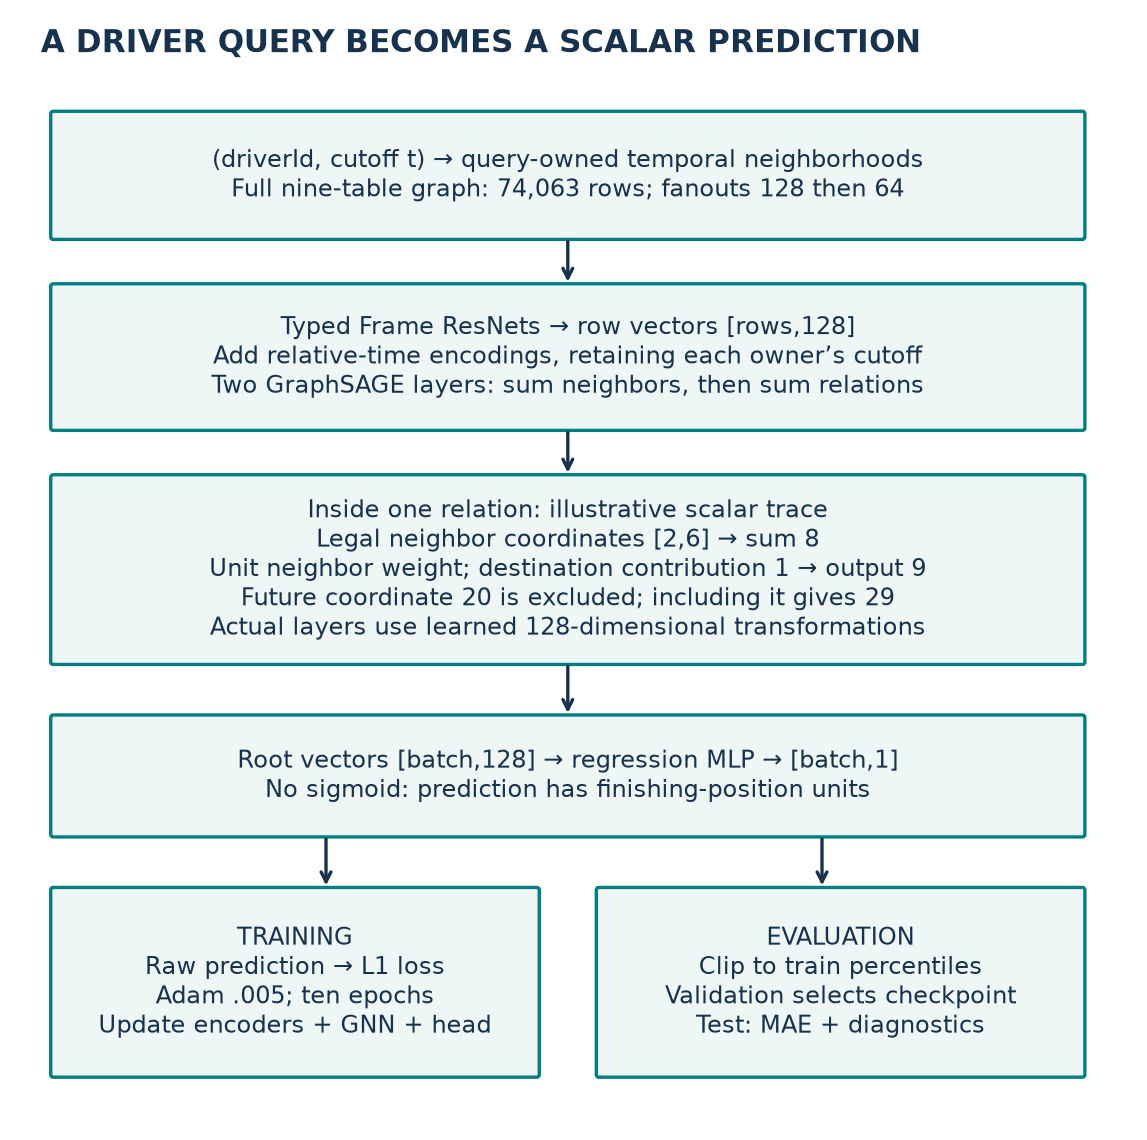<figcaption>Complete released regression pipeline with a worked scalar neighbor-sum trace. Scalar weights are illustrative; actual learned transformations have 128 coordinates. Scroll horizontally on narrow screens.</figcaption></figure>

The visible notebook includes the actual row encoders, graph construction, temporal encoding, message passing, head and trainer. A **fanout** caps the neighbors sampled at a hop: here 128 then 64. An **epoch** is one complete pass over training queries. **Adam** is the adaptive gradient optimizer that updates learned weights; its learning rate controls the step scale. Training compares raw predictions to labels, while validation chooses which saved weights to retain. During training, L1 loss compares the raw scalar prediction with its target. During evaluation, the released implementation clips predictions to the training labels' 2nd and 98th percentiles. Those bounds are fixed from training labels. We preserve this choice for reproduction and diagnose the final clipped predictions. [Pinned model](https://github.com/snap-stanford/relbench/blob/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/examples/model.py)



In [ ]:
# PROVIDED: visible released pipeline stage
"""Visible RDL blueprint and released-protocol model (RelBench MIT license).

The three learner tasks are deliberately usable with only NumPy. The full
experiment uses pinned PyTorch Frame / PyG primitives, not a hidden model wrapper.
"""


In [ ]:
# PROVIDED: visible released pipeline stage
# %% Key identities (PROVIDED)
import numpy as np



In [ ]:
# PROVIDED: visible released pipeline stage
# %% Task 1: map foreign keys to row positions

def foreign_key_edges(primary_keys, foreign_keys):
    lookup = {key: i for i, key in enumerate(primary_keys)}
    if len(lookup) != len(primary_keys):
        raise ValueError("Primary keys must be unique")
    pairs = []
    for source, key in enumerate(foreign_keys):
        if key is None or (isinstance(key, float) and np.isnan(key)):
            continue
        if key not in lookup:
            raise ValueError("Unknown foreign key")
        pairs.append((source, lookup[key]))
    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2).T



In [ ]:
# PROVIDED: visible released pipeline stage
# %% Task 2: preserve one query cutoff across every hop

def temporal_nodes(edges, times, seed, cutoff, hops):
    if times[seed] is not None and times[seed] > cutoff:
        raise ValueError("Seed is unavailable at the query time")
    seen, frontier = {seed}, {seed}
    for _ in range(hops):
        candidates = {dst for src, dst in edges if src in frontier
                      and (times[dst] is None or times[dst] <= cutoff)}
        frontier = candidates - seen
        seen |= candidates
    return sorted(seen)



In [ ]:
# PROVIDED: visible released pipeline stage
# %% Task 3: attach labels by query identity, not entity identity

def query_targets(targets, input_id):
    return np.asarray(targets)[np.asarray(input_id, dtype=np.int64)]



In [ ]:
# PROVIDED: visible released pipeline stage
# %% Full released model dependencies (PROVIDED)
from typing import Any, Dict, List, Optional

import torch
import torch_frame
from torch import Tensor
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.nn import HeteroConv, LayerNorm, PositionalEncoding, SAGEConv
from torch_geometric.typing import EdgeType, NodeType


class HeteroEncoder(torch.nn.Module):
    r"""HeteroEncoder based on PyTorch Frame.

    Args:
        channels (int): The output channels for each node type.
        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):
            A dictionary mapping from node type to column names dictionary
            compatible to PyTorch Frame.
        torch_frame_model_cls: Model class for PyTorch Frame. The class object
            takes :class:`TensorFrame` object as input and outputs
            :obj:`channels`-dimensional embeddings. Default to
            :class:`torch_frame.nn.ResNet`.
        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
            :class:`torch_frame_model_cls` class. Default keyword argument is
            set specific for :class:`torch_frame.nn.ResNet`. Expect it to
            be changed for different :class:`torch_frame_model_cls`.
        default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
            A dictionary mapping from :obj:`torch_frame.stype` object into a
            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
            keyword arguments :obj:`kwargs`.
    """

    def __init__(
        self,
        channels: int,
        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],
        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
        },
    ):
        super().__init__()

        self.encoders = torch.nn.ModuleDict()

        for node_type in node_to_col_names_dict.keys():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](
                    **default_stype_encoder_cls_kwargs[stype][1]
                )
                for stype in node_to_col_names_dict[node_type].keys()
            }
            torch_frame_model = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=node_to_col_stats[node_type],
                col_names_dict=node_to_col_names_dict[node_type],
                stype_encoder_dict=stype_encoder_dict,
            )
            self.encoders[node_type] = torch_frame_model

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(
        self,
        tf_dict: Dict[NodeType, torch_frame.TensorFrame],
    ) -> Dict[NodeType, Tensor]:
        x_dict = {
            node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()
        }
        return x_dict


class HeteroTemporalEncoder(torch.nn.Module):
    def __init__(self, node_types: List[NodeType], channels: int):
        super().__init__()

        self.encoder_dict = torch.nn.ModuleDict(
            {node_type: PositionalEncoding(channels) for node_type in node_types}
        )
        self.lin_dict = torch.nn.ModuleDict(
            {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}
        )

    def reset_parameters(self):
        for encoder in self.encoder_dict.values():
            encoder.reset_parameters()
        for lin in self.lin_dict.values():
            lin.reset_parameters()

    def forward(
        self,
        seed_time: Tensor,
        time_dict: Dict[NodeType, Tensor],
        batch_dict: Dict[NodeType, Tensor],
    ) -> Dict[NodeType, Tensor]:
        out_dict: Dict[NodeType, Tensor] = {}

        for node_type, time in time_dict.items():
            rel_time = seed_time[batch_dict[node_type]] - time
            rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.

            x = self.encoder_dict[node_type](rel_time)
            x = self.lin_dict[node_type](x)
            out_dict[node_type] = x

        return out_dict


class HeteroGraphSAGE(torch.nn.Module):
    def __init__(
        self,
        node_types: List[NodeType],
        edge_types: List[EdgeType],
        channels: int,
        aggr: str = "mean",
        num_layers: int = 2,
    ):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv(
                {
                    edge_type: SAGEConv((channels, channels), channels, aggr=aggr)
                    for edge_type in edge_types
                },
                aggr="sum",
            )
            self.convs.append(conv)

        self.norms = torch.nn.ModuleList()
        for _ in range(num_layers):
            norm_dict = torch.nn.ModuleDict()
            for node_type in node_types:
                norm_dict[node_type] = LayerNorm(channels, mode="node")
            self.norms.append(norm_dict)

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for norm_dict in self.norms:
            for norm in norm_dict.values():
                norm.reset_parameters()

    def forward(
        self,
        x_dict: Dict[NodeType, Tensor],
        edge_index_dict: Dict[NodeType, Tensor],
        num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,
        num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,
    ) -> Dict[NodeType, Tensor]:
        for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        return x_dict



In [ ]:
# PROVIDED: visible released pipeline stage
# %% Relational node predictor (PROVIDED)
from typing import Any, Dict, List

import torch
from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.nn import MLP
from torch_geometric.typing import NodeType




class Model(torch.nn.Module):

    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        # List of node types to add shallow embeddings to input
        shallow_list: List[NodeType] = [],
        # ID awareness
        id_awareness: bool = False,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=channels,
            aggr=aggr,
            num_layers=num_layers,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )

        return self.head(x_dict[entity_table][: seed_time.size(0)])




In [ ]:
# PROVIDED: visible released pipeline stage
# %% Full database to REG and query transform (PROVIDED)
import os
from typing import Any, Dict, NamedTuple, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from torch import Tensor
from torch_frame import stype
from torch_frame.config import TextEmbedderConfig
from torch_frame.data import Dataset
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.typing import NodeType
from torch_geometric.utils import sort_edge_index

from relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType
from relbench.modeling.utils import remove_pkey_fkey, to_unix_time


def make_pkey_fkey_graph(
    db: Database,
    col_to_stype_dict: Dict[str, Dict[str, stype]],
    text_embedder_cfg: Optional[TextEmbedderConfig] = None,
    cache_dir: Optional[str] = None,
) -> Tuple[HeteroData, Dict[str, Dict[str, Dict[StatType, Any]]]]:
    r"""Given a :class:`Database` object, construct a heterogeneous graph with primary-
    foreign key relationships, together with the column stats of each table.

    Args:
        db: A database object containing a set of tables.
        col_to_stype_dict: Column to stype for
            each table.
        text_embedder_cfg: Text embedder config.
        cache_dir: A directory for storing materialized tensor
            frames. If specified, we will either cache the file or use the
            cached file. If not specified, we will not use cached file and
            re-process everything from scratch without saving the cache.

    Returns:
        HeteroData: The heterogeneous :class:`PyG` object with
            :class:`TensorFrame` feature.
    """
    data = HeteroData()
    col_stats_dict = dict()
    if cache_dir is not None:
        os.makedirs(cache_dir, exist_ok=True)

    for table_name, table in db.table_dict.items():
        # Materialize the tables into tensor frames:
        df = table.df
        # Ensure that pkey is consecutive.
        if table.pkey_col is not None:
            assert (df[table.pkey_col].values == np.arange(len(df))).all()

        col_to_stype = col_to_stype_dict[table_name]

        # Remove pkey, fkey columns since they will not be used as input
        # feature.
        remove_pkey_fkey(col_to_stype, table)

        if len(col_to_stype) == 0:  # Add constant feature in case df is empty:
            col_to_stype = {"__const__": stype.numerical}
            # We need to add edges later, so we need to also keep the fkeys
            fkey_dict = {key: df[key] for key in table.fkey_col_to_pkey_table}
            df = pd.DataFrame({"__const__": np.ones(len(table.df)), **fkey_dict})

        path = (
            None if cache_dir is None else os.path.join(cache_dir, f"{table_name}.pt")
        )

        dataset = Dataset(
            df=df,
            col_to_stype=col_to_stype,
            col_to_text_embedder_cfg=text_embedder_cfg,
        ).materialize(path=path)

        data[table_name].tf = dataset.tensor_frame
        col_stats_dict[table_name] = dataset.col_stats

        # Add time attribute:
        if table.time_col is not None:
            data[table_name].time = torch.from_numpy(
                to_unix_time(table.df[table.time_col])
            )

        # Add edges:
        for fkey_name, pkey_table_name in table.fkey_col_to_pkey_table.items():
            pkey_index = df[fkey_name]
            # Filter out dangling foreign keys
            mask = ~pkey_index.isna()
            fkey_index = torch.arange(len(pkey_index))
            # Filter dangling foreign keys:
            pkey_index = torch.from_numpy(pkey_index[mask].astype(int).values)
            fkey_index = fkey_index[torch.from_numpy(mask.values)]
            # Ensure no dangling fkeys
            assert (pkey_index < len(db.table_dict[pkey_table_name])).all()

            # fkey -> pkey edges
            edge_index = torch.stack([fkey_index, pkey_index], dim=0)
            edge_type = (table_name, f"f2p_{fkey_name}", pkey_table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

            # pkey -> fkey edges.
            # "rev_" is added so that PyG loader recognizes the reverse edges
            edge_index = torch.stack([pkey_index, fkey_index], dim=0)
            edge_type = (pkey_table_name, f"rev_f2p_{fkey_name}", table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

    data.validate()

    return data, col_stats_dict


class AttachTargetTransform:
    r"""Attach the target label to the heterogeneous mini-batch.

    The batch consists of disjoins subgraphs loaded via temporal sampling. The same
    input node can occur multiple times with different timestamps, and thus different
    subgraphs and labels. Hence labels cannot be stored in the graph object directly,
    and must be attached to the batch after the batch is created.
    """

    def __init__(self, entity: str, target: Tensor):
        self.entity = entity
        self.target = target

    def __call__(self, batch: HeteroData) -> HeteroData:
        batch[self.entity].y = self.target[batch[self.entity].input_id]
        return batch


class NodeTrainTableInput(NamedTuple):
    r"""Training table input for node prediction.

    - nodes is a Tensor of node indices.
    - time is a Tensor of node timestamps.
    - target is a Tensor of node labels.
    - transform attaches the target to the batch.
    """

    nodes: Tuple[NodeType, Tensor]
    time: Optional[Tensor]
    target: Optional[Tensor]
    transform: Optional[AttachTargetTransform]


def get_node_train_table_input(
    table: Table,
    task: EntityTask,
) -> NodeTrainTableInput:
    r"""Get the training table input for node prediction."""

    nodes = torch.from_numpy(table.df[task.entity_col].astype(int).values)

    time: Optional[Tensor] = None
    if table.time_col is not None:
        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

    target: Optional[Tensor] = None
    transform: Optional[AttachTargetTransform] = None
    if task.target_col in table.df:
        target_type = float
        if task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
            target_type = int
        if task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
            target = torch.from_numpy(np.stack(table.df[task.target_col].values))
        else:
            target = torch.from_numpy(
                table.df[task.target_col].values.astype(target_type)
            )
        transform = AttachTargetTransform(task.entity_table, target)

    return NodeTrainTableInput(
        nodes=(task.entity_table, nodes),
        time=time,
        target=target,
        transform=transform,
    )




In [ ]:
# PROVIDED: visible released pipeline stage
# %% Full released-protocol training loop (PROVIDED)
import copy
import hashlib
import json
import time
from pathlib import Path
from torch_geometric.loader import NeighborLoader
from torch_geometric.seed import seed_everything

CONFIG = dict(channels=128, num_layers=2, batch_size=512, lr=.005,
              epochs=10, fanout=[128,64], aggr='sum', temporal_strategy='uniform')
TARGETS = dict(val=3.193, test=4.022)


def fit_rdl(data, stats, task, seed, output, epochs=10, device='cuda', original_model=None):
    """Train all query rows; select first lowest validation MAE, replay all outputs."""
    seed_everything(seed)
    output=Path(output);output.mkdir(parents=True,exist_ok=True)
    start=time.perf_counter()
    loaders={}
    tables={s:task.get_table(s,mask_input_cols=False) for s in ['train','val','test']}
    for split in tables:
        # Test labels are for independent scoring, never attached to model input.
        inp=get_node_train_table_input(task.get_table(split),task)
        loaders[split]=NeighborLoader(data,num_neighbors=CONFIG['fanout'],
            time_attr='time',input_nodes=inp.nodes,input_time=inp.time,
            transform=inp.transform,batch_size=512,temporal_strategy='uniform',
            shuffle=split=='train',num_workers=0)
    model=Model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
    optimizer=torch.optim.Adam(model.parameters(),lr=.005)
    bounds=np.percentile(tables['train'].df[task.target_col].to_numpy(),[2,98])
    best=float('inf');state=None;trace=[]
    @torch.no_grad()
    def predict(loader,reference=None):
        model.eval();out=[];max_error=0.;nodes=0
        for batch in loader:
            batch=batch.to(device)
            # Every dated sampled row obeys its root query timestamp.
            for kind,stamp in batch.time_dict.items():
                assert (stamp<=batch[task.entity_table].seed_time[batch[kind].batch]).all()
            value=model(batch,task.entity_table)
            if reference is not None:
                other=reference(batch,task.entity_table)
                torch.testing.assert_close(value,other,rtol=1e-5,atol=1e-5)
                max_error=max(max_error,float((value-other).abs().max()))
            out.append(value.clamp(*bounds).view(-1).cpu().numpy())
            nodes+=sum(batch.num_nodes_dict.values())
        return np.concatenate(out),max_error,nodes
    for epoch in range(1,epochs+1):
        model.train();loss_sum=0.;count=0
        for batch in loaders['train']:
            batch=batch.to(device);optimizer.zero_grad()
            pred=model(batch,task.entity_table).view(-1)
            loss=torch.nn.functional.l1_loss(pred.float(),batch[task.entity_table].y.float())
            loss.backward();optimizer.step()
            count+=len(pred);loss_sum+=float(loss.detach())*len(pred)
        assert count==7453
        val,_,_=predict(loaders['val'])
        score=float(np.mean(np.abs(val-tables['val'].df[task.target_col].to_numpy())))
        trace.append(dict(epoch=epoch,train_mae=loss_sum/count,val_mae=score,train_queries=count))
        if score<best:best=score;state=copy.deepcopy(model.state_dict());selected=epoch
        print(json.dumps(trace[-1]),flush=True)
    model.load_state_dict(state);model.eval()
    torch.save(state,output/'selected.pt')
    # Reference construction consumes RNG; save/restore to preserve sampler sequence.
    rng=torch.get_rng_state();cuda_rng=torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    reference=None
    if original_model is not None:
        reference=original_model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
        reference.load_state_dict(state);reference.eval()
    torch.set_rng_state(rng)
    if cuda_rng is not None:torch.cuda.set_rng_state_all(cuda_rng)
    scores={};replays={};arrays={}
    for split in ['val','test']:
        pred,err,nodes=predict(loaders[split],reference)
        target=tables[split].df[task.target_col].to_numpy()
        scores[split]=float(np.mean(np.abs(pred-target)))
        official=task.evaluate(pred,tables[split])['mae']
        assert abs(scores[split]-official)<1e-10
        arrays[split+'_pred']=pred;arrays[split+'_target']=target
        arrays[split+'_entity']=tables[split].df[task.entity_col].to_numpy()
        arrays[split+'_time']=tables[split].df[task.time_col].astype('int64').to_numpy()
        replays[split]=dict(queries=len(pred),max_original_logit_error=err,sampled_nodes=nodes)
    np.savez_compressed(output/'predictions.npz',**arrays)
    result=dict(seed=seed,epochs=epochs,selected_epoch=selected,selection_mae=best,
        scores=scores,replay=replays,trace=trace,clamp=bounds.tolist(),seconds=time.perf_counter()-start,
        protocol=CONFIG,checkpoint_sha256=hashlib.sha256((output/'selected.pt').read_bytes()).hexdigest())
    (output/'result.json').write_text(json.dumps(result,indent=2));return result


## 3 · Compute error without changing the question

> **In plain terms.** MAE treats each unit of error equally. RMSE makes large misses count more heavily. Neither number is a probability or a percentage.

Let `p` be a prediction, `y` its target and `n` the number of queries. **MAE** is `sum(abs(p-y))/n`. **RMSE** is `sqrt(sum((p-y)^2)/n)`. Both have the target's units: finishing-position units here. **Bias**, defined here as `mean(p-y)`, retains direction: positive means predicting worse finishing positions on average. Opposing errors can cancel in bias, so zero bias does not imply accuracy.

**Worked example.** Targets `[2,5]` and predictions `[3,3]` produce errors `[1,-2]`. MAE is `(1+2)/2 = 1.5`; RMSE is `sqrt((1+4)/2) ≈ 1.581`; bias is `-0.5`. Reversing prediction records must not alter those values when their query keys are preserved.

**Lab task 1 — `keyed_metrics`.** Join complete unique key sets, reject duplicates, missing rows and nonfinite values, then compute the three metrics. Your function scores all saved author predictions and your own fresh runs. The CHECK includes the same driver at two cutoffs, so joining only by driver cannot pass.

<figure class="route-figure" tabindex="0">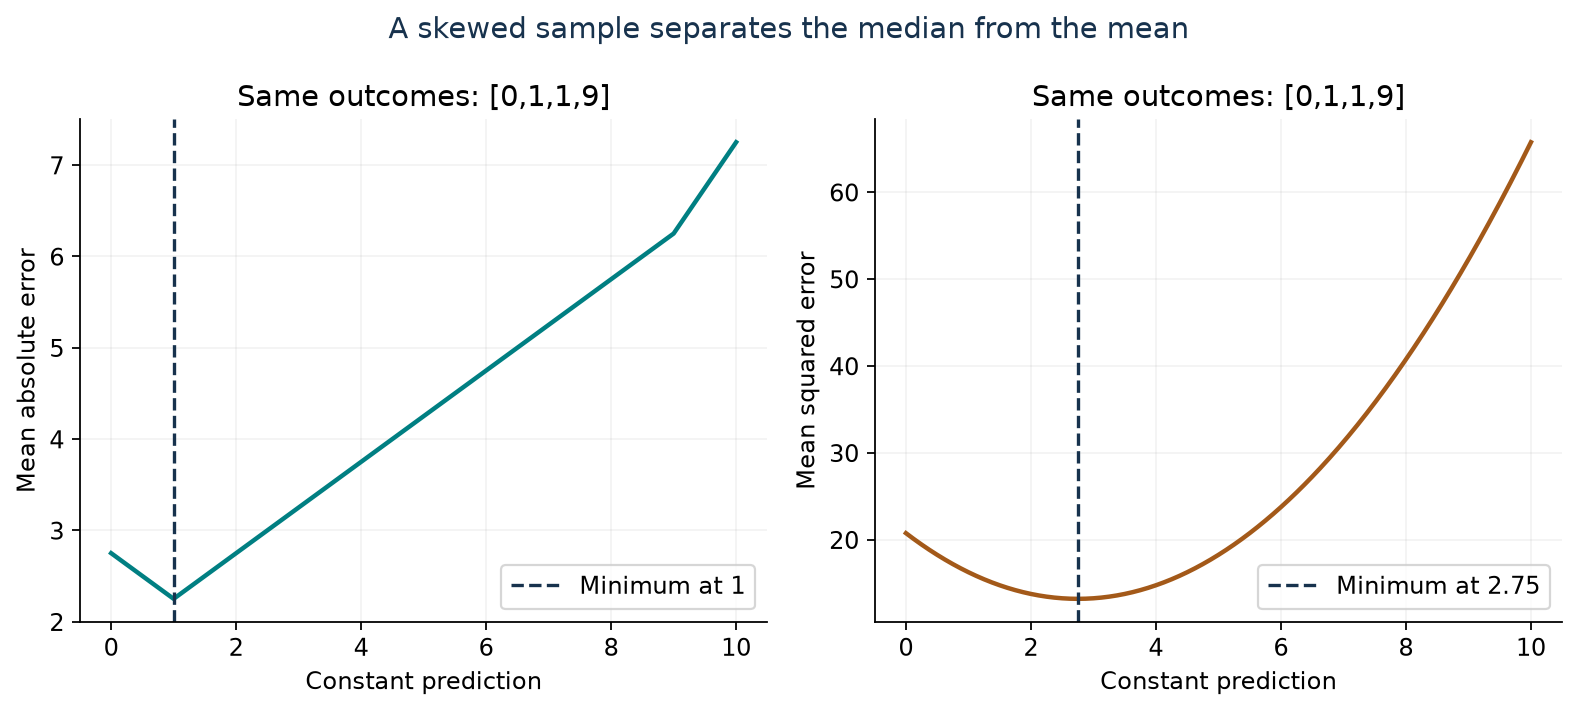<figcaption>The same skewed outcomes have median 1 and mean 2.75. L1 and squared error ask for different predictions. Scroll horizontally on narrow screens.</figcaption></figure>

**Why the median appears.** Hold the inputs fixed and imagine future labels `[0,1,1,9]`. Predicting 1 gives MAE `2.25`; predicting their mean `2.75` gives MAE `3.125`. Moving the prediction slightly upward increases the distance to every smaller outcome and decreases the distance to every larger outcome. Absolute error is minimized when neither side contains more than half the probability: a **conditional median**. Squared error instead balances the sum of signed distances, producing a **conditional mean**. “Conditional” means among outcomes possible for the same available information.

The neural network has finite data and capacity, and clipping can alter its output. L1 training therefore *targets* a conditional median; it does not prove the trained model found one. RMSE is a secondary diagnostic here. It never selects the checkpoint or changes our primary MAE comparison. [Regression calibration and target functionals](https://arxiv.org/abs/2108.03210)



In [ ]:
# TODO: this live function is called by both evidence lanes.
def keyed_metrics(queries, predictions):
    raise NotImplementedError("TODO: keyed_metrics")

In [ ]:
# CHECK: run unchanged.
def rejects(f,*args):
    try:f(*args)
    except ValueError:return
    raise AssertionError('Invalid evidence accepted')
def check_metrics(f):
    q=[dict(entity=7,time=10,target=2.),dict(entity=7,time=20,target=5.)]
    p=[dict(entity=7,time=20,prediction=3.),dict(entity=7,time=10,prediction=3.)]
    r=f(q,p);assert r['mae']==1.5 and abs(r['rmse']-math.sqrt(2.5))<1e-12 and r['bias']==-.5 and r['n']==2
    assert r==f(list(reversed(q)),p)
    rejects(f,q,p[:1]);rejects(f,q,[p[0],p[0]]);rejects(f,[q[0],q[0]],p)
    rejects(f,q,[p[0],dict(entity=7,time=11,prediction=3.)])
    rejects(f,q,[p[0],dict(entity=7,time=10,prediction=float('nan'))]);rejects(f,[],[])
check_metrics(keyed_metrics)
print("PASS keyed_metrics")

## 4 · Check median balance without mistaking ties for failure

> **In plain terms.** For a median prediction, no more than half the outcomes should lie strictly below it, and no more than half strictly above it. Outcomes exactly equal to the prediction count as ties.

**Worked example.** For `[0,1,1,9]` predicted as `[1,1,1,1]`, the fractions below/equal/above are `.25/.50/.25`. The median inequalities hold even though the fraction *at or below* is `.75`, not `.50`. The mean residual `mean(y-p)` is `1.75`; demanding zero mean residual would ask this L1 model to target a different quantity. Notice that residual `y-p` has the opposite sign to our reported bias `p-y`.

We group predictions into bins to inspect different prediction ranges. Each seed's final validation predictions define unique 20th/40th/60th/80th percentile edges. We freeze those edges before making test diagnostics. A prediction equal to an edge enters the bin on its right. Duplicate edges are collapsed; empty bins remain visible. Test labels never choose the bins or a correction.

For each occupied bin, report its count, strict-below fraction, tie fraction and strict-above fraction. Our descriptive **median violation** is `max(0, below - .5, above - .5)`. Zero says these two empirical inequalities hold for that bin. It does not prove conditional calibration: grouping can hide local errors, finite samples fluctuate, and repeated driver queries are dependent. These plots carry counts, not unjustified independent-observation confidence intervals.

Static tie example: targets0,1,1,9; prediction1; below/equal/above=.25/.50/.25; median violation0; MAE2.25. Predicting2.75 changes MAE to3.125 and violation to.25.

**Lab task 2 — `median_diagnostics`.** Implement fixed-edge assignment and the tie-aware fractions. Preserve an empty bin as `n=0` with undefined statistics, rather than reporting a reassuring zero. Checks distinguish a skewed but median-balanced sample from a genuinely unbalanced one.

<figure class="route-figure" tabindex="0">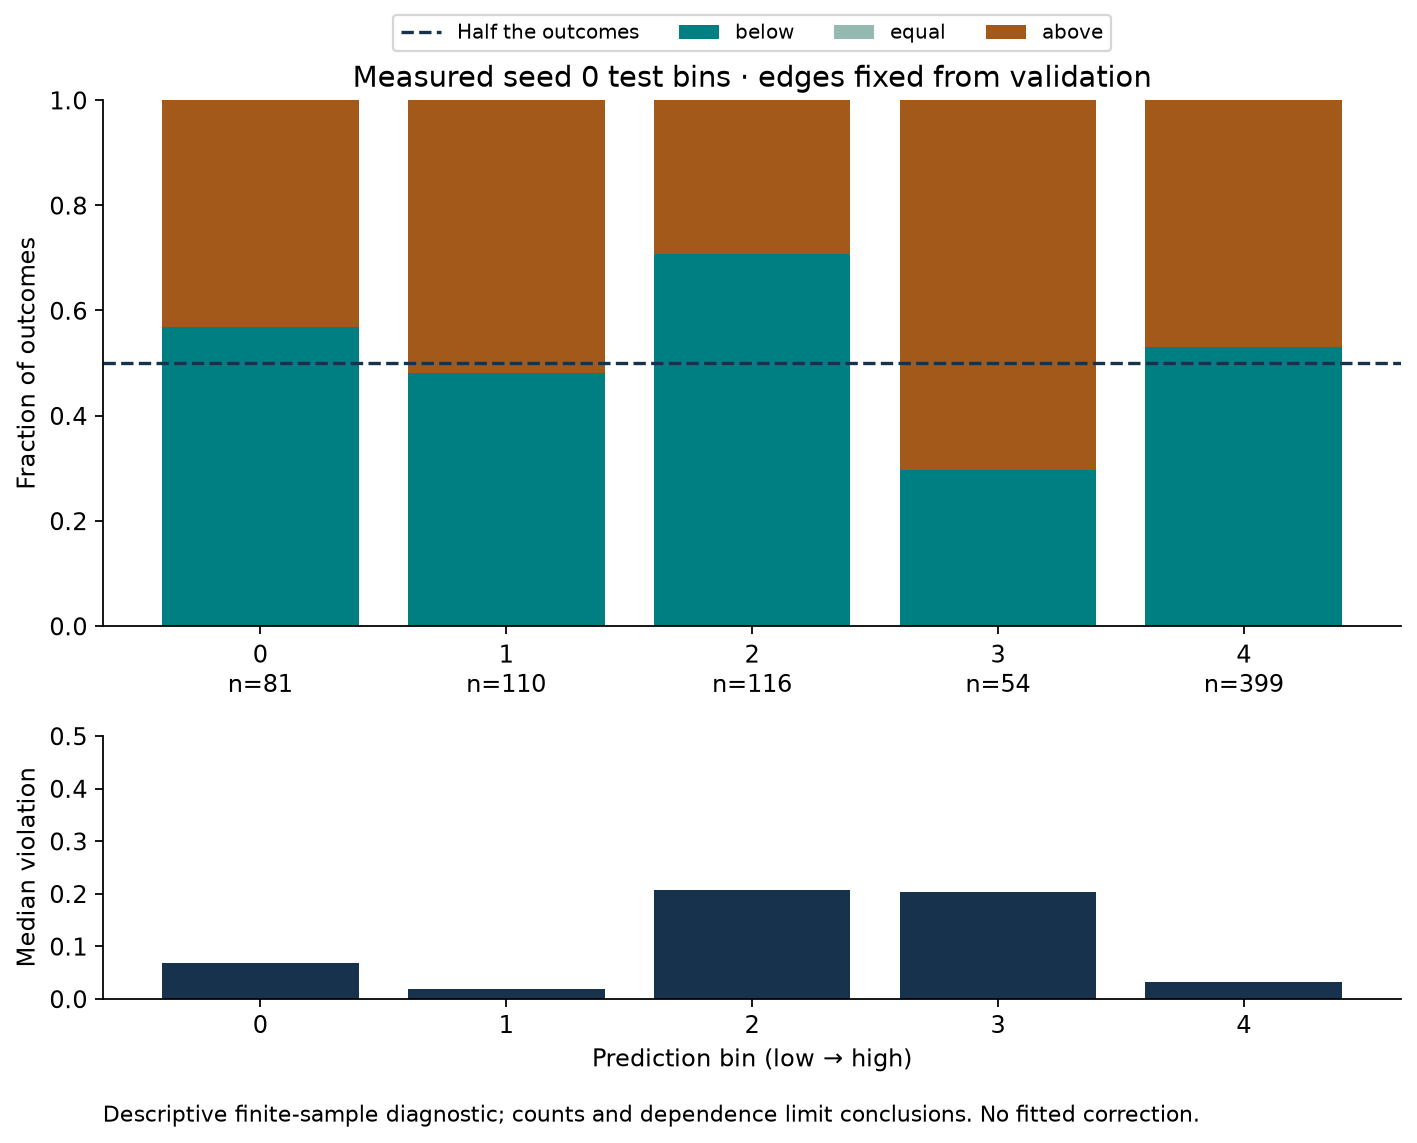<figcaption>Measured seed 0 held-out bins, with edges frozen from validation predictions. Strict fractions retain ties; counts accompany the diagnostic. Scroll horizontally on narrow screens.</figcaption></figure>

**Read the measured plot.** In seed 0's third bin (index 2), 82 of 116 outcomes fall strictly below their prediction: `82/116 ≈ .707`, so the descriptive violation is `.207`. In the next bin, 38 of 54 lie strictly above, giving `.704` and violation `.204`. The opposing directions are why one overall bias can hide local imbalance. These are observations, not significance tests; no test-driven model change follows.

This is a diagnostic extension to the published experiment, not a published calibration result. We do not fit a calibration correction, search new losses, or change the reproduction after inspecting test outcomes. The existing classification reliability curve from Lesson 8 compares probabilities with event frequencies; it cannot be reused unchanged for a scalar median.



In [ ]:
# TODO: this live function is called by both evidence lanes.
def median_diagnostics(target, prediction, edges):
    raise NotImplementedError("TODO: median_diagnostics")

In [ ]:
# CHECK: run unchanged.
def rejects(f,*args):
    try:f(*args)
    except ValueError:return
    raise AssertionError('Invalid evidence accepted')
def check_diagnostics(f):
    r=f([0,1,1,9],[1,1,1,1],[1,2])
    assert [b['n'] for b in r]==[0,4,0]
    b=r[1];assert b['below']==.25 and b['equal']==.5 and b['above']==.25 and b['median_violation']==0
    assert b['mean_residual']==1.75 # mean bias despite empirical median balance
    assert r[0]['median_violation'] is None
    b=f([0,0,0,9],[1]*4,[])[0];assert b['median_violation']==.25
    assert f([1,1,1],[1]*3,[1])[1]['median_violation']==0
    rejects(f,[1],[1],[2,1]);rejects(f,[1],[1],[1,1]);rejects(f,[1,2],[1],[])
    rejects(f,[1],[float('inf')],[]);rejects(f,[1],[1],[float('nan')])
check_diagnostics(median_diagnostics)
print("PASS median_diagnostics")

## 5 · Run the named experiment, then report every seed

**Held fixed:** source commit, archive hashes, full query populations, architecture, preprocessing, ten epochs, Adam learning rate `.005`, batch 512, fanouts `[128,64]`, L1 loss and train-derived clipping. **Varied:** initialization and sampling seeds 0–4. **Measured:** validation/test MAE, secondary RMSE, complete traces and diagnostics. The first strict validation-MAE improvement chooses the checkpoint. A tied later epoch does not replace it. Final validation uses new sampled neighborhoods, so preserve both selection MAE and final validation MAE.

Our primary source is [RelBench v1, Table 7 and Appendix B.2](https://arxiv.org/html/2407.20060v1#A2.T7). Read the F1 row and the architecture/training description before opening the results. The published test target is `4.022 ± 0.119` MAE; our frozen descriptive mean tolerance is `±0.20`. The five fresh seeds report their mean and **sample standard deviation**, which divides squared deviations by `n-1`. Seed variation does not measure uncertainty across new databases or future seasons.

Predict before reading: does zero empirical median violation guarantee future conditional calibration? Explain why not.

| Seed | Selected epoch | Selection MAE | Final val MAE | Test MAE | Test RMSE | Test bias |
|---|---:|---:|---:|---:|---:|---:|
| 0 | 9 | 3.205062 | 3.207255 | 3.933465 | 4.723830 | +0.502623 |
| 1 | 9 | 3.108677 | 3.110727 | 3.840081 | 4.704185 | +0.285210 |
| 2 | 10 | 3.239623 | 3.240849 | 3.873139 | 4.724245 | +0.042989 |
| 3 | 10 | 3.189180 | 3.185877 | 3.958161 | 4.861776 | +0.784117 |
| 4 | 7 | 3.159506 | 3.156182 | 4.249352 | 5.190039 | +1.525781 |

**Five fresh fits:** validation MAE **3.180178 ± 0.049613**; test MAE **3.970840 ± 0.162612**; test RMSE **4.840815 ± 0.205145**. Mean ± sample seed SD, finishing-position units. Test mean: **CLOSE** under the frozen ±0.20 descriptive rule. These are new runs, not earlier-lesson scores.


<figure class="route-figure" tabindex="0">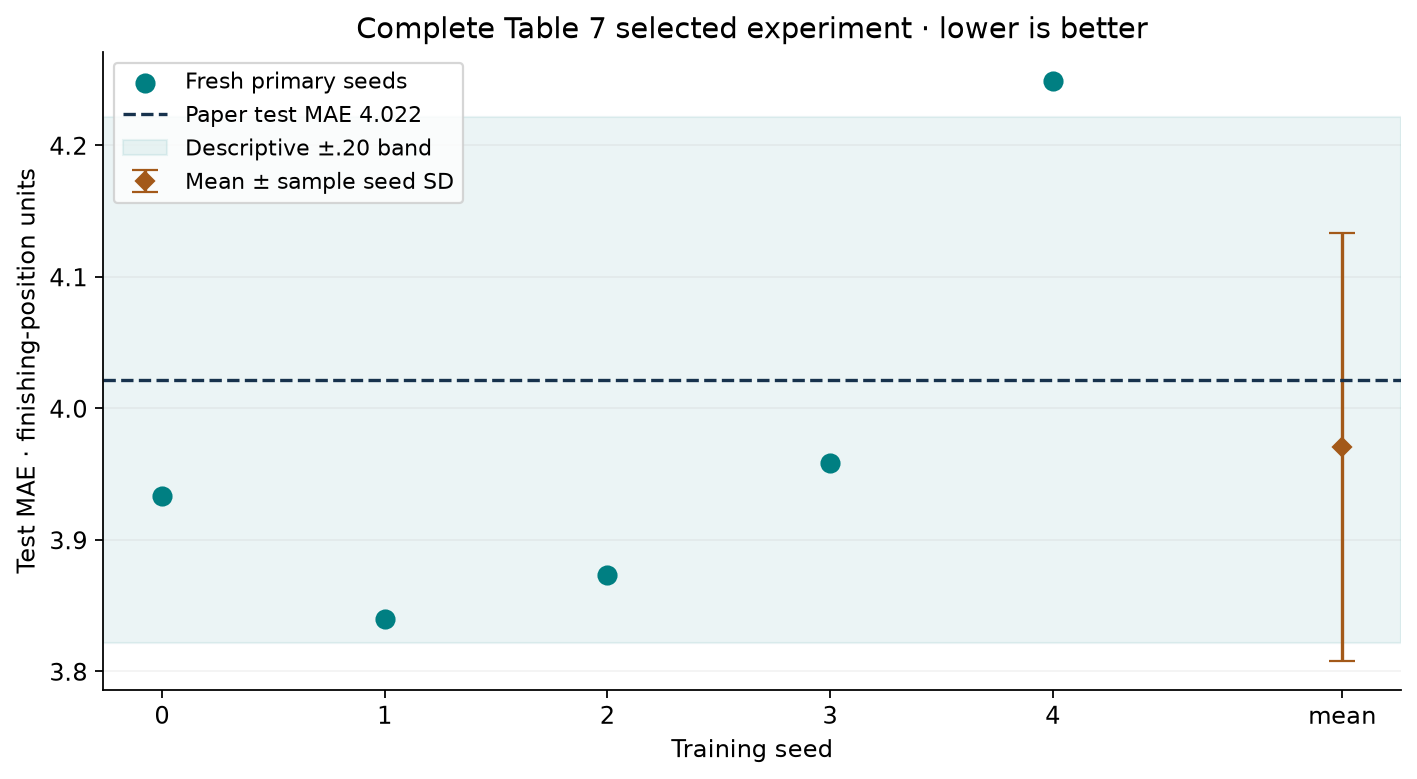<figcaption>Five complete primary runs with mean and sample seed SD. The band is descriptive closeness, not equivalence. Scroll horizontally on narrow screens.</figcaption></figure>

**Lab task 3 — `portfolio_summary`.** Require exactly the five planned seeds and ten completed epochs each. Summarize MAE and RMSE; separate the score-closeness flag from historical identity and learner mastery. A missing or failed seed is not silently dropped.

All **8,712 labels** were independently reconstructed from raw result rows. All **6,295 primary predictions** were aligned to the archive and independently rescored. Every training/evaluation batch was audited: **403,895 query occurrences**, zero owner-cutoff violations. Original-model held-out output comparisons passed, maximum discrepancy **3.81e-06**.

First-backward nonfinite-gradient counts by seed: **{'0': 640, '1': 640, '2': 640, '3': 640, '4': 640}**. We retained the released computation. Exact source structure and a small local neural gradient/update check passed; they do not certify healthy optimization on real data.

Primary measured worker-body cost estimate **USD 0.059556** excludes unitemized overhead. Current reservations plus the USD3 overhead allowance total **USD 5.437776** under the aggregate USD10 cap. This is a conservative resource allowance, not an itemized invoice. [Evidence](https://avistian.github.io/relational/labs/evidence/l152/summary.json) · [Budget ledger](https://avistian.github.io/relational/labs/_budget_l152.json).

The portable full GPU gate also executed **23 code cells** and **five additional ten-epoch fits**, independently rescoring **6295 predictions** in an isolated pinned runtime. Those runs are separate from the primary mean. Live Colab and deployment remain NOT_CHECKED.


> **Scope check.** This F1 test population has appeared in earlier lessons. Fresh execution does not create a new holdout. A close score does not establish historical run identity or statistical equivalence. No fresh manual-feature baseline is trained here; we cannot conclude from this entry alone that RDL beats manual feature engineering. Whole-paper reproduction remains NOT_RUN.



In [ ]:
# TODO: this live function is called by both evidence lanes.
def portfolio_summary(records):
    raise NotImplementedError("TODO: portfolio_summary")

In [ ]:
# CHECK: run unchanged.
def rejects(f,*args):
    try:f(*args)
    except ValueError:return
    raise AssertionError('Invalid evidence accepted')
def check_summary(f):
    rows=[dict(seed=s,epochs=10,complete=True,val_mae=3.193,test_mae=4.022,test_rmse=5.) for s in range(5)]
    r=f(rows);assert r['test']['mean']==4.022 and r['test']['sample_sd']==0 and r['paper_score']=='CLOSE'
    assert r['learner']=='PENDING_WRITTEN_DEFENSE' and r['historical_identity']=='NOT_ESTABLISHED'
    rejects(f,rows[:4]);rejects(f,rows[:4]+[rows[0]])
    for field,value in [('epochs',9),('complete',False),('test_mae',float('nan')),('test_rmse',-1)]:
        broken=[dict(x) for x in rows];broken[0][field]=value;rejects(f,broken)
    assert f([dict(x,test_mae=4.3) for x in rows])['paper_score']=='OUTSIDE_TOLERANCE'
check_summary(portfolio_summary)
print("PASS portfolio_summary")

In [ ]:
# CHECK: live functions evaluate every primary author prediction.
records=[];all_bins={};count=0
for r in AUTHOR_SUMMARY['records']:
    item=PAYLOAD[str(r['seed'])];raw=base64.b64decode(item['data']);assert hashlib.sha256(raw).hexdigest()==item['sha256']
    arrays=np.load(io.BytesIO(raw));metrics={}
    for split in ['val','test']:
        q=[dict(entity=int(e),time=int(t),target=float(y)) for e,t,y in zip(arrays[split+'_entity'],arrays[split+'_time'],arrays[split+'_target'])]
        pred=[dict(entity=int(e),time=int(t),prediction=float(v)) for e,t,v in zip(arrays[split+'_entity'],arrays[split+'_time'],arrays[split+'_pred'])]
        metrics[split]=keyed_metrics(q,list(reversed(pred)));count+=metrics[split]['n']
        assert abs(metrics[split]['mae']-r[split+'_mae'])<1e-12
    edges=np.unique(np.quantile(arrays['val_pred'],[.2,.4,.6,.8])).tolist()
    bins={s:median_diagnostics(arrays[s+'_target'],arrays[s+'_pred'],edges) for s in ['val','test']}
    assert bins==AUTHOR_SUMMARY['bins'][str(r['seed'])]
    all_bins[str(r['seed'])]=dict(edges=edges,bins=bins)
    records.append(dict(r,val_mae=metrics['val']['mae'],test_mae=metrics['test']['mae'],test_rmse=metrics['test']['rmse']))
metrics=portfolio_summary(records);assert metrics==AUTHOR_SUMMARY['metrics'];assert count==6295
display(pd.DataFrame(records));display(pd.DataFrame(all_bins['0']['bins']['test']))
entry=dict(evidence_owner='AUTHOR_PACKET_INDEPENDENTLY_RESCORED',task='rel-f1/driver-position',protocol=json.loads(SOURCE_FILES['sources/l152/protocol.json']),records=records,metrics=metrics,diagnostics=all_bins,source_hashes=AUTHOR_SUMMARY['hashes'],written_defense=None)
Path('l152-portfolio-entry.json').write_text(json.dumps(entry,indent=2))
print('AUTHOR_PACKET_INDEPENDENTLY_RESCORED: 6295 predictions; learner PENDING_WRITTEN_DEFENSE')


## 6 · Export portfolio entry 2 and defend it

Open the [student notebook](https://avistian.github.io/relational/labs/0152-regression-portfolio.ipynb), [prepared notebook](https://avistian.github.io/relational/labs/html/0152-regression-portfolio.html), [reference](https://avistian.github.io/relational/reference/regression-portfolio.html), [protocol](https://avistian.github.io/relational/labs/l152-reproduction.md), and [entry template](https://avistian.github.io/relational/labs/l152-entry-template.md).

The default notebook independently scores a self-contained author evidence packet. Its live learner functions produce `l152-portfolio-entry.json`. The separate full GPU gate downloads verified archives, constructs fresh graphs and trains all five seeds from the visible implementation, producing an entry labeled `OWN_FRESH_RUN`. CPU author-evidence auditing does not become fresh training merely because it runs in your notebook.

**EXIT.** Export the entry and write 250–400 words defending: the query population; why MAE and L1 belong together; why ties change a median check; how validation fixes selection and diagnostic bins; and what this entry does not establish. Explain one measured bin with its count and propose a falsifiable follow-up. Ask the teaching agent about any unclear step and submit your defense for review.

Write your explanation before reviewing the teacher solution. Submit it to the teaching agent.

The review rubric awards 0–2 points each for task/units, loss/metric alignment, calibration reasoning, evidence integrity and bounded claims. Readiness requires at least 8/10 with no zero. Author execution leaves `PENDING_WRITTEN_DEFENSE`.

**Spaced return.** Tomorrow, reconstruct the tie example without looking. In one week, explain how MAE can look good while some prediction ranges have unbalanced errors. Lesson 153 adds recommendation/ranking; Lesson 154 will compare portfolio entries without averaging incompatible raw metric units.


## Post-EXIT · Complete fresh reproduction appendix

The full visible model/trainer above and preprocessing/audits below execute the released experiment. Source and MIT license files are embedded, then written into this notebook’s working directory. RUN_FULL_REPRODUCTION=False by default. Enable it only in the pinned CUDA runtime with native pyg-lib; install using the included requirements and the operator image recipe. The author uses T4 +2CPU +16GiB host RAM. Local notebook execution has no monetary guard; the supplied Modal operator reserves cost before dispatch. Output directories are single-use. Five complete fits are required; no subsets count as the full experiment.

In [ ]:
# PROVIDED: fresh archive verification, text encoding and graph construction
"""Prepare full F1 graph then run a bounded released-protocol experiment."""
import argparse,hashlib,importlib.util,json,sys,time
from pathlib import Path
import numpy as np
import torch
from relbench.datasets import get_dataset
from relbench.tasks import get_task
from relbench.modeling.utils import get_stype_proposal
from torch_frame.config import TextEmbedderConfig
from torch_geometric.seed import seed_everything
P=Path.cwd()

def prepare_and_fit(seed,epochs,output):
    from sentence_transformers import SentenceTransformer
    torch.set_num_threads(1);start=time.perf_counter();seed_everything(42)
    dataset=get_dataset('rel-f1',download=True);db=dataset.get_db()
    task=get_task('rel-f1','driver-position',download=True)
    hashes={}
    for name,expected in [('db.zip','ec31a4e1bc2b2f9c36c05fcd3dfe2a40a506f335dc51ce79c3ec8bb40feb1482'),('tasks/driver-position.zip','775b28a51604169539bbe712a2f0d15158c112bc6abf316cdd0995087a7ae03e')]:
        path=Path(dataset.cache_dir)/name
        digest=hashlib.sha256(path.read_bytes()).hexdigest();assert digest==expected;hashes[name]=digest
    types=get_stype_proposal(db)
    spec=json.loads((P/'sources/l117/text_model.json').read_text())
    text_model=SentenceTransformer(spec['model'],revision=spec['revision'],device='cpu')
    def embed(strings):return torch.from_numpy(text_model.encode(strings,show_progress_bar=False))
    data,stats=make_pkey_fkey_graph(db,types,TextEmbedderConfig(text_embedder=embed,batch_size=256))
    del text_model
    # Compare every edge with an independent SQL-style key lookup from database rows.
    for table_name,table in db.table_dict.items():
        for fk,dst in table.fkey_col_to_pkey_table.items():
            parent=db.table_dict[dst];keys=parent.df[parent.pkey_col].tolist()
            values=[None if __import__('pandas').isna(x) else int(x) for x in table.df[fk]]
            edge=foreign_key_edges(keys,values)
            actual=data[(table_name,'f2p_'+fk,dst)].edge_index.numpy()
            assert set(map(tuple,actual.T))==set(map(tuple,edge.T))
    sys.path.insert(0,str(P/'sources/l117'))
    from model import Model as OriginalModel
    # Check installed RelBench primitives match the pinned upstream source exactly.
    import relbench.modeling.nn as nn
    assert Path(nn.__file__).read_bytes()==(P/'sources/l117/nn.py').read_bytes()
    output=Path(output);output.mkdir(parents=True,exist_ok=True)
    import importlib.metadata as md
    audit=dict(database_hashes=hashes,rows={k:len(v) for k,v in db.table_dict.items()},
        edges={'|'.join(k):v.shape[1] for k,v in data.edge_index_dict.items()},
        stypes={k:{c:str(s) for c,s in v.items()} for k,v in types.items()},
        preprocessing='Released full database up to test cutoff; statistics are not train-only',
        preprocessing_seed=42,text_model=spec,packages={k:md.version(k) for k in ['torch','torch-geometric','pytorch-frame','relbench','numpy','pandas','sentence-transformers','pyg-lib']},
        source_sha256=hashlib.sha256((P/'relkit/rdl_l117.py').read_bytes()).hexdigest())
    (output/'audit.json').write_text(json.dumps(audit,indent=2))
    result=fit_rdl(data,stats,task,seed,output,epochs,'cuda' if torch.cuda.is_available() else 'cpu',OriginalModel)
    result['total_seconds']=time.perf_counter()-start
    (output/'result.json').write_text(json.dumps(result,indent=2));return result



In [ ]:
# PROVIDED: every sampled occurrence is checked against its original graph
"""Released-loader audit: source identity, node cutoff and disjoint queries."""
import torch

def audit_batch(batch, graph, entity):
    roots=batch[entity].seed_time
    dated=edges=0
    for kind in batch.node_types:
        store=batch[kind]
        assert store.batch.shape==store.n_id.shape
        assert (store.batch>=0).all() and (store.batch<len(roots)).all()
        if 'time' in graph[kind]:
            expected=graph[kind].time[store.n_id.cpu()].to(store.time.device)
            assert torch.equal(store.time,expected), 'Timestamp no longer belongs to this global node'
            assert (store.time<=roots[store.batch]).all(), 'Future node at its root query cutoff'
            dated+=len(store.time)
    for kind in batch.edge_types:
        src,_,dst=kind;store=batch[kind];a,b=store.edge_index
        assert torch.equal(batch[src].batch[a],batch[dst].batch[b]), 'Cross-query edge'
        actual=torch.stack([batch[src].n_id[a],batch[dst].n_id[b]]).cpu()
        expected=graph[kind].edge_index[:,store.e_id.cpu()]
        assert torch.equal(actual,expected), 'Wrong original edge identity'
        edges+=len(a)
    n=batch[entity].batch_size
    assert torch.equal(batch[entity].batch[:n],torch.arange(n,device=roots.device))
    return dict(batches=1,queries=n,dated_node_occurrences=dated,edge_occurrences=edges)


In [ ]:
# PROVIDED: instrumented full training invokes your functions
"""Run unchanged L117 training with transparent audits on every loader yield."""
import json,hashlib
from pathlib import Path
import torch


def run(seed,epochs,output):
    global NeighborLoader,Model
    output=Path(output);counts={};BaseLoader=NeighborLoader
    class AuditedLoader(BaseLoader):
        def __init__(self,*args,**kwargs):
            super().__init__(*args,**kwargs)
            self.original_graph=args[0];self.entity=kwargs['input_nodes'][0]
            self.audit_key=str(len(counts));counts[self.audit_key]=dict(batches=0,queries=0,dated_node_occurrences=0,edge_occurrences=0)
        def __iter__(self):
            for batch in super().__iter__():
                report=audit_batch(batch,self.original_graph,self.entity)
                for name,value in report.items():counts[self.audit_key][name]+=value
                yield batch
    NeighborLoader=AuditedLoader
    BaseModel=Model;gradient_counts={}
    class InstrumentedModel(BaseModel):
        def __init__(self,*args,**kwargs):
            super().__init__(*args,**kwargs)
            for name,p in self.named_parameters():
                def record(g,name=name):
                    if name not in gradient_counts:gradient_counts[name]=int((~torch.isfinite(g)).sum())
                    return g
                p.register_hook(record)
    Model=InstrumentedModel
    try:
        result=prepare_and_fit(seed,epochs,output)
    finally:
        NeighborLoader=BaseLoader
        Model=BaseModel
    assert counts['0']['queries']==epochs*7453
    assert counts['1']['queries']==(epochs+1)*499
    assert counts['2']['queries']==760
    report=dict(status='PASS',splits=dict(zip(['train','val','test'],counts.values())),
        source_sha256=hashlib.sha256((P/'_run_l152.py').read_bytes()).hexdigest(),
        audit_sha256=hashlib.sha256((P/'_run_l152.py').with_name('relkit').joinpath('batch_audit_l123.py').read_bytes()).hexdigest(),
        contract='Every batch: original node times, root cutoff <=, original edge identity and query isolation',
        unavailable='Ingestion/availability histories and mutable features; static table creation times')
    (output/'temporal-audit.json').write_text(json.dumps(report,indent=2))
    # Checkpoint functions are live in the freshly executed full-data experiment.
    import numpy as np
    arrays=np.load(output/'predictions.npz');scores={}
    for split,n in [('val',499),('test',760)]:
        queries=[dict(entity=int(e),time=int(t),target=float(y)) for e,t,y in zip(arrays[split+'_entity'],arrays[split+'_time'],arrays[split+'_target'])]
        predictions=[dict(entity=int(e),time=int(t),prediction=float(p)) for e,t,p in zip(arrays[split+'_entity'],arrays[split+'_time'],arrays[split+'_pred'])]
        scores[split]=keyed_metrics(queries,list(reversed(predictions)))["mae"]
        assert abs(scores[split]-result['scores'][split])<1e-12
    (output/'checkpoint-audit.json').write_text(json.dumps(dict(status='PASS',scores=scores,source_sha256=hashlib.sha256((P/'_run_l152.py').with_name('relkit').joinpath('regression_l152.py').read_bytes()).hexdigest(),alignment='Reversed prediction rows scored by (entity, nanosecond time)',queries=1259),indent=2))
    edges=np.unique(np.quantile(arrays['val_pred'],[.2,.4,.6,.8])).tolist()
    diagnostics={split:median_diagnostics(arrays[split+'_target'],arrays[split+'_pred'],edges) for split in ['val','test']}
    (output/'diagnostics.json').write_text(json.dumps(dict(edges=edges,edge_source='validation predictions only, unique quintiles',bins=diagnostics,first_backward_nonfinite=gradient_counts),indent=2))
    return result



In [ ]:
# PROVIDED: full five-seed execution, separate from the author-evidence lane.
if RUN_FULL_REPRODUCTION:
    import importlib.metadata as md
    for name,version in {'torch':'2.5.1','torch-geometric':'2.6.1','pytorch-frame':'0.2.3','relbench':'1.1.0','numpy':'1.26.4','pandas':'2.2.3','sentence-transformers':'3.3.1'}.items():
        assert md.version(name).split('+')[0]==version,(name,'Pinned runtime required')
    assert torch.cuda.is_available(),'Use pinned CUDA runtime with native pyg-lib; author used T4 and16GiB host RAM'
    root=Path('l152-own-runs');root.mkdir(exist_ok=False);fresh=[];fresh_bins={}
    for seed in range(5):
        output=root/f'seed-{seed}';r=run(seed,10,output)
        a=np.load(output/'predictions.npz');score={}
        for split in ['val','test']:
            q=[dict(entity=int(e),time=int(t),target=float(y)) for e,t,y in zip(a[split+'_entity'],a[split+'_time'],a[split+'_target'])]
            pred=[dict(entity=int(e),time=int(t),prediction=float(v)) for e,t,v in zip(a[split+'_entity'],a[split+'_time'],a[split+'_pred'])]
            score[split]=keyed_metrics(q,list(reversed(pred)));assert abs(score[split]['mae']-r['scores'][split])<1e-12
        fresh.append(dict(seed=seed,epochs=r['epochs'],complete=True,val_mae=score['val']['mae'],test_mae=score['test']['mae'],test_rmse=score['test']['rmse']))
        fresh_bins[str(seed)]=json.loads((output/'diagnostics.json').read_text())
    own=dict(evidence_owner='OWN_FRESH_RUN',task='rel-f1/driver-position',records=fresh,metrics=portfolio_summary(fresh),diagnostics=fresh_bins,protocol=json.loads(SOURCE_FILES['sources/l152/protocol.json']),written_defense=None)
    Path('l152-own-run-entry.json').write_text(json.dumps(own,indent=2));print(own['metrics'])
else:print('Default lane: author evidence audit; your fresh training NOT_RUN.')


In [ ]:
report=dict(status='PASS',predictions=count,full_training='FIVE_FRESH_FITS' if RUN_FULL_REPRODUCTION else 'NOT_RUN',learner='PENDING_WRITTEN_DEFENSE')
Path('l152-report.json').write_text(json.dumps(report,indent=2))
print(report)